# Why PSBD and PSBD-TM work on ViT-B/16 and Swin-S, claim by claim

PSBD (Li et al., arXiv 2406.05826) flags an input when the probability of the model's own answer barely falls under a few perturbed forward passes. This repository adapts it to ViT-B/16 and Swin-S, where the best placement, PSBD-TM, zeroes whole tokens at the input of every attention LayerNorm, and the paper's own site becomes PSBD-RD, dropout after every residual add. Many explanations of why this works have been offered along the way: by Li et al., by the authors of the detectors we ported, by folk reasoning and by us. This notebook is the one place where each of them is stated, tested against its control and given a verdict.

A verdict is 1 of 4 words. **true** means a controlled experiment supports the claim at the strength stated. **false** means a controlled experiment contradicts it. **partial** means the experiment supports part of it, or supports it on some models and not on others. **open** means the evidence exists but does not decide the claim, and **pending** means the experiment that would decide it has not written its record yet. Negative results get the same space and the same figures as positive ones.

The notebook reads JSON records already on disk and runs no forward pass. 1 reading, the WaNet destinations of section 7, has no JSON record, so it is recomputed from the stage-1 cache tensors with the script's own function. Every number in the text is rendered from a file named beside it, and every figure writes a JSON sidecar with the numbers it plots under `notebooks/figures/why-psbd-works/`. Rebuilding picks up whatever the running experiments have written since, and a missing record prints pending instead of failing.

## Map of the claims

The claims fall into 11 groups, 1 section each.

1. **Li et al.'s account.** Their 4 observations about the prediction shift, reproduced on ResNet-18 and tested on ViT-B/16 and Swin-S under both placements.
2. **Breaking-point curves.** The clean and triggered shift ratio against the rate, model by model, with the unified account that PSBD reads a per-image breaking point.
3. **Patch-trigger routing.** The causal masking experiments that explain why PSBD-TM separates patch triggers and PSBD-RD does not.
4. **Clean fragility.** How clean predictions break, and which clean images become false positives.
5. **Alternative explanations.** Confidence, out of distribution, LayerNorm absorption and IBD-PSC's theorem.
6. **Neurons and directions.** Whether the backdoor is a set of neurons or a direction in the residual stream.
7. **WaNet.** The 1 attack where PSBD-TM inverts on a model, and the accounts proposed for it.
8. **Global-trigger redundancy.** Whether a global trigger can be read from any subset of tokens.
9. **Where the backdoor lives.** The manifestation panel over both architectures.
10. **Pass statistics, depth bands and fusion.** Pre-registered readouts of the stage-1 caches.
11. **General principles.** Margin, direction, redundancy and the other accounts of `experiments/why_psbd_works/`, per attack category.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every relative path below resolves the same way
# whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import json
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display, update_display

from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    HEADLINE_QUANTILE,
    PLACEMENT_MATCH_TARGET,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
    select_rate_adaptively,
    select_rate_at_matched_shift,
)
from experiments.literature_checks.wanet_destinations import FOLDERS as X1_FOLDERS
from experiments.literature_checks.wanet_destinations import destinations
from scripts.paper._common import (
    OKABE_ITO,
    attack_label,
    clearing_cells,
    load_coverage,
    load_psbd_metrics,
)
from visualization.sidecar import write_sidecar

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

In [4]:
EXPERIMENTS = Path("results/_experiments")
FIGURE_DIR = Path("notebooks/figures/why-psbd-works")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK = "notebooks/why-psbd-works.ipynb"
VERDICTS = ("true", "false", "partial", "open", "pending")
TM, RD = "PSBD-TM", "PSBD-RD"
PLACEMENT_LABELS = {RECOMMENDED_PLACEMENT: TM, PUBLISHED_PLACEMENT: RD}
ARCHITECTURE_LABELS = {"resnet18": "ResNet-18", "vit": "ViT-B/16", "swin": "Swin-S"}
TRANSFORMERS = ("vit", "swin")
CLEAN_COLOR, TRIGGERED_COLOR, CONTROL_COLOR = OKABE_ITO[0], OKABE_ITO[1], OKABE_ITO[7]
ATTACK_ORDER = (
    "badnet_a2o",
    "tact",
    "blend",
    "lf",
    "bpp",
    "adaptive_blend",
    "wanet",
    "sig",
)
ATTACK_COLORS = dict(zip(ATTACK_ORDER, OKABE_ITO))
CLAIMS = []
HEADLINE = json.loads(Path("paper/headline.json").read_text())


def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    record = json.loads(path.read_text())
    return record


def macro(name):
    value = HEADLINE[name]["value"].replace("$-$", "-")
    return value


def number(value, places=3):
    if value is None:
        return "pending"
    # Adding 0.0 after rounding turns a negative zero into 0, so a tiny negative
    # reading never prints as -0.000.
    text = f"{round(value, places) + 0.0:.{places}f}"
    return text


def signed(value, places=3):
    if value is None:
        return "pending"
    text = f"{value:+.{places}f}"
    return text


def show(text):
    display(Markdown(text))


def verdict_from_share(holds, total):
    # A claim about a population is true when it holds on at least 2 in 3 of its
    # readings and false when it holds on at most 1 in 3. This is the majority rule
    # of experiments/prediction_shift_phenomenon/, applied to the pooled readings.
    share = holds / total
    verdict = "true" if share >= 2 / 3 else "false" if share <= 1 / 3 else "partial"
    return verdict


def register(cid, section, claim, who, verdict, key, control, source):
    assert verdict in VERDICTS, verdict
    CLAIMS.append(
        {
            "id": cid,
            "section": section,
            "claim": claim,
            "who": who,
            "verdict": verdict,
            "key": key,
            "control": control,
            "source": source,
        }
    )
    show(
        f"**{cid}, verdict {verdict}.** {claim}. Key number: {key}. "
        f"Control: {control}. Evidence: {source}."
    )


def save_figure(figure, name, sources, plotted):
    path = FIGURE_DIR / f"{name}.png"
    figure.savefig(path, dpi=110, bbox_inches="tight")
    write_sidecar(
        str(path),
        tool=NOTEBOOK,
        folder="results/_experiments",
        settings={"sources": sources},
        plotted=plotted,
    )
    plt.show()


def doc_numbers(path, pattern):
    text = Path(path).read_text()
    match = re.search(pattern, text, flags=re.S)
    groups = match.groups() if match else None
    return groups


def jitter(count, width=0.15, seed=0):
    generator = np.random.default_rng(seed)
    offsets = generator.uniform(-width, width, count)
    return offsets

## Claims table

Each row is 1 claim with its verdict, the number that decides it, the control it was read against and the file and field that hold the evidence. The id links to the section. The table is filled in by the last cell of the notebook, after every section has read its records. The same table is repeated there.

In [5]:
claims_handle = display(
    Markdown("The table fills in once the last cell of the notebook has run."),
    display_id="claims-table",
)

43 claims: 6 true, 12 false, 11 partial, 13 open, 1 pending. Sections: [Li et al.'s account](#s1), [breaking-point curves](#s2), [patch-trigger routing](#s3), [clean fragility](#s4), [alternative explanations](#s5), [neurons and directions](#s6), [WaNet](#s7), [global-trigger redundancy](#s8), [where the backdoor lives](#s9), [pass statistics, depth bands and fusion](#s10), [general principles](#s11).

| id | claim | made by | verdict | key number | control | evidence (file, field) |
|---|---|---|---|---|---|---|
| [C1](#s1) | Clean predictions shift and captured triggered ones do not (claim 1), under PSBD-TM | Li et al., tested with our placement | **true** | holds on 101 of 117 poisoned transformer models (ViT-B/16 43 of 54 (median triggered shift 0.016), Swin-S 58 of 63 (median triggered shift 0.002)) | on the benign references the clean and triggered curves coincide on 7 of 7 | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_1` and `claim_1_benign` |
| [C2](#s1) | Clean predictions shift and captured triggered ones do not (claim 1), under PSBD-RD | Li et al., tested with our placement | **partial** | holds on 63 of 119 poisoned transformer models (ViT-B/16 26 of 54 (median triggered shift 0.117), Swin-S 37 of 65 (median triggered shift 0.011)) | on the benign references the clean and triggered curves coincide on 7 of 7 | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_1` and `claim_1_benign` |
| [C3](#s1) | When a clean prediction shifts, it shifts to the attacker's target (claim 2) | Li et al. | **false** | at least 0.8 of shifts on the target in 51 of 236 poisoned transformer readings (ViT-B/16 PSBD-TM 4 of 54 (median share 0.022), ViT-B/16 PSBD-RD 0 of 54 (median share 0.089), Swin-S PSBD-TM 29 of 63 (median share 0.677), Swin-S PSBD-RD 18 of 65 (median share 0.282)) | benign references, where 1 class takes at least half of the shifts in 5 of 14 readings | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_2` and `cached_rows[].validation_target_share` |
| [C4](#s1) | Dropout makes a clean image's last-layer features match its triggered twin's, the neuron bias (claim 3) | Li et al. | **false** | holds on 0 of 57 transformer feature readings, and at p = 0.91 with a shared mask the pair's median cosine is 1.000 while 2 unrelated clean images reach 0.999 | a clean image and an unrelated clean image under the same mask, and the benign models | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_3` and `feature_rows[]` |
| [C5](#s1) | MC-Dropout uncertainty catches BadNets and misses WaNet and Adaptive-Blend, which is why PSBD reads the confidence drop (claim 4) | Li et al. | **partial** | holds on 2 of 4 transformer placements: ViT-B/16 PSBD-RD holds (std fails on 1.00 of 3 WaNet and Adaptive-Blend models, suffices on 0.83 of 12 BadNets models), ViT-B/16 PSBD-TM partial (std fails on 1.00 of 3 WaNet and Adaptive-Blend models, suffices on 0.17 of 12 BadNets models), Swin-S PSBD-RD partial (std fails on 0.60 of 15 WaNet and Adaptive-Blend models, suffices on 0.92 of 12 BadNets models), Swin-S PSBD-TM holds (std fails on 0.73 of 15 WaNet and Adaptive-Blend models, suffices on 1.00 of 12 BadNets models) | the same passes scored 2 ways, the standard deviation given its best rate as an oracle | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_4` |
| [C6](#s2) | PSBD at every placement is a 2-sample test on the per-image breaking point p*, and operators differ only in how far they separate it | ours, `experiments/why_psbd_works/critical_rate.py` | **open** | first read: Spearman 0.883 between AUROC and A* = P(p*_triggered > p*_clean) over 558 (model, placement) pairs, 100 pairs off by more than 0.1 | benign references, A* within 0.017 of 0.5 over 44 readings | `results/_experiments/why_psbd_works/critical_rate.json`, `predictions` |
| [C7](#s3) | A patch trigger's evidence rides in its own tokens: masking them in every block removes the backdoor, masking as many random tokens does nothing | ours, `experiments/why_token_masking_works/` hypothesis 1 | **true** | triggered BadNets kept 0.002 with the trigger tokens masked in all 12 blocks against 1.000 with random tokens, clean kept 0.986 | as many random non-trigger tokens masked in all 12 blocks, 3 draws | `results/_experiments/why_token_masking_works/summary.json`, `deterministic_masking.badnet_a2o` |
| [C8](#s3) | A token masked at the attention input keeps its entry in the residual stream, and the class token reads the trigger late | ours, `experiments/why_token_masking_works/` hypothesis 1 | **true** | BadNets kept 1.000 with blocks 1 to 4 masked, 0.788 with 5 to 8 and 0.200 with 9 to 12. Trigger-conditional TaCT keeps 0.339 with only the last block masked | the same blocks masked on random tokens, and clean survival in every row | `results/_experiments/why_token_masking_works/summary.json`, `deterministic_masking.<group>.blocks_*` |
| [C9](#s3) | A triggered prediction breaks only when every trigger token is masked in every late block, an event of probability p^(4m) | ours, `experiments/why_token_masking_works/` section B and the literature memo | **false** | the full-mask event explains 0.075 of broken 4-token BadNets predictions, survival is graded in J (s_0 0.987, s_1 0.965, s_2 0.917, s_3 0.748, s_4 0.216) | clean survival under the same masks, flat near 0.107 | `results/_experiments/why_token_masking_works/summary.json`, `stochastic_token_mask_by_trigger_tokens.badnet_a2o_4_tokens.triggered.late_all` |
| [C10](#s3) | PSBD-RD breaks triggered patch predictions through the trigger positions alone | ours, `experiments/why_token_masking_works/` hypothesis 2 | **partial** | in the mean, trigger-only dropout keeps 0.387 against 0.398 for all tokens, but per model the 2 differ by 0.223 on average and trigger-only breaks at least as much on 8 of 12 models. Dropout everywhere but the trigger still keeps only 0.664 | as many random positions, which keep 1.000 | `results/_experiments/why_token_masking_works/summary.json`, `residual_dropout.badnet_a2o` and `per_model[]` |
| [C11](#s4) | Clean fragility is a per-image critical rate (a logistic spread across images), not a fixed number of tokens every image needs | ours, `docs/why-psbd-works-theory.md` | **true** | median critical rate 0.288 to 0.411 by dataset, logistic RMSE 0.005 to 0.015 against 0.057 to 0.111 for the AND law, flip correlation within an image 0.688 | the homogeneous AND law fitted to the same curves | `results/_experiments/why_psbd_works/cached_reads.json`, `clean_fragility.curves` and `median_intra_image_correlation` |
| [C12](#s4) | The clean images that never flip are the false positives | ours, `docs/why-psbd-works-theory.md` | **partial** | 0.087 of held-out clean images never flip and they make up 0.339 of the false positives | the share they would take if flipping did not matter, their own share 0.087 | `results/_experiments/why_psbd_works/cached_reads.json`, `clean_fragility.mean_never_flip_share` and `mean_false_positive_never_flip_share` |
| [C13](#s5) | PSBD-TM's score is just the model's confidence in its answer | reviewer reading P1, `experiments/psu_vs_confidence/` | **false** | A* averages 0.881 on the 54-model panel against 0.688 for raw confidence. PSBD-TM is above it on 50 of 54 models and by at least 0.02 on 46. Its mean margin is +0.082. The theory note (`docs/why-psbd-works-theory.md`) read the same ceiling as 0.873 with PSBD-TM above it on 52 of 57 models, on the 57-model panel of 2026-09-24 | the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]` |
| [C14](#s5) | PSBD-RD's score is just the model's confidence in its answer | reviewer reading P1, `experiments/psu_vs_confidence/` | **partial** | A* averages 0.881 on the 54-model panel against 0.688 for raw confidence. PSBD-RD is above it on 40 of 54 models and by at least 0.02 on 37. Its mean margin is +0.003 | the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]` |
| [C15](#s5) | PSBD flags triggered inputs because they are unusual, out-of-distribution inputs | Doan et al. and folk reading P5 | **false** | on the 4 benign references the same triggered images score PSBD-TM AUROC 0.500 and PSBD-RD 0.499, and the paper's confidence-null record reads 0.505. The foreign minus clean flagged share ranges from -0.086 to 0.531 on the 4 backdoored models measured | benign models shown the same triggers, and clean images of another dataset | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.benign[]`, `paper/headline.json` `ConfidenceNullBenignPsu` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].operators.token_mask.flagged` |
| [C16](#s5) | A LayerNorm removes part of an additive disturbance and passes a mask intact | ours, H47 and literature memo L25 | **true** | at the attention input the norm removes 0.179 of Gaussian noise and -0.002 of a token mask, on 2 models | positions no LayerNorm follows, survival 1.000 | `paper/headline.json`, `Absorption*` macros from `results/<folder>/layernorm_absorption.json` |
| [C17](#s5) | LayerNorm absorption explains why Gaussian noise trails token masking at the attention input | ours, `experiments/residual_stream_mechanism/` before 2026-09-29 | **false** | Gaussian survival is already 0.840 to 0.850 at the smallest injected size and falls by at most 0.073 across sizes 0.1, 0.2, 0.4, so most of the absorption is an attenuation that does not grow with the disturbance, which the matched rule compensates by raising the rate. The gap at the matched rule is still -0.188 [-0.243, -0.139] | the matched-shift rule, which equalizes clean disturbance across operators | `results/<folder>/layernorm_absorption.json` `rows[].survival` and `results/_experiments/theory_checks/ladders.json` |
| [C18](#s5) | Token masking leaves exact reads or none while noise degrades every read, which gives a negative gap largest on patch triggers | ours, `docs/why-psbd-works-theory.md` | **open** | mean gap by attack, most negative first: BadNets -0.365, TaCT -0.242, LF -0.161, BPP -0.154, Blend -0.116, WaNet +0.036. Patch triggers lead the ordering the account predicts. WaNet reads +0.036 | none yet, the ordering is a consistency check and no experiment isolates the read structure | `results/_experiments/theory_checks/ladders.json`, `before_attention_norm_gaussian` and `before_attention_norm_token_mask` ladders |
| [C19](#s5) | Amplifying the normalization parameters pushes every clean input onto the target, so a poisoned input is the one whose prediction stays (Theorem 3.1) | IBD-PSC (Hou et al.) | **false** | at the top amplification factor (16) the target takes at least half of the shifted clean predictions on 4 of 54 models, with a median share of 0.000 (largest 1.000), while the largest single class takes 0.791 on average. The detector still works, PSBD-TM leads the calibrated port by only +0.027 [+0.004, +0.049] | the share of the largest non-target class and the benign references | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.per_model[].gain_scale_top` and `paper/headline.json` `DetectorsAurocMargin` |
| [C20](#s6) | A few backdoor neurons carry the trigger, and PSBD works through their robust bias paths | Li et al., the Fine-Pruning and ANP line | **false** | zeroing the top 20 TAC coordinates leaves ASR at 0.998 or more on the 4 Adam checkpoints. Zeroing the 30 MLP units per late block the trigger raises most keeps 0.972 to 1.000 of triggered answers on 4 models | as many random coordinates, random rank-1 directions and as many random MLP units | `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`, `ablated.top_20` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].neurons` |
| [C21](#s6) | The backdoor is a single linear direction in the residual stream, distinct from the target class | Karayalçin et al., and ours (H16) | **partial** | removing the rank-1 direction takes ASR to 0.000 to 0.572 on the 4 Adam checkpoints. The first manifestation runs (7 backdoored models) add the missing control: removing the target class's own mean offset takes ASR to 0.000 to 0.985, removing the backdoor direction drops target-class recall to 0.140 to 0.920, and the part of the backdoor direction orthogonal to the target leaves ASR at 0.842 to 1.000 | random rank-1 directions, the target-class offset and the target-orthogonal part of the direction | `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`, `ablated.direction` and `results/_experiments/backdoor_manifestation/runs/<run>.json`, `ablation.<last block>.variants` |
| [C22](#s6) | PSBD-RD fails on BadNets because residual dropout erases the backdoor direction at every rate | ours, H3 and H20 | **partial** | separation kept under post_residual 0.222, 0.015, 0.000, 0.000, 0.000, 0.000 at rates 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, against 0.867, 0.778, 0.524, 0.297, 0.064, 0.008 under pre_residual, on 1 checkpoint | the other placements on the same checkpoint and its unperturbed separation | `results/vit_cifar10_badnet_a2o_0_1/dropout_direction_survival.json`, `placements.<name>[]` |
| [C23](#s7) | WaNet's noise mode sends a masked triggered input back to its true class | WaNet's training recipe, plan account E8 | **false** | on the inverted cell `vit_cifar10_wanet_0_1` (PSBD-TM 0.459, PSBD-RD 0.947) 0.729 of triggered passes change and 0.158 of those reach the true class. On the other 4 WaNet models few triggered passes change (0.004 to 0.117) | the clean rows of the same models and the WaNet models that do not invert | `experiments/literature_checks/wanet_destinations.py` on the stage-1 caches `results/<folder>/psbd/` |
| [C24](#s7) | WaNet's trigger is a coherence check that no single token can read, so random masking cannot leave its evidence behind | literature memo L26 | **false** | a linear probe on a single patch token tells the exact warp from a random warp at 0.700 to 0.995 accuracy in blocks 4 to 8 on 5 models | the same probe on the class token, and chance at 0.5 | `results/_experiments/why_psbd_works/wanet_probe__<folder>.json`, `blocks.<b>` |
| [C25](#s7) | The inverted WaNet cell `vit_cifar10_wanet_0_1` is a checkpoint accident and not a recipe that defeats PSBD-TM | ours, plan X2 | **open** | pending, no replicate has been swept | the seed-0 cell, PSBD-TM 0.459 | `results/vit_cifar10_wanet_0_1_seed_{1,2}/psbd_metrics.json` |
| [C26](#s8) | Global triggers stay legible from any 30% of the tokens, which is why token masking leaves them | Karayalçin et al. (L23), Naseer et al. (L19) | **open** | Blend, LF and BPP keep 0.903 to 0.950 of their excess ASR at 30% visible in section D, but WaNet reads 0.183 there and `vit_tiny_wanet_0_1` 0.706 in `why_psbd_works`. Section D's WaNet models are `vit_cifar10_wanet_0_05`, `vit_gtsrb_wanet_0_1`, `vit_tiny_wanet_0_05`, of which 1 is in the panel | clean accuracy retention at the same visible fraction, and the excess form that removes collapse onto the target | `results/_experiments/why_token_masking_works/summary.json`, `visible_subsets` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].redundancy` |
| [C27](#s9) | Where each attack lives inside ViT-B/16 and Swin-S: depth of onset, readout, neurons or direction, per category | ours, `experiments/backdoor_manifestation/` | **pending** | 7 backdoored and 10 benign-control runs have landed, summary not written yet | benign models probed with the same trigger, isotropic, energy-matched and target-class directions | `results/_experiments/backdoor_manifestation/runs/` and `summary.json` |
| [C28](#s10) | The best pass or the worst pass over PSBD's k passes separates better than their mean | ours (best pass, pre-registered) and plan N17 (worst pass) | **false** | on the 26 held-out models the pre-registered best pass reads -0.002 [-0.004, -0.001] AUROC against the mean (failed) and the worst pass -0.008 [-0.015, -0.002] | the mean fractional PSU on the same passes, which reproduces `psbd_metrics.json` bit for bit | `results/_experiments/cache_readouts/verdicts_all.json`, `sets.holdout.preregistered[X19-*]` |
| [C29](#s10) | Token masking in blocks 1 to 8 leaves triggered BadNets predictions alone and breaks clean ones (E1a) | plan E1a, the routing account | **true** | holds on 24 of 24 BadNets checks of the panel, and fails only on `vit_cifar10_tact_0_01` | the paired clean images under the same band and rate | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1a` |
| [C30](#s10) | Token masking in blocks 9 to 12 hits triggered patch inputs too (E1b) | plan E1b | **partial** | mixed, 7 of 15 checks hold on the panel at the top rate | the paired clean images under the same band and rate | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1b` |
| [C31](#s10) | No token-mask band moves a global trigger (E2) | plan E2 | **partial** | mixed, 76 of 108 checks hold on the panel at the top rate | the paired clean images under the same band and rate | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E2` |
| [C32](#s10) | Residual dropout in blocks 1 to 4 moves triggered WaNet more than triggered BadNets, a trigger computed from relations between tokens (E10) | plan E10 | **open** | failed at the top rate and held at the matched reading, so the 2 readings disagree | the BadNets mean under the same band | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.<reading>.E10` |
| [C33](#s10) | WaNet's reversed depth pattern (triggered moving more than clean in blocks 1 to 8) explains the inverted WaNet cell | ours, cache readouts X4 | **false** | triggered minus clean in blocks 5 to 8: `vit_cifar10_wanet_0_1` +0.161 (PSBD-TM 0.459), `vit_tiny_wanet_0_05` +0.130 (PSBD-TM 0.930), `vit_tiny_wanet_0_1` +0.117 (PSBD-TM 0.950). 2 WaNet models share the pattern and are still separated | the WaNet models PSBD-TM separates | `results/_experiments/cache_readouts/depth_bands_panel.json`, `models[].bands.top_rate` and `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.per_model[].psbd_tm` |
| [C34](#s10) | Fusing PSBD-TM with late-band residual dropout through the weighted min-rank rule (budget 0.9 and 0.1) detects more at low FPR | ours, pre-registered in `experiments/cache_readouts/` | **partial** | confirmed for the rule, not for the band's selection. On the 26 held-out models TPR at 1% FPR is 0.791 for PSBD-TM alone at a realized FPR of 0.011 and 0.857 fused at 0.010, a paired gain of +0.065 [+0.017, +0.126]. Every fusion rule lands at 0.83 to 0.86. AUROC barely moves from near 0.98 (+0.005). On the panel's WaNet models the fused AUROC is 0.936 against 0.779 | PSBD-TM alone on the same models and passes, each score thresholded at its own clean-validation quantile | `results/_experiments/cache_readouts/fusion_rules_holdout.json`, `summary.adaptive.late_band.all`, `results/_experiments/cache_readouts/verdicts_all.json` `sets.holdout.preregistered[X3-*]` |
| [C35](#s11) | H-margin: The triggered decision keeps its logit margin under perturbation while the clean margin collapses | memo L1, P1 | **open** | blend supported (0.547), quantization supported (0.662), warp supported (0.456). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o no data, benign_probe_blend no data | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.margin` |
| [C36](#s11) | H-direction: The triggered feature is dominated by a backdoor direction the perturbation dents less than clean class evidence | Karayalçin et al., memo L8 | **open** | blend supported (0.911), quantization supported (0.976), warp supported (0.947). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o refuted, benign_probe_blend refuted | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.direction` |
| [C37](#s11) | H-redundancy: Trigger evidence is repeated across tokens | memo L19, L23 | **open** | blend supported (0.928), quantization supported (0.934), warp supported (0.706). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o no data, benign_probe_blend no data | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.redundancy` |
| [C38](#s11) | H-low-dim: The triggered decision depends on few dimensions or a small part of the input | Cognitive Distillation, memo L6, L9 | **open** | blend supported (0.538), quantization supported (0.544), warp supported (0.563). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o partial, benign_probe_blend partial | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.low_dim` |
| [C39](#s11) | H-flatness: Triggered inputs sit in a flatter region and the statistic estimates curvature | memo L2, P4 | **open** | blend partial (0.820), quantization refuted (0.770), warp refuted (0.686). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o partial, benign_probe_blend refuted | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.flatness` |
| [C40](#s11) | H-neuron-bias: Shifted clean predictions fall onto the target, so removing the target's gain costs AUROC | Li et al., memo L10, P6 | **open** | blend refuted (0.000), quantization refuted (0.000), warp refuted (0.000). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o refuted, benign_probe_blend refuted | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.neuron_bias` |
| [C41](#s11) | pass uncertainty: The statistic is MC-dropout uncertainty over the passes | Li et al.'s framing, memo P2 | **open** | blend refuted (0.409), quantization refuted (0.750), warp refuted (0.234). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o supported, benign_probe_blend supported | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.pass_uncertainty` |
| [C42](#s11) | missingness: A zeroed token is native missingness, so substituting another token does as well | Jain et al., memo L22 | **open** | blend supported (-0.009), quantization supported (0.010), warp refuted (0.376). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o supported, benign_probe_blend partial | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.missingness` |
| [C43](#s11) | The target class is easy, so any image predicted as the target scores low | reviewer reading P10 | **partial** | clean target-class images flagged by PSBD-TM: BadNets 0.726 (partial), Blend 0.401 (partial), BPP 0.413 (partial), LF 0.737 (partial), TaCT 0.032 (refuted), WaNet 0.554 (partial), against 0.201 on the benign references and a base rate of 0.25 | benign references and the base rate of the quantile threshold | `results/_experiments/why_psbd_works/summary.json`, `panel_verdicts.target_easy` |

## The panel

Most readings use the paper's panel: the ViT-B/16 models whose attack succeeded, meaning the attack success rate clears the bar and clean accuracy stays within 2 points of the benign reference. Records written before the panel moved to this bar used the 57-model panel of 2026-09-24, and the text says so beside every number that comes from one.

In [6]:
coverage = load_coverage("results")
clearing = clearing_cells(coverage)
# The headline population is every successful cell that carries both compared
# placements, which is how scripts/paper/tab_headline.py counts it.
PANEL = [
    cell["folder_name"]
    for cell in clearing
    if all(
        (Path("results") / cell["folder_name"] / "psbd" / placement).is_dir()
        for placement in (RECOMMENDED_PLACEMENT, PUBLISHED_PLACEMENT)
    )
]
assert len(PANEL) == int(macro("HeadlinePairedCells")), len(PANEL)
PANEL_ATTACK = {cell["folder_name"]: cell["attack"] for cell in clearing}
show(
    f"The panel is the {len(PANEL)} ViT-B/16 models of `results/coverage/coverage.json` "
    f"that are `successful_2pt` and carry both {TM} and {RD} "
    f"(`\\HeadlinePairedCells` = {macro('HeadlinePairedCells')} in `paper/headline.json`). "
    f"{len(clearing)} cells are successful, and "
    f"{len(clearing) - len(PANEL)} of them lack 1 of the 2 placements. "
    "Why the bar is 2 points and what 5 points would change is in "
    "[the success bar note](../docs/success-bar-choice.md)."
)

The panel is the 54 ViT-B/16 models of `results/coverage/coverage.json` that are `successful_2pt` and carry both PSBD-TM and PSBD-RD (`\HeadlinePairedCells` = 54 in `paper/headline.json`). 56 cells are successful, and 2 of them lack 1 of the 2 placements. Why the bar is 2 points and what 5 points would change is in [the success bar note](../docs/success-bar-choice.md).

<a id="s1"></a>
## Li et al.'s account

Li et al. justify PSBD with 4 observations made on ResNet-18. (1) Dropout changes the answer for clean images far more often than for triggered ones. (2) When a clean answer changes, it changes to the attacker's target class. (3) With dropout, a clean image's last-layer features become almost identical to its triggered twin's, which they call neuron bias. (4) The ordinary MC-Dropout uncertainty catches BadNets and misses WaNet, which is why PSBD reads the drop in confidence instead. `experiments/prediction_shift_phenomenon/` reproduces each on our own ResNet-18 checkpoints and repeats the same measurement on the transformer panels under PSBD-RD and PSBD-TM.

In [7]:
PHENOMENON = EXPERIMENTS / "prediction_shift_phenomenon"
phenomenon = read_json(PHENOMENON / "summary.json")
phenomenon_panel = read_json(PHENOMENON / "panel.json")
PHENOMENON_SOURCE = "`results/_experiments/prediction_shift_phenomenon/summary.json`"
if phenomenon is None:
    for cid, claim in (
        ("C1", "Claim 1 under PSBD-TM"),
        ("C2", "Claim 1 under PSBD-RD"),
        ("C3", "Claim 2, shifts land on the target"),
        ("C4", "Claim 3, neuron bias"),
        ("C5", "Claim 4, MC-Dropout uncertainty"),
    ):
        register(
            cid,
            "s1",
            claim,
            "Li et al.",
            "pending",
            "pending",
            "pending",
            PHENOMENON_SOURCE,
        )
else:
    phenomenon_rows = pd.DataFrame(phenomenon["cached_rows"])
    phenomenon_rows = phenomenon_rows[~phenomenon_rows["reference_only"]]
    phenomenon_features = pd.DataFrame(phenomenon["feature_rows"])
    phenomenon_features = phenomenon_features[~phenomenon_features["reference_only"]]
    overall = {
        (row["architecture"], row["placement"]): row for row in phenomenon["overall"]
    }
    phenomenon_thresholds = phenomenon["thresholds"]
    show(
        f"{PHENOMENON_SOURCE} holds {len(phenomenon_rows)} (model, placement) readings "
        f"from the stage-1 caches and {len(phenomenon_features)} final-layer feature readings, "
        "reference-only models removed. Its ViT population is the same successful panel as "
        f"above ({overall[('vit', RECOMMENDED_PLACEMENT)]['models']} models), and its Swin-S "
        f"population is the Swin panel at the same bar ({overall[('swin', PUBLISHED_PLACEMENT)]['models']} "
        f"models with {RD}, {overall[('swin', RECOMMENDED_PLACEMENT)]['models']} with {TM})."
    )

`results/_experiments/prediction_shift_phenomenon/summary.json` holds 310 (model, placement) readings from the stage-1 caches and 85 final-layer feature readings, reference-only models removed. Its ViT population is the same successful panel as above (54 models), and its Swin-S population is the Swin panel at the same bar (65 models with PSBD-RD, 63 with PSBD-TM).

**Claim 1, clean predictions shift and triggered ones do not.** **Prediction if true.** At the adaptive rate the shift ratio of captured triggered images is near 0 while the clean validation shift ratio is high, and on a benign model the 2 curves coincide. **Experiment.** The shift ratio of every split at every cached rate, read from the stage-1 caches. The rule counts a model when its triggered shift ratio at the adaptive rate is at most the near-zero threshold, and a claim is true when it holds on at least 2 in 3 of the models pooled over both transformers. **Control.** The benign references, probed with a trigger they never learned.

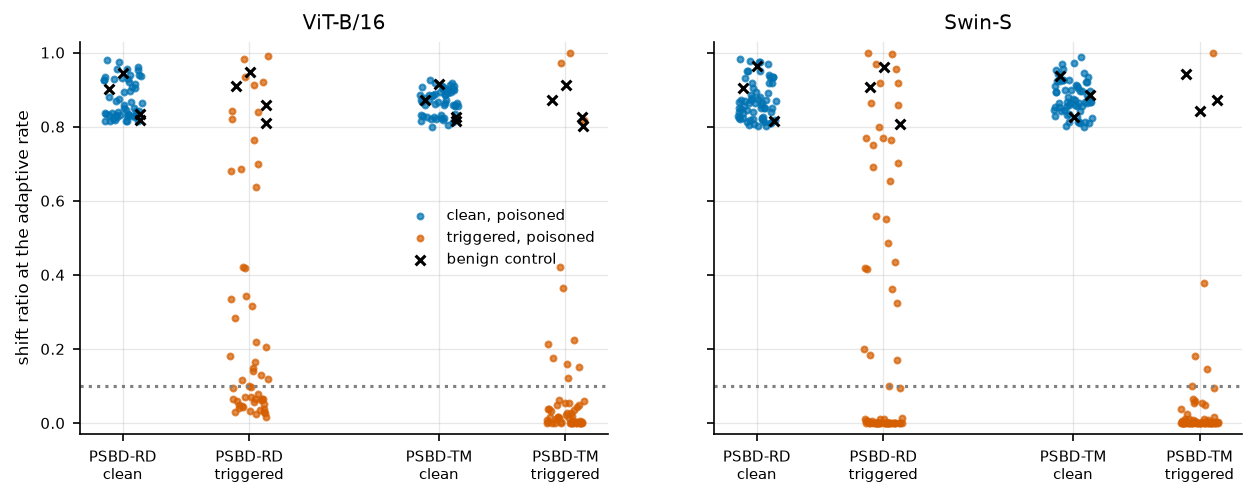

**C1, verdict true.** Clean predictions shift and captured triggered ones do not (claim 1), under PSBD-TM. Key number: holds on 101 of 117 poisoned transformer models (ViT-B/16 43 of 54 (median triggered shift 0.016), Swin-S 58 of 63 (median triggered shift 0.002)). Control: on the benign references the clean and triggered curves coincide on 7 of 7. Evidence: `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_1` and `claim_1_benign`.

**C2, verdict partial.** Clean predictions shift and captured triggered ones do not (claim 1), under PSBD-RD. Key number: holds on 63 of 119 poisoned transformer models (ViT-B/16 26 of 54 (median triggered shift 0.117), Swin-S 37 of 65 (median triggered shift 0.011)). Control: on the benign references the clean and triggered curves coincide on 7 of 7. Evidence: `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_1` and `claim_1_benign`.

In [8]:
def claim_counts(claim, placement):
    readings = [
        overall[(architecture, placement)][claim] for architecture in TRANSFORMERS
    ]
    holds = sum(reading["counts"].get("holds", 0) for reading in readings)
    total = sum(reading["total"] for reading in readings)
    return holds, total


def strip_sigma(axis, frame, placements):
    # 1 column of dots per (placement, split): clean validation first, then the
    # captured triggered images, with the benign models as the control.
    ticks, labels = [], []
    for index, placement in enumerate(placements):
        for offset, (column, color, split) in enumerate(
            (
                ("sigma_validation", CLEAN_COLOR, "clean"),
                ("sigma_backdoor", TRIGGERED_COLOR, "triggered"),
            )
        ):
            position = 2.5 * index + offset
            rows = frame[frame["placement"] == placement]
            poisoned = rows[~rows["benign"]][column].dropna().to_numpy()
            benign = rows[rows["benign"]][column].dropna().to_numpy()
            axis.scatter(
                position + jitter(len(poisoned)),
                poisoned,
                s=8,
                color=color,
                alpha=0.7,
                label=f"{split}, poisoned" if index == 0 else None,
            )
            axis.scatter(
                position + jitter(len(benign), seed=1),
                benign,
                s=22,
                marker="x",
                color=CONTROL_COLOR,
                label="benign control" if index == 0 and offset == 1 else None,
            )
            ticks.append(position)
            labels.append(f"{PLACEMENT_LABELS[placement]}\n{split}")
    axis.set_xticks(ticks, labels)
    axis.axhline(phenomenon_thresholds["near_zero_shift"], color="grey", linestyle=":")
    axis.set_ylim(-0.03, 1.03)


if phenomenon is not None:
    figure, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
    plotted = {}
    for axis, architecture in zip(axes, TRANSFORMERS):
        frame = phenomenon_rows[phenomenon_rows["architecture"] == architecture]
        strip_sigma(axis, frame, (PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT))
        axis.set_title(ARCHITECTURE_LABELS[architecture])
        plotted[architecture] = frame[
            ["folder", "placement", "benign", "sigma_validation", "sigma_backdoor"]
        ].to_dict("records")
    axes[0].set_ylabel("shift ratio at the adaptive rate")
    axes[0].legend()
    save_figure(figure, "claim1_shift_ratio", [PHENOMENON_SOURCE], plotted)

    for cid, placement in (("C1", RECOMMENDED_PLACEMENT), ("C2", PUBLISHED_PLACEMENT)):
        holds, total = claim_counts("claim_1", placement)
        benign_holds, benign_total = claim_counts("claim_1_benign", placement)
        medians = ", ".join(
            f"{ARCHITECTURE_LABELS[a]} {overall[(a, placement)]['claim_1']['counts'].get('holds', 0)} "
            f"of {overall[(a, placement)]['claim_1']['total']} (median triggered shift "
            f"{number(overall[(a, placement)]['median_backdoor_sigma'])})"
            for a in TRANSFORMERS
        )
        register(
            cid,
            "s1",
            f"Clean predictions shift and captured triggered ones do not (claim 1), under {PLACEMENT_LABELS[placement]}",
            "Li et al., tested with our placement",
            verdict_from_share(holds, total),
            f"holds on {holds} of {total} poisoned transformer models ({medians})",
            f"on the benign references the clean and triggered curves coincide on {benign_holds} of {benign_total}",
            f"{PHENOMENON_SOURCE}, `overall[].claim_1` and `claim_1_benign`",
        )

In [9]:
if phenomenon is not None:
    resnet = overall[("resnet18", PUBLISHED_PLACEMENT)]
    show(
        f"On our own ResNet-18 checkpoints, the paper's architecture and site, claim 1 holds on "
        f"{resnet['claim_1']['counts'].get('holds', 0)} of {resnet['claim_1']['total']} models "
        f"(`overall[]` row `resnet18`). The observation reproduces where Li et al. made it, and "
        f"with too few ResNet models to call it more than a reproduction."
    )

On our own ResNet-18 checkpoints, the paper's architecture and site, claim 1 holds on 1 of 2 models (`overall[]` row `resnet18`). The observation reproduces where Li et al. made it, and with too few ResNet models to call it more than a reproduction.

**What this does not show.** The claim is about argmax flips, and PSBD scores the confidence drop, so a model can fail claim 1 and still be detected (the TaCT models of section 2 are the example). The triggered images here are test images the model captures, not the poisoned training set the paper scores.

**Claim 2, shifted clean predictions land on the target.** **Prediction if true.** At least the paper's "almost all" share of shifted clean predictions lands on the target class, and a benign model sends its shifts to 1 class too. **Experiment.** The landing class of every shifted (image, pass) prediction at the adaptive rate. **Control.** The benign references, whose share on class 0 is what attraction without a backdoor looks like.

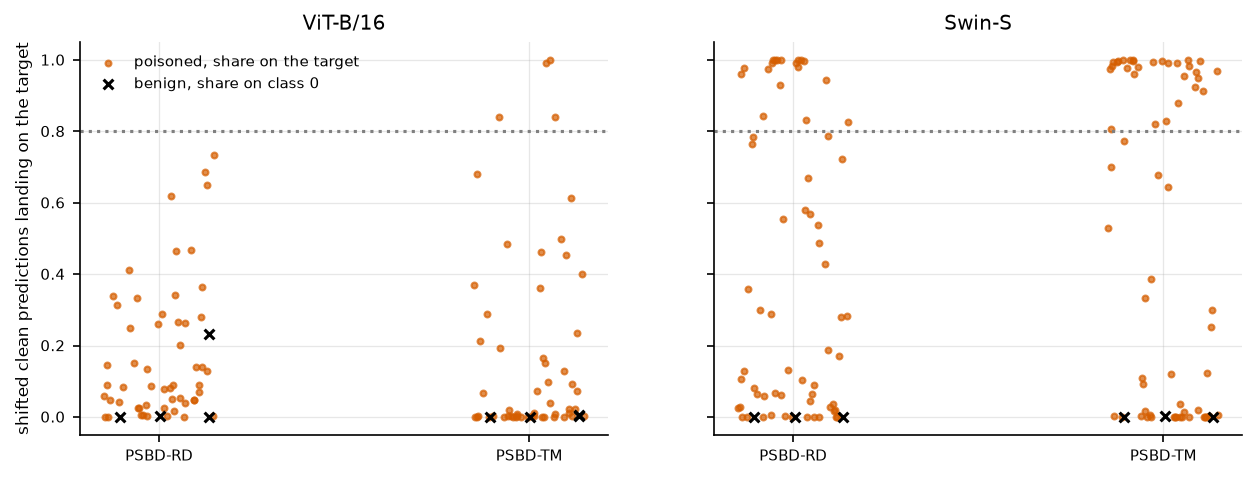

**C3, verdict false.** When a clean prediction shifts, it shifts to the attacker's target (claim 2). Key number: at least 0.8 of shifts on the target in 51 of 236 poisoned transformer readings (ViT-B/16 PSBD-TM 4 of 54 (median share 0.022), ViT-B/16 PSBD-RD 0 of 54 (median share 0.089), Swin-S PSBD-TM 29 of 63 (median share 0.677), Swin-S PSBD-RD 18 of 65 (median share 0.282)). Control: benign references, where 1 class takes at least half of the shifts in 5 of 14 readings. Evidence: `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_2` and `cached_rows[].validation_target_share`.

In [10]:
if phenomenon is not None:
    figure, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
    plotted = {}
    for axis, architecture in zip(axes, TRANSFORMERS):
        frame = phenomenon_rows[phenomenon_rows["architecture"] == architecture]
        for index, placement in enumerate((PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT)):
            rows = frame[frame["placement"] == placement]
            poisoned = (
                rows[~rows["benign"]]["validation_target_share"].dropna().to_numpy()
            )
            # A benign model has no target, so its reading is the share on class 0,
            # the class its cache was probed with, and it is what chance attraction looks like.
            benign = rows[rows["benign"]]["validation_target_share"].dropna().to_numpy()
            axis.scatter(
                index + jitter(len(poisoned)),
                poisoned,
                s=8,
                color=TRIGGERED_COLOR,
                alpha=0.7,
                label="poisoned, share on the target" if index == 0 else None,
            )
            axis.scatter(
                index + jitter(len(benign), seed=1),
                benign,
                s=22,
                marker="x",
                color=CONTROL_COLOR,
                label="benign, share on class 0" if index == 0 else None,
            )
        axis.axhline(
            phenomenon_thresholds["almost_all_on_target"], color="grey", linestyle=":"
        )
        axis.set_xticks([0, 1], [RD, TM])
        axis.set_title(ARCHITECTURE_LABELS[architecture])
        plotted[architecture] = frame[
            ["folder", "placement", "benign", "validation_target_share"]
        ].to_dict("records")
    axes[0].set_ylabel("shifted clean predictions landing on the target")
    axes[0].legend()
    save_figure(figure, "claim2_target_share", [PHENOMENON_SOURCE], plotted)

    holds = sum(claim_counts("claim_2", placement)[0] for placement in PLACEMENT_LABELS)
    total = sum(claim_counts("claim_2", placement)[1] for placement in PLACEMENT_LABELS)
    per_reading = ", ".join(
        f"{ARCHITECTURE_LABELS[a]} {PLACEMENT_LABELS[p]} {overall[(a, p)]['claim_2']['counts'].get('holds', 0)} "
        f"of {overall[(a, p)]['claim_2']['total']} (median share {number(overall[(a, p)]['median_target_share'])})"
        for a in TRANSFORMERS
        for p in (RECOMMENDED_PLACEMENT, PUBLISHED_PLACEMENT)
    )
    benign_holds = sum(
        claim_counts("claim_2_benign", placement)[0] for placement in PLACEMENT_LABELS
    )
    benign_total = sum(
        claim_counts("claim_2_benign", placement)[1] for placement in PLACEMENT_LABELS
    )
    register(
        "C3",
        "s1",
        "When a clean prediction shifts, it shifts to the attacker's target (claim 2)",
        "Li et al.",
        verdict_from_share(holds, total),
        f"at least {number(phenomenon_thresholds['almost_all_on_target'], 1)} of shifts on the target in "
        f"{holds} of {total} poisoned transformer readings ({per_reading})",
        f"benign references, where 1 class takes at least half of the shifts in {benign_holds} of {benign_total} readings",
        f"{PHENOMENON_SOURCE}, `overall[].claim_2` and `cached_rows[].validation_target_share`",
    )

**What this does not show.** Where the target does win (Swin-S under PSBD-TM on BadNets, WaNet and Adaptive-Blend), this reading cannot say why. A benign model can also collapse onto 1 class. The target share moves strongly with the rate, so a claim read at 1 rate is a claim about that rate.

**Claim 3, neuron bias in the last layer.** **Prediction if true.** Under dropout the last-layer features of a clean image and its triggered twin become almost identical, and more so than 2 unrelated clean images. **Experiment.** The centered cosine between the 2 feature maps without the perturbation, with 1 mask shared by both images (the paper's figure) and with independent masks (how PSBD scores 2 inputs). **Control.** A clean image paired with an unrelated clean image under the same mask relation, and the benign models.

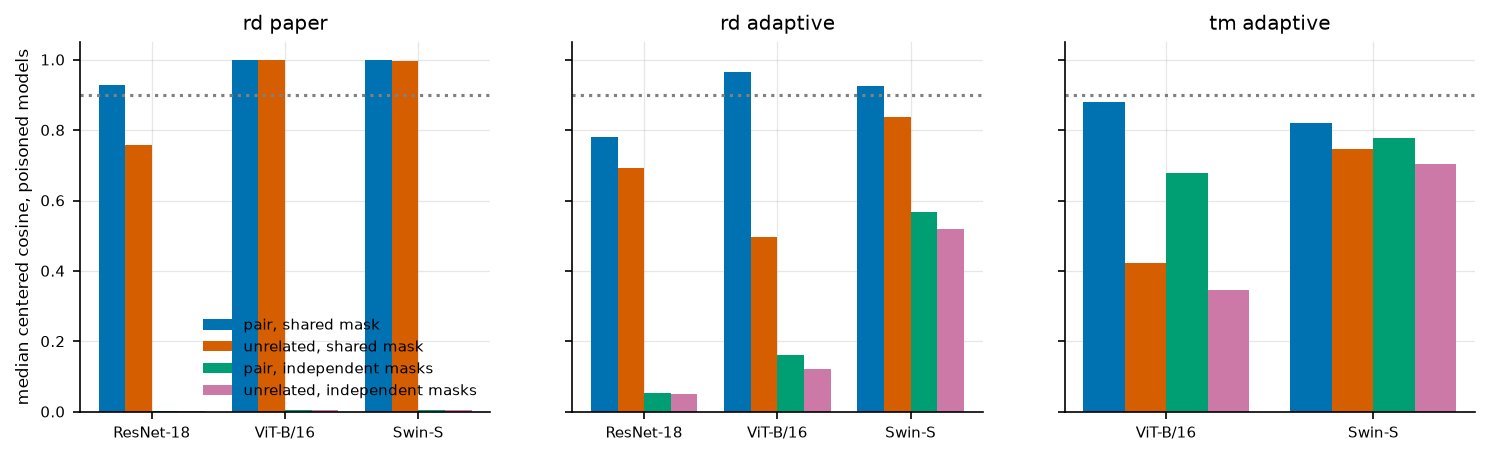

**C4, verdict false.** Dropout makes a clean image's last-layer features match its triggered twin's, the neuron bias (claim 3). Key number: holds on 0 of 57 transformer feature readings, and at p = 0.91 with a shared mask the pair's median cosine is 1.000 while 2 unrelated clean images reach 0.999. Control: a clean image and an unrelated clean image under the same mask, and the benign models. Evidence: `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_3` and `feature_rows[]`.

In [11]:
if phenomenon is not None:
    conditions = ("rd_paper", "rd_adaptive", "tm_adaptive")
    measures = (
        ("cosine_pair_shared", "pair, shared mask"),
        ("cosine_unrelated_on", "unrelated, shared mask"),
        ("cosine_pair_independent", "pair, independent masks"),
        ("cosine_unrelated_independent", "unrelated, independent masks"),
    )
    figure, axes = plt.subplots(1, len(conditions), figsize=(12, 3.2), sharey=True)
    plotted = {}
    poisoned_features = phenomenon_features[
        phenomenon_features["probe"] == phenomenon_features["attack"]
    ]
    for axis, condition in zip(axes, conditions):
        frame = poisoned_features[poisoned_features["condition"] == condition]
        architectures = [
            a for a in ("resnet18", "vit", "swin") if (frame["architecture"] == a).any()
        ]
        width = 0.8 / len(measures)
        for index, (column, label) in enumerate(measures):
            medians = [
                frame[frame["architecture"] == a][column].median()
                for a in architectures
            ]
            positions = np.arange(len(architectures)) + index * width
            axis.bar(
                positions, medians, width=width, color=OKABE_ITO[index], label=label
            )
            plotted[f"{condition}|{column}"] = dict(zip(architectures, medians))
        axis.set_xticks(
            np.arange(len(architectures)) + 0.3,
            [ARCHITECTURE_LABELS[a] for a in architectures],
        )
        axis.set_title(condition.replace("_", " "))
        axis.axhline(
            phenomenon_thresholds["identical_cosine"], color="grey", linestyle=":"
        )
    axes[0].set_ylabel("median centered cosine, poisoned models")
    axes[0].legend()
    save_figure(figure, "claim3_feature_convergence", [PHENOMENON_SOURCE], plotted)

    holds, total = 0, 0
    for architecture in TRANSFORMERS:
        for placement in PLACEMENT_LABELS:
            reading = overall[(architecture, placement)]["claim_3"]
            holds += reading["counts"].get("holds", 0)
            total += reading.get("total", 0)
    at_paper_rate = poisoned_features[
        (poisoned_features["condition"] == "rd_paper")
        & poisoned_features["architecture"].isin(TRANSFORMERS)
    ]
    register(
        "C4",
        "s1",
        "Dropout makes a clean image's last-layer features match its triggered twin's, the neuron bias (claim 3)",
        "Li et al.",
        verdict_from_share(holds, total) if total else "pending",
        f"holds on {holds} of {total} transformer feature readings, and at p = {number(at_paper_rate['rate'].iloc[0], 2)} with a shared mask "
        f"the pair's median cosine is {number(at_paper_rate['cosine_pair_shared'].median())} while "
        f"2 unrelated clean images reach {number(at_paper_rate['cosine_unrelated_on'].median())}",
        "a clean image and an unrelated clean image under the same mask, and the benign models",
        f"{PHENOMENON_SOURCE}, `overall[].claim_3` and `feature_rows[]`",
    )

**What this does not show.** The measurement covers 1 model per attack family, mostly at 10% poisoning. The last block's patch tokens stand in for ResNet-18's top layer. It refutes convergence as evidence of a backdoor. It does not rule out a weaker drift toward the triggered features, which the source README reports on Swin-S only.

**Claim 4, MC-Dropout uncertainty misses WaNet.** **Prediction if true.** The standard deviation of the answer's probability over the passes separates BadNets and fails on WaNet and Adaptive-Blend, where the confidence drop still works. **Experiment.** The AUROC of the standard deviation at every rate, given its best rate as an oracle, against fractional PSU at the adaptive rate on the same passes. **Control.** The 2 scores come from the same passes, so only the statistic changes.

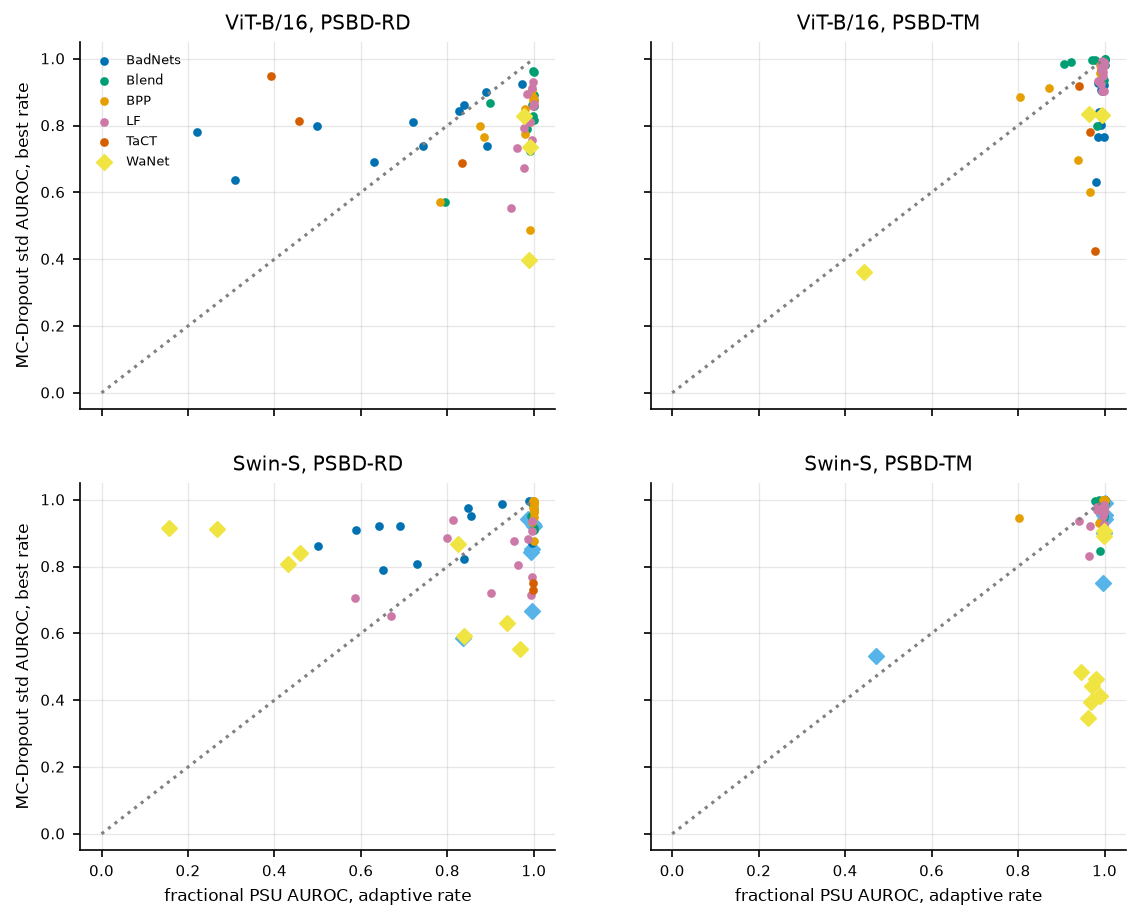

**C5, verdict partial.** MC-Dropout uncertainty catches BadNets and misses WaNet and Adaptive-Blend, which is why PSBD reads the confidence drop (claim 4). Key number: holds on 2 of 4 transformer placements: ViT-B/16 PSBD-RD holds (std fails on 1.00 of 3 WaNet and Adaptive-Blend models, suffices on 0.83 of 12 BadNets models), ViT-B/16 PSBD-TM partial (std fails on 1.00 of 3 WaNet and Adaptive-Blend models, suffices on 0.17 of 12 BadNets models), Swin-S PSBD-RD partial (std fails on 0.60 of 15 WaNet and Adaptive-Blend models, suffices on 0.92 of 12 BadNets models), Swin-S PSBD-TM holds (std fails on 0.73 of 15 WaNet and Adaptive-Blend models, suffices on 1.00 of 12 BadNets models). Control: the same passes scored 2 ways, the standard deviation given its best rate as an oracle. Evidence: `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_4`.

In [12]:
if phenomenon is not None:
    figure, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
    plotted = {}
    for row_index, architecture in enumerate(TRANSFORMERS):
        for column_index, placement in enumerate(
            (PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT)
        ):
            axis = axes[row_index, column_index]
            frame = phenomenon_rows[
                (phenomenon_rows["architecture"] == architecture)
                & (phenomenon_rows["placement"] == placement)
                & ~phenomenon_rows["benign"]
            ]
            for attack, group in frame.groupby("attack"):
                emphasized = attack in ("wanet", "adaptive_blend")
                axis.scatter(
                    group["auroc_psu_ratio"],
                    group["auroc_std_best_rate"],
                    s=26 if emphasized else 10,
                    marker="D" if emphasized else "o",
                    color=ATTACK_COLORS.get(attack, CONTROL_COLOR),
                    label=attack_label(attack),
                )
            axis.plot([0, 1], [0, 1], color="grey", linestyle=":")
            axis.set_title(
                f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}"
            )
            plotted[f"{architecture}|{placement}"] = frame[
                ["folder", "attack", "auroc_psu_ratio", "auroc_std_best_rate"]
            ].to_dict("records")
    for axis in axes[1]:
        axis.set_xlabel("fractional PSU AUROC, adaptive rate")
    for axis in axes[:, 0]:
        axis.set_ylabel("MC-Dropout std AUROC, best rate")
    axes[0, 0].legend(fontsize=6)
    save_figure(figure, "claim4_std_against_psu", [PHENOMENON_SOURCE], plotted)

    readings = {
        (a, p): overall[(a, p)]["claim_4"]
        for a in TRANSFORMERS
        for p in (PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT)
    }
    holds = sum(reading["verdict"] == "holds" for reading in readings.values())
    per_reading = ", ".join(
        f"{ARCHITECTURE_LABELS[a]} {PLACEMENT_LABELS[p]} {reading['verdict']} (std fails on "
        f"{number(reading['wanet_adaptive_blend_std_fails_share'], 2)} of {reading['wanet_adaptive_blend_models']} "
        f"WaNet and Adaptive-Blend models, suffices on {number(reading['badnets_std_suffices_share'], 2)} of "
        f"{reading['badnets_models']} BadNets models)"
        for (a, p), reading in readings.items()
    )
    register(
        "C5",
        "s1",
        "MC-Dropout uncertainty catches BadNets and misses WaNet and Adaptive-Blend, which is why PSBD reads the confidence drop (claim 4)",
        "Li et al.",
        verdict_from_share(holds, len(readings)),
        f"holds on {holds} of {len(readings)} transformer placements: {per_reading}",
        "the same passes scored 2 ways, the standard deviation given its best rate as an oracle",
        f"{PHENOMENON_SOURCE}, `overall[].claim_4`",
    )

**What this does not show.** The paper tracks uncertainty over training epochs on the poisoned training set, and the caches hold the final checkpoint's test-time passes. The BadNets half of the claim fails under PSBD-TM on ViT, so the verdict is about the 2 halves together.

<a id="s2"></a>
## Breaking-point curves

The shift ratio at rate p is the share of (image, pass) predictions that differ from the unperturbed answer. Over a ladder of rates it traces how the breaking points of a population are distributed, and the gap between the clean and the triggered curve is what a detector at 1 rate can exploit. The figures draw every model as a thin line and the median in bold, clean validation images in blue and captured triggered images in orange, for PSBD-TM in the top row and PSBD-RD in the bottom row, with the benign references as the control column. The rates are on a log axis because PSBD-RD saturates below p = 0.1.

In [13]:
MIN_CURVE_RATES = 4
CURVE_ATTACKS = (
    "badnet_a2o",
    "tact",
    "blend",
    "lf",
    "bpp",
    "adaptive_blend",
    "wanet",
    "benign",
)
cached_curves = (
    {
        path.stem: read_json(path)
        for path in sorted((PHENOMENON / "cached").glob("*.json"))
    }
    if phenomenon is not None
    else {}
)
curve_folders = set(phenomenon_panel["folders"]) if phenomenon_panel else set()


def curve_groups(architecture):
    groups = defaultdict(list)
    for folder, record in cached_curves.items():
        if record["architecture"] != architecture or folder not in curve_folders:
            continue
        key = "benign" if record["benign"] else record["attack"]
        groups[key].append(record)
    return groups


def model_curve(record, placement, split):
    block = record["placements"].get(placement)
    if block is None or len(block["per_rate"]) < MIN_CURVE_RATES:
        return None
    rates = [row["rate"] for row in block["per_rate"]]
    values = [row["sigma"][split] for row in block["per_rate"]]
    curve = (rates, values)
    return curve


def median_curve(curves):
    # The models of 1 placement share its ladder almost everywhere, so the median
    # is taken rate by rate over the models that cached that rate.
    by_rate = defaultdict(list)
    for rates, values in curves:
        for rate, value in zip(rates, values):
            by_rate[rate].append(value)
    rates = sorted(by_rate)
    medians = [float(np.median(by_rate[rate])) for rate in rates]
    curve = (rates, medians)
    return curve


def crossing(curve, level=0.5):
    # The rate at which a curve first reaches the level, interpolated linearly
    # between the 2 ladder rates around it, None when it never does.
    rates, values = curve
    for index in range(1, len(rates)):
        if values[index - 1] < level <= values[index]:
            fraction = (level - values[index - 1]) / (values[index] - values[index - 1])
            rate = rates[index - 1] + fraction * (rates[index] - rates[index - 1])
            return rate
    return None


def draw_curves(architecture):
    groups = curve_groups(architecture)
    attacks = [attack for attack in CURVE_ATTACKS if attack in groups]
    figure, axes = plt.subplots(
        2, len(attacks), figsize=(2.3 * len(attacks), 5), sharey=True, squeeze=False
    )
    plotted = {}
    for row, placement in enumerate((RECOMMENDED_PLACEMENT, PUBLISHED_PLACEMENT)):
        for column, attack in enumerate(attacks):
            axis = axes[row, column]
            for split, color, label in (
                ("validation", CLEAN_COLOR, "clean"),
                ("backdoor", TRIGGERED_COLOR, "triggered"),
            ):
                curves = [
                    c
                    for c in (model_curve(r, placement, split) for r in groups[attack])
                    if c
                ]
                for rates, values in curves:
                    axis.plot(rates, values, color=color, alpha=0.25, linewidth=0.7)
                if curves:
                    median = median_curve(curves)
                    axis.plot(
                        *median,
                        color=color,
                        linewidth=2,
                        marker=".",
                        label=f"{label}, median",
                    )
                    plotted[f"{PLACEMENT_LABELS[placement]}|{attack}|{label}"] = {
                        "models": [dict(zip(("rates", "values"), c)) for c in curves],
                        "median": dict(zip(("rates", "values"), median)),
                    }
            axis.set_xscale("log")
            axis.set_title(
                f"{PLACEMENT_LABELS[placement]} {attack_label(attack)} ({len(groups[attack])})",
                fontsize=7,
            )
            if row == 1:
                axis.set_xlabel("rate p")
        axes[row, 0].set_ylabel("shift ratio")
    axes[0, 0].legend()
    save_figure(
        figure,
        f"breaking_point_curves_{architecture}",
        [f"`{PHENOMENON}/cached/*.json`"],
        plotted,
    )
    return plotted

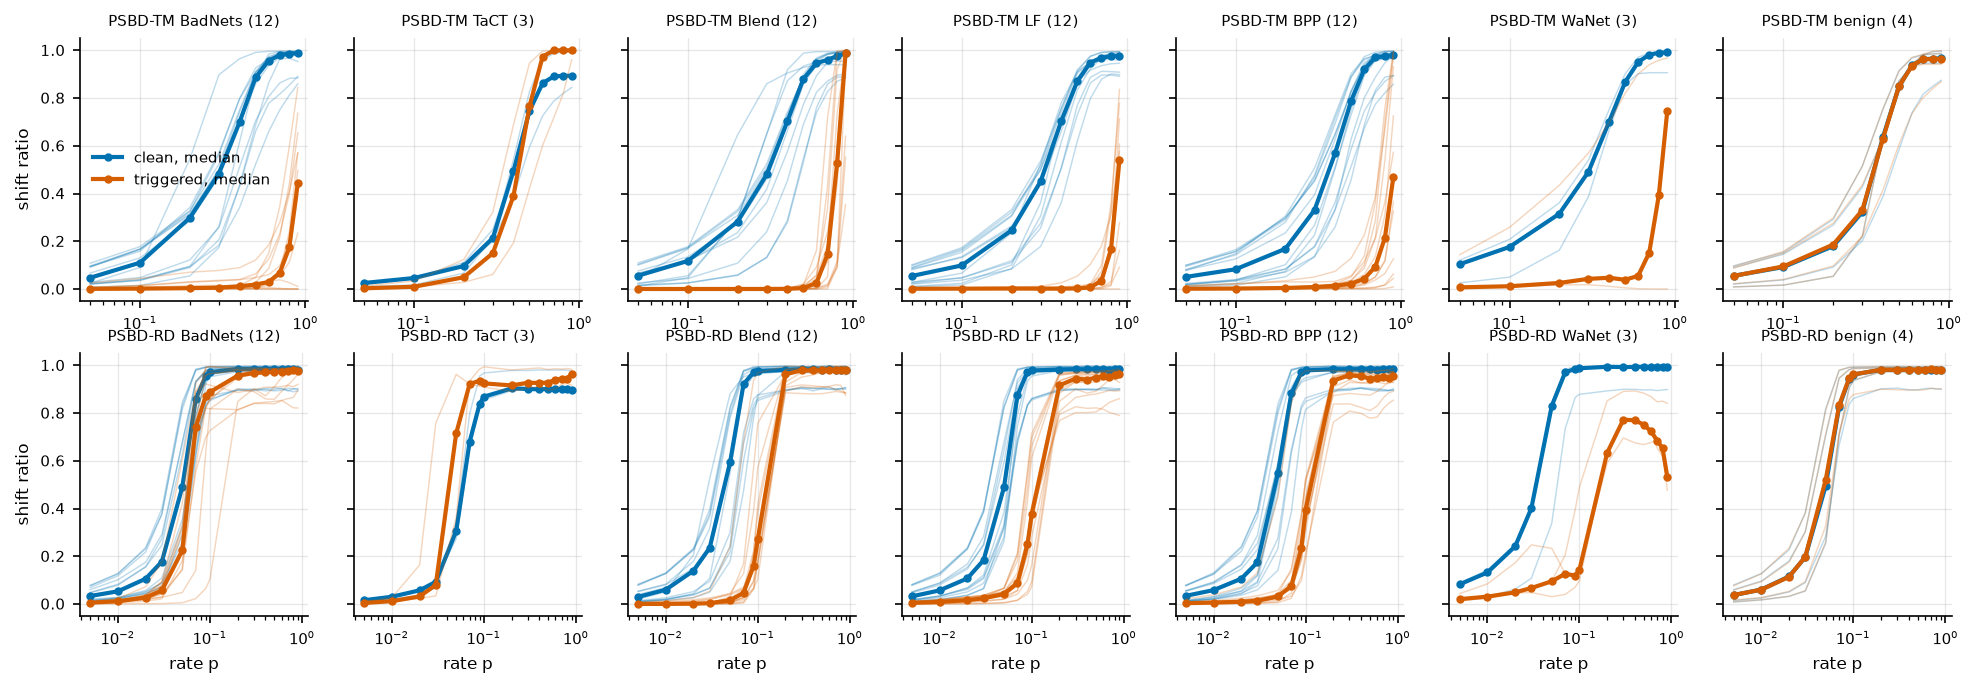

In [14]:
if cached_curves:
    vit_curves = draw_curves("vit")
else:
    vit_curves = {}
    show(
        "pending: `results/_experiments/prediction_shift_phenomenon/cached/` is missing."
    )

The same curves on the Swin-S panel. Swin's trigger-conditional TaCT models were swept with PSBD-TM at a single rate and have no PSBD-TM curve. The Adaptive-Blend column exists on Swin only.

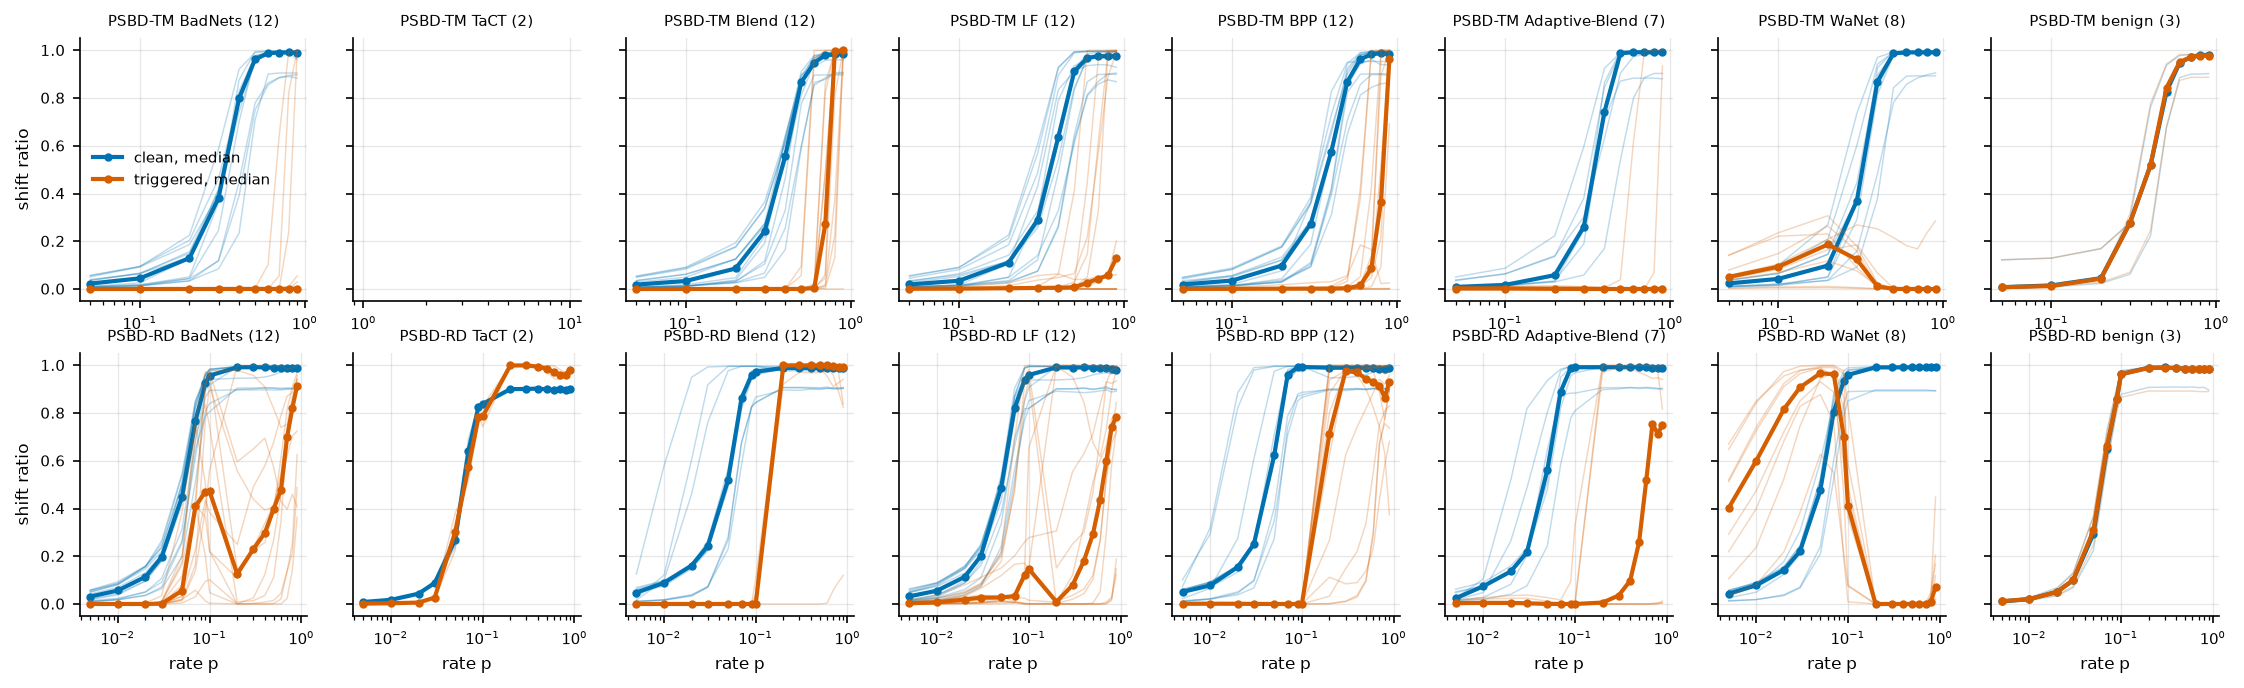

In [15]:
if cached_curves:
    swin_curves = draw_curves("swin")

WaNet model by model on ViT-B/16, solid lines for PSBD-TM and dashed lines for PSBD-RD. The inverted cell of the panel is the 1 model where the triggered PSBD-TM curve climbs with the clean one.

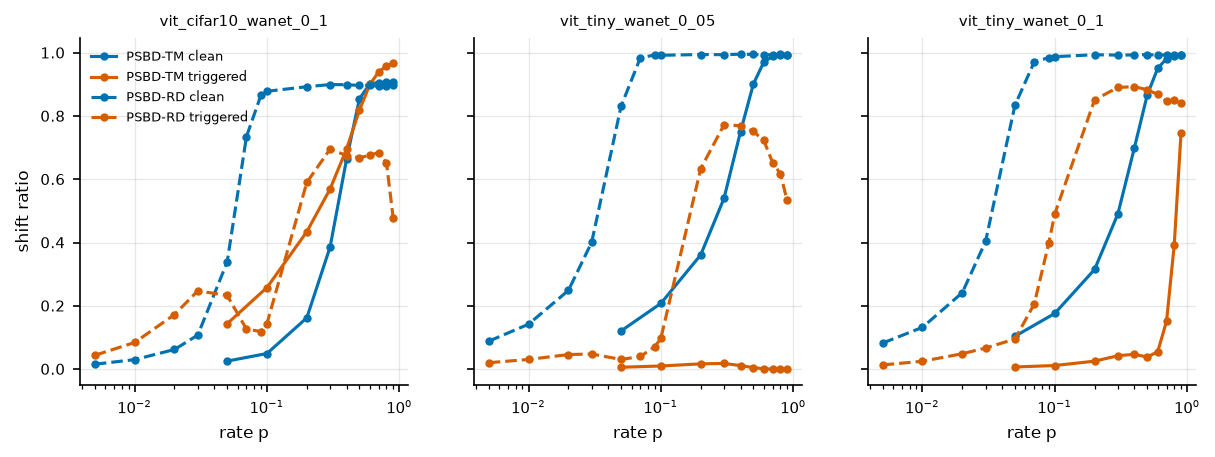

In [16]:
def wanet_model_figure(architecture):
    records = [r for r in curve_groups(architecture).get("wanet", [])]
    figure, axes = plt.subplots(
        1, len(records), figsize=(3.2 * len(records), 3), sharey=True, squeeze=False
    )
    plotted = {}
    for axis, record in zip(axes[0], sorted(records, key=lambda r: r["folder"])):
        for placement, style in (
            (RECOMMENDED_PLACEMENT, "-"),
            (PUBLISHED_PLACEMENT, "--"),
        ):
            for split, color, label in (
                ("validation", CLEAN_COLOR, "clean"),
                ("backdoor", TRIGGERED_COLOR, "triggered"),
            ):
                curve = model_curve(record, placement, split)
                if curve is None:
                    continue
                axis.plot(
                    *curve,
                    color=color,
                    linestyle=style,
                    marker=".",
                    label=f"{PLACEMENT_LABELS[placement]} {label}",
                )
                plotted[f"{record['folder']}|{PLACEMENT_LABELS[placement]}|{label}"] = (
                    dict(zip(("rates", "values"), curve))
                )
        axis.set_xscale("log")
        axis.set_title(record["folder"], fontsize=7)
        axis.set_xlabel("rate p")
    axes[0, 0].set_ylabel("shift ratio")
    axes[0, 0].legend(fontsize=6)
    save_figure(
        figure,
        f"breaking_point_wanet_{architecture}",
        [f"`{PHENOMENON}/cached/*.json`"],
        plotted,
    )
    return plotted


if cached_curves:
    wanet_curves = wanet_model_figure("vit")

**Open contradictions in the curves.** 3 features of the curves do not fit a single account in which PSBD reads how much later triggered inputs break than clean ones. The cell below computes each from the medians drawn above.

In [17]:
if vit_curves:
    tact_rows = phenomenon_rows[
        (phenomenon_rows["architecture"] == "vit")
        & (phenomenon_rows["attack"] == "tact")
        & (phenomenon_rows["placement"] == RECOMMENDED_PLACEMENT)
    ]
    tm_tact_clean = vit_curves[f"{TM}|tact|clean"]["median"]
    tm_tact_triggered = vit_curves[f"{TM}|tact|triggered"]["median"]
    tact_gap = float(
        np.mean(
            np.abs(
                np.array(tm_tact_clean["values"])
                - np.array(tm_tact_triggered["values"])
            )
        )
    )
    rd_tact_clean = vit_curves[f"{RD}|tact|clean"]["median"]
    rd_tact_triggered = vit_curves[f"{RD}|tact|triggered"]["median"]
    rd_tact_clean_cross = crossing((rd_tact_clean["rates"], rd_tact_clean["values"]))
    rd_tact_triggered_cross = crossing(
        (rd_tact_triggered["rates"], rd_tact_triggered["values"])
    )
    rd_wanet_triggered = vit_curves[f"{RD}|wanet|triggered"]["median"]
    rd_wanet_peak = max(rd_wanet_triggered["values"])
    rd_wanet_peak_rate = rd_wanet_triggered["rates"][
        int(np.argmax(rd_wanet_triggered["values"]))
    ]
    rd_wanet_clean_top = max(vit_curves[f"{RD}|wanet|clean"]["median"]["values"])
    tact_earlier = rd_tact_triggered_cross is not None and (
        rd_tact_clean_cross is None or rd_tact_triggered_cross < rd_tact_clean_cross
    )
    show(
        f"**TaCT under {TM} overlaps.** The median clean and triggered curves of the "
        f"{len(tact_rows)} trigger-conditional TaCT models differ by {number(tact_gap)} on average over the "
        f"ladder, yet their median fractional PSU AUROC at the adaptive rate is "
        f"{number(tact_rows['auroc_psu_ratio'].median())} (`cached_rows[].auroc_psu_ratio`). The argmax "
        "flip the curves count and the confidence drop PSBD scores come apart on these models, so the "
        "shift ratio curve cannot be the account of why TaCT is detected.\n\n"
        f"**TaCT under {RD} breaks {'earlier' if tact_earlier else 'no earlier'} for triggered inputs.** The "
        f"median triggered curve reaches 0.5 at p = {number(rd_tact_triggered_cross)} and the clean one at "
        f"p = {number(rd_tact_clean_cross)}. A triggered TaCT input carries source-class content that residual "
        "dropout breaks as easily as the trigger, which is hypothesis 4 of section C of "
        "`experiments/why_token_masking_works/`.\n\n"
        f"**WaNet under {RD} peaks.** The median triggered curve rises to {number(rd_wanet_peak)} at "
        f"p = {number(rd_wanet_peak_rate, 2)} while the clean one tops out at {number(rd_wanet_clean_top)}. "
        f"{RD} still detects WaNet, so on WaNet the breaking points of the 2 populations overlap at the rates "
        "that matter and the separation lives in the size of the confidence drop."
    )

**TaCT under PSBD-TM overlaps.** The median clean and triggered curves of the 3 trigger-conditional TaCT models differ by 0.073 on average over the ladder, yet their median fractional PSU AUROC at the adaptive rate is 0.967 (`cached_rows[].auroc_psu_ratio`). The argmax flip the curves count and the confidence drop PSBD scores come apart on these models, so the shift ratio curve cannot be the account of why TaCT is detected.

**TaCT under PSBD-RD breaks earlier for triggered inputs.** The median triggered curve reaches 0.5 at p = 0.043 and the clean one at p = 0.060. A triggered TaCT input carries source-class content that residual dropout breaks as easily as the trigger, which is hypothesis 4 of section C of `experiments/why_token_masking_works/`.

**WaNet under PSBD-RD peaks.** The median triggered curve rises to 0.772 at p = 0.30 while the clean one tops out at 0.994. PSBD-RD still detects WaNet, so on WaNet the breaking points of the 2 populations overlap at the rates that matter and the separation lives in the size of the confidence drop.

**The unified breaking-point account.** **Claim.** Every input has a critical rate p*, the smallest rate at which most of its passes change its answer, and PSBD at any placement is a 2-sample test on p*. **Prediction if true.** Over every (model, placement) pair the AUROC at the adaptive rate is a monotone function of A* = P(p*_triggered > p*_clean), and on the benign references A* sits at 0.5. **Experiment.** `experiments/why_psbd_works/critical_rate.py` on the cached per-pass argmax of every placement with a ladder. **Control.** The benign references. The owner experiment has not reported this record in its README yet. The verdict stays open until it does and the numbers are a first read.

In [18]:
critical = read_json(EXPERIMENTS / "why_psbd_works" / "critical_rate.json")
why_readme = Path("experiments/why_psbd_works/README.md")
# The owner experiment reports a result in its generated README. Until the README
# names the record, the numbers below are a first read and the verdict stays open.
breaking_point_landed = (
    why_readme.exists() and "critical_rate" in why_readme.read_text()
)
CRITICAL_SOURCE = (
    "`results/_experiments/why_psbd_works/critical_rate.json`, `predictions`"
)
if critical is None:
    register(
        "C6",
        "s2",
        "PSBD at every placement is a 2-sample test on the per-image breaking point p*",
        "ours, `experiments/why_psbd_works/`",
        "pending",
        "pending",
        "benign references",
        CRITICAL_SOURCE,
    )
else:
    predictions = critical["predictions"]
    if breaking_point_landed:
        held = [predictions["P1_holds"], predictions["P2_holds"]]
        verdict = "true" if all(held) else "false" if not any(held) else "partial"
    else:
        verdict = "open"
    register(
        "C6",
        "s2",
        "PSBD at every placement is a 2-sample test on the per-image breaking point p*, and operators differ only in how far they separate it",
        "ours, `experiments/why_psbd_works/critical_rate.py`",
        verdict,
        f"first read: Spearman {number(predictions['P1_spearman'])} between AUROC and "
        f"A* = P(p*_triggered > p*_clean) over {predictions['P1_pairs']} (model, placement) pairs, "
        f"{predictions['P1_breaks_over_0.1']} pairs off by more than 0.1",
        f"benign references, A* within {number(predictions['P2_max_distance_from_half'])} of 0.5 over "
        f"{predictions['P2_benign_rows']} readings",
        CRITICAL_SOURCE,
    )

**C6, verdict open.** PSBD at every placement is a 2-sample test on the per-image breaking point p*, and operators differ only in how far they separate it. Key number: first read: Spearman 0.883 between AUROC and A* = P(p*_triggered > p*_clean) over 558 (model, placement) pairs, 100 pairs off by more than 0.1. Control: benign references, A* within 0.017 of 0.5 over 44 readings. Evidence: `results/_experiments/why_psbd_works/critical_rate.json`, `predictions`.

**What this does not show.** The curves count argmax flips, so they cannot explain a separation that lives in the size of the confidence drop, which is exactly the TaCT contradiction. The triggered curves read captured images only, and the medians hide the per-model spread the thin lines show.

<a id="s3"></a>
## Patch-trigger routing

PSBD-TM and PSBD-RD both change most clean predictions at their adaptive rates, and on patch triggers they part ways. `experiments/why_token_masking_works/` tests why with deterministic masks on the trigger's own tokens (section A), PSBD-TM with its masks recorded (section B), PSBD-RD restricted by position (section C) and fixed visible subsets of tokens (section D, used in section 8 here). Every test changes 1 thing and carries a random-token or clean-image control.

In [19]:
ROUTING = EXPERIMENTS / "why_token_masking_works"
routing = read_json(ROUTING / "summary.json")
ROUTING_SOURCE = "`results/_experiments/why_token_masking_works/summary.json`"
# The rule thresholds of this section: "breaks nearly all" is at most 0.1 of
# triggered predictions kept and "breaks nearly none" is at least 0.9 kept.
BREAK_CEILING, KEEP_FLOOR = 0.1, 0.9
if routing is None:
    for cid in ("C7", "C8", "C9", "C10"):
        register(
            cid,
            "s3",
            "patch-trigger routing",
            "ours",
            "pending",
            "pending",
            "pending",
            ROUTING_SOURCE,
        )
else:
    routing_models = pd.DataFrame(routing["per_model"])
    in_panel = routing_models["folder"].isin(PANEL)
    show(
        f"{ROUTING_SOURCE} reads {len(routing_models)} patch models on the clearing panel of its day. "
        f"{int(in_panel.sum())} of them are in today's panel: "
        + ", ".join(
            f"{group} {int(in_panel[routing_models['group'] == group].sum())} of {int((routing_models['group'] == group).sum())}"
            for group in sorted(routing_models["group"].unique())
        )
        + ". The source-mapped TaCT models are out of the panel because their whole source class goes "
        "to the target with no trigger, and they are kept below only as a contrast."
    )

`results/_experiments/why_token_masking_works/summary.json` reads 23 patch models on the clearing panel of its day. 15 of them are in today's panel: badnet_a2o 12 of 12, tact_source_mapped 0 of 8, tact_trigger_conditional 3 of 3. The source-mapped TaCT models are out of the panel because their whole source class goes to the target with no trigger, and they are kept below only as a contrast.

The first panel masks the trigger's tokens in chosen blocks, the second reads PSBD-TM's own passes by J, the number of late blocks (9 to 12) in which every trigger token happened to be masked, the third splits the broken triggered predictions by J and the fourth compares PSBD-RD on all tokens with PSBD-RD on the trigger positions only.

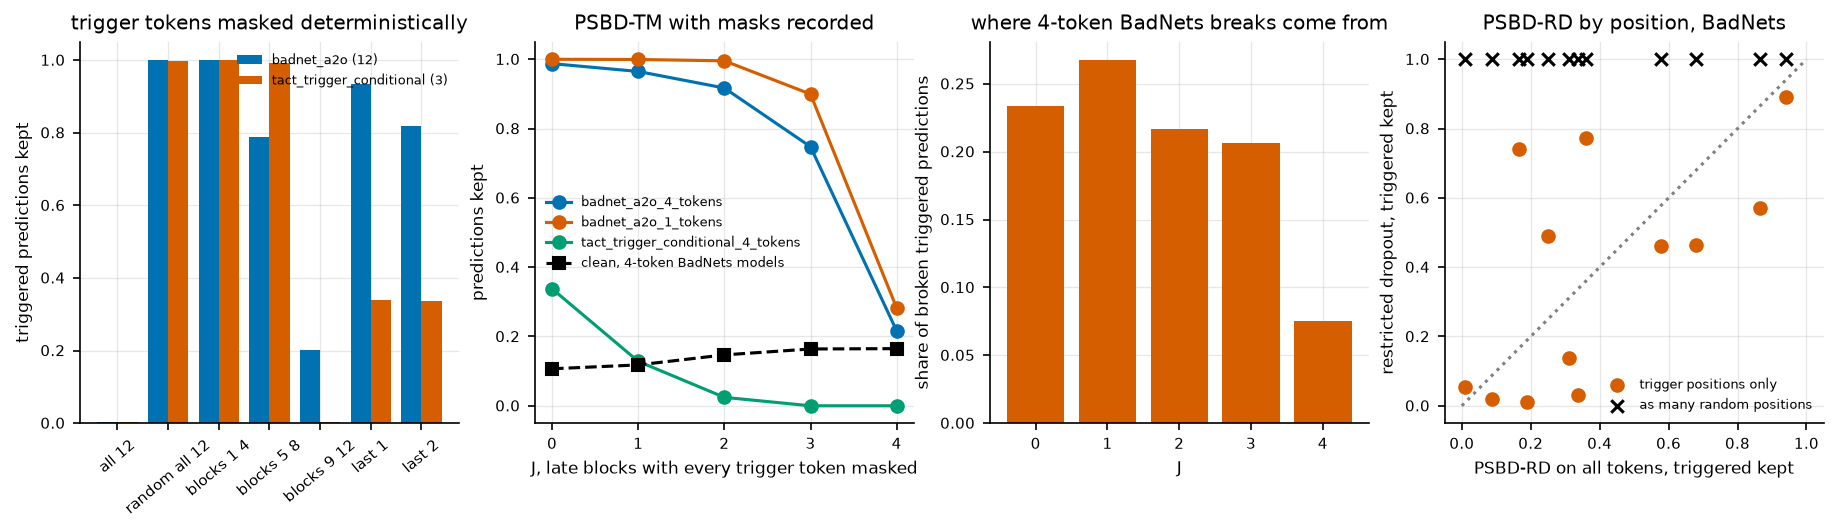

In [20]:
def breaks_by_late_blocks(late_all):
    # Broken triggered predictions per value of J, the number of late blocks in
    # which every trigger token was masked, from the pooled survival and count.
    js = sorted(late_all, key=int)
    broken = np.array(
        [late_all[j]["n"] * (1 - late_all[j]["kept"]) for j in js]
    )  # (L + 1,)
    shares = broken / broken.sum()
    return js, shares


if routing is not None:
    deterministic = routing["deterministic_masking"]
    conditions = (
        "all_12",
        "random_all_12",
        "blocks_1_4",
        "blocks_5_8",
        "blocks_9_12",
        "last_1",
        "last_2",
    )
    groups = ("badnet_a2o", "tact_trigger_conditional")
    late = routing["stochastic_token_mask_by_trigger_tokens"]
    figure, axes = plt.subplots(1, 4, figsize=(15, 3.3))
    plotted = {}

    width = 0.4
    for index, group in enumerate(groups):
        kept = [deterministic[group][c]["triggered_kept"] for c in conditions]
        axes[0].bar(
            np.arange(len(conditions)) + index * width,
            kept,
            width=width,
            color=OKABE_ITO[index],
            label=f"{group} ({deterministic[group]['all_12']['models']})",
        )
        plotted[f"deterministic|{group}"] = dict(zip(conditions, kept))
    axes[0].set_xticks(
        np.arange(len(conditions)) + width / 2,
        [c.replace("_", " ") for c in conditions],
        rotation=40,
    )
    axes[0].set_ylabel("triggered predictions kept")
    axes[0].set_title("trigger tokens masked deterministically")
    axes[0].legend(fontsize=6)

    for index, key in enumerate(
        (
            "badnet_a2o_4_tokens",
            "badnet_a2o_1_tokens",
            "tact_trigger_conditional_4_tokens",
        )
    ):
        late_all = late[key]["triggered"]["late_all"]
        js = sorted(late_all, key=int)
        axes[1].plot(
            [int(j) for j in js],
            [late_all[j]["kept"] for j in js],
            marker="o",
            color=OKABE_ITO[index],
            label=key,
        )
        plotted[f"survival|{key}"] = {j: late_all[j] for j in js}
    clean_late = late["badnet_a2o_4_tokens"]["clean"]["late_all"]
    js = sorted(clean_late, key=int)
    axes[1].plot(
        [int(j) for j in js],
        [clean_late[j]["kept"] for j in js],
        marker="s",
        color=CONTROL_COLOR,
        linestyle="--",
        label="clean, 4-token BadNets models",
    )
    plotted["survival|clean"] = {j: clean_late[j] for j in js}
    axes[1].set_xlabel("J, late blocks with every trigger token masked")
    axes[1].set_ylabel("predictions kept")
    axes[1].set_title(f"{TM} with masks recorded")
    axes[1].legend(fontsize=6)

    js, shares = breaks_by_late_blocks(
        late["badnet_a2o_4_tokens"]["triggered"]["late_all"]
    )
    axes[2].bar([int(j) for j in js], shares, color=TRIGGERED_COLOR)
    axes[2].set_xlabel("J")
    axes[2].set_ylabel("share of broken triggered predictions")
    axes[2].set_title("where 4-token BadNets breaks come from")
    plotted["break_share"] = dict(zip(js, shares.tolist()))

    badnets = routing_models[routing_models["group"] == "badnet_a2o"]
    axes[3].scatter(
        badnets["rd_all_triggered_kept"],
        badnets["rd_trigger_only_triggered_kept"],
        color=TRIGGERED_COLOR,
        label="trigger positions only",
    )
    axes[3].scatter(
        badnets["rd_all_triggered_kept"],
        badnets["rd_random_triggered_kept"],
        marker="x",
        color=CONTROL_COLOR,
        label="as many random positions",
    )
    axes[3].plot([0, 1], [0, 1], color="grey", linestyle=":")
    axes[3].set_xlabel(f"{RD} on all tokens, triggered kept")
    axes[3].set_ylabel("restricted dropout, triggered kept")
    axes[3].set_title(f"{RD} by position, BadNets")
    axes[3].legend(fontsize=6)
    plotted["rd_by_position"] = badnets[
        [
            "folder",
            "rd_all_triggered_kept",
            "rd_trigger_only_triggered_kept",
            "rd_random_triggered_kept",
        ]
    ].to_dict("records")
    save_figure(figure, "patch_routing", [ROUTING_SOURCE], plotted)

In [21]:
if routing is not None:
    badnet = deterministic["badnet_a2o"]
    masked_everywhere = badnet["all_12"]["triggered_kept"]
    random_everywhere = badnet["random_all_12"]["triggered_kept"]
    clean_everywhere = badnet["all_12"]["clean_kept"]
    register(
        "C7",
        "s3",
        "A patch trigger's evidence rides in its own tokens: masking them in every block removes the backdoor, masking as many random tokens does nothing",
        "ours, `experiments/why_token_masking_works/` hypothesis 1",
        "true"
        if masked_everywhere <= BREAK_CEILING and random_everywhere >= KEEP_FLOOR
        else "partial",
        f"triggered BadNets kept {number(masked_everywhere)} with the trigger tokens masked in all 12 blocks "
        f"against {number(random_everywhere)} with random tokens, clean kept {number(clean_everywhere)}",
        "as many random non-trigger tokens masked in all 12 blocks, 3 draws",
        f"{ROUTING_SOURCE}, `deterministic_masking.badnet_a2o`",
    )

    early, middle, final = (
        badnet[band]["triggered_kept"]
        for band in ("blocks_1_4", "blocks_5_8", "blocks_9_12")
    )
    conditional = deterministic["tact_trigger_conditional"]
    register(
        "C8",
        "s3",
        "A token masked at the attention input keeps its entry in the residual stream, and the class token reads the trigger late",
        "ours, `experiments/why_token_masking_works/` hypothesis 1",
        "true" if early >= KEEP_FLOOR and final < middle < early else "partial",
        f"BadNets kept {number(early)} with blocks 1 to 4 masked, {number(middle)} with 5 to 8 and "
        f"{number(final)} with 9 to 12. Trigger-conditional TaCT keeps {number(conditional['last_1']['triggered_kept'])} "
        "with only the last block masked",
        "the same blocks masked on random tokens, and clean survival in every row",
        f"{ROUTING_SOURCE}, `deterministic_masking.<group>.blocks_*`",
    )

    late_all = late["badnet_a2o_4_tokens"]["triggered"]["late_all"]
    js, shares = breaks_by_late_blocks(late_all)
    full_event_share = float(shares[-1])
    survival_text = ", ".join(f"s_{j} {number(late_all[j]['kept'])}" for j in js)
    register(
        "C9",
        "s3",
        "A triggered prediction breaks only when every trigger token is masked in every late block, an event of probability p^(4m)",
        "ours, `experiments/why_token_masking_works/` section B and the literature memo",
        "false" if full_event_share < 0.5 else "partial",
        f"the full-mask event explains {number(full_event_share)} of broken 4-token BadNets predictions, "
        f"survival is graded in J ({survival_text})",
        f"clean survival under the same masks, flat near {number(late['badnet_a2o_4_tokens']['clean']['late_all']['0']['kept'])}",
        f"{ROUTING_SOURCE}, `stochastic_token_mask_by_trigger_tokens.badnet_a2o_4_tokens.triggered.late_all`",
    )

    residual = routing["residual_dropout"]["badnet_a2o"]
    per_model_difference = float(
        np.mean(
            np.abs(
                badnets["rd_trigger_only_triggered_kept"]
                - badnets["rd_all_triggered_kept"]
            )
        )
    )
    trigger_only_at_least = int(
        (
            badnets["rd_trigger_only_triggered_kept"]
            <= badnets["rd_all_triggered_kept"]
        ).sum()
    )
    mean_gap = abs(
        residual["trigger_only"]["triggered_kept"]
        - residual["all_tokens"]["triggered_kept"]
    )
    rd_verdict = (
        "false"
        if mean_gap > 0.05
        else "true"
        if per_model_difference <= 0.05
        else "partial"
    )
    register(
        "C10",
        "s3",
        f"{RD} breaks triggered patch predictions through the trigger positions alone",
        "ours, `experiments/why_token_masking_works/` hypothesis 2",
        rd_verdict,
        f"in the mean, trigger-only dropout keeps {number(residual['trigger_only']['triggered_kept'])} against "
        f"{number(residual['all_tokens']['triggered_kept'])} for all tokens, but per model the 2 differ by "
        f"{number(per_model_difference)} on average and trigger-only breaks at least as much on "
        f"{trigger_only_at_least} of {len(badnets)} models. Dropout everywhere but the trigger still keeps only "
        f"{number(residual['all_but_trigger']['triggered_kept'])}",
        f"as many random positions, which keep {number(residual['random_same_count']['triggered_kept'])}",
        f"{ROUTING_SOURCE}, `residual_dropout.badnet_a2o` and `per_model[]`",
    )

**C7, verdict true.** A patch trigger's evidence rides in its own tokens: masking them in every block removes the backdoor, masking as many random tokens does nothing. Key number: triggered BadNets kept 0.002 with the trigger tokens masked in all 12 blocks against 1.000 with random tokens, clean kept 0.986. Control: as many random non-trigger tokens masked in all 12 blocks, 3 draws. Evidence: `results/_experiments/why_token_masking_works/summary.json`, `deterministic_masking.badnet_a2o`.

**C8, verdict true.** A token masked at the attention input keeps its entry in the residual stream, and the class token reads the trigger late. Key number: BadNets kept 1.000 with blocks 1 to 4 masked, 0.788 with 5 to 8 and 0.200 with 9 to 12. Trigger-conditional TaCT keeps 0.339 with only the last block masked. Control: the same blocks masked on random tokens, and clean survival in every row. Evidence: `results/_experiments/why_token_masking_works/summary.json`, `deterministic_masking.<group>.blocks_*`.

**C9, verdict false.** A triggered prediction breaks only when every trigger token is masked in every late block, an event of probability p^(4m). Key number: the full-mask event explains 0.075 of broken 4-token BadNets predictions, survival is graded in J (s_0 0.987, s_1 0.965, s_2 0.917, s_3 0.748, s_4 0.216). Control: clean survival under the same masks, flat near 0.107. Evidence: `results/_experiments/why_token_masking_works/summary.json`, `stochastic_token_mask_by_trigger_tokens.badnet_a2o_4_tokens.triggered.late_all`.

**C10, verdict partial.** PSBD-RD breaks triggered patch predictions through the trigger positions alone. Key number: in the mean, trigger-only dropout keeps 0.387 against 0.398 for all tokens, but per model the 2 differ by 0.223 on average and trigger-only breaks at least as much on 8 of 12 models. Dropout everywhere but the trigger still keeps only 0.664. Control: as many random positions, which keep 1.000. Evidence: `results/_experiments/why_token_masking_works/summary.json`, `residual_dropout.badnet_a2o` and `per_model[]`.

**What this does not show.** The trigger-conditional TaCT group holds few models, and models that share a rate drew identical masks, so pooled counts in section B are not independent replicates. The late-read result locates where the class token reads the trigger. It does not by itself say why the class token waits until the last blocks.

<a id="s4"></a>
## Clean fragility

A detector built on PSBD needs clean answers to break. The theory note fits 2 models to how the clean keep curve falls with the PSBD-TM rate: a homogeneous AND law, where every image needs the same number of tokens visible, and a per-image critical rate spread logistically across images, above a floor of images the heavily masked model sends to its default class. The same record counts the clean images that never flip at the adaptive rate and their share of the false positives. The readings are on the current panel (`cached_reads.json` of `experiments/why_psbd_works/`), while `docs/why-psbd-works-theory.md` quotes the same fits on the 57-model panel of 2026-09-24.

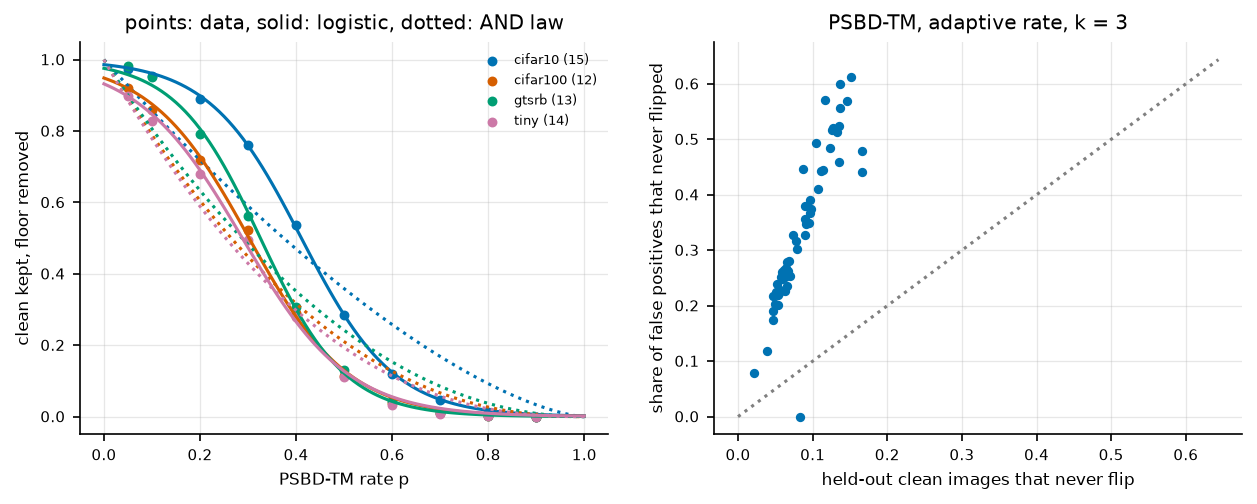

**C11, verdict true.** Clean fragility is a per-image critical rate (a logistic spread across images), not a fixed number of tokens every image needs. Key number: median critical rate 0.288 to 0.411 by dataset, logistic RMSE 0.005 to 0.015 against 0.057 to 0.111 for the AND law, flip correlation within an image 0.688. Control: the homogeneous AND law fitted to the same curves. Evidence: `results/_experiments/why_psbd_works/cached_reads.json`, `clean_fragility.curves` and `median_intra_image_correlation`.

**C12, verdict partial.** The clean images that never flip are the false positives. Key number: 0.087 of held-out clean images never flip and they make up 0.339 of the false positives. Control: the share they would take if flipping did not matter, their own share 0.087. Evidence: `results/_experiments/why_psbd_works/cached_reads.json`, `clean_fragility.mean_never_flip_share` and `mean_false_positive_never_flip_share`.

In [22]:
WHY = EXPERIMENTS / "why_psbd_works"
cached_reads = read_json(WHY / "cached_reads.json")
READS_SOURCE = "`results/_experiments/why_psbd_works/cached_reads.json`"
if cached_reads is None:
    register(
        "C11",
        "s4",
        "clean fragility",
        "ours",
        "pending",
        "pending",
        "pending",
        READS_SOURCE,
    )
    register(
        "C12",
        "s4",
        "never-flip images",
        "ours",
        "pending",
        "pending",
        "pending",
        READS_SOURCE,
    )
else:
    fragility = cached_reads["clean_fragility"]
    figure, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    plotted = {"curves": fragility["curves"]}
    grid = np.linspace(0, 1, 101)
    for index, (dataset, curve) in enumerate(sorted(fragility["curves"].items())):
        rates = np.array(curve["rates"])
        scaled = (np.array(curve["keep"]) - curve["floor"]) / (1 - curve["floor"])
        logistic = 1 / (
            1 + np.exp((grid - curve["logistic_median"]) / curve["logistic_scale"])
        )
        and_law = (1 - grid) ** curve["and_units"]
        color = OKABE_ITO[index]
        axes[0].scatter(
            rates, scaled, color=color, s=14, label=f"{dataset} ({curve['models']})"
        )
        axes[0].plot(grid, logistic, color=color)
        axes[0].plot(grid, and_law, color=color, linestyle=":")
    axes[0].set_xlabel(f"{TM} rate p")
    axes[0].set_ylabel("clean kept, floor removed")
    axes[0].set_title("points: data, solid: logistic, dotted: AND law")
    axes[0].legend(fontsize=6)

    per_model = pd.DataFrame(fragility["per_model"])
    per_model["never_flip_share"] = per_model["validation_hist"].map(
        lambda hist: hist[0]
    )
    axes[1].scatter(
        per_model["never_flip_share"],
        per_model["false_positive_never_flip_share"],
        color=CLEAN_COLOR,
        s=12,
    )
    limit = float(per_model["false_positive_never_flip_share"].max()) * 1.05
    axes[1].plot([0, limit], [0, limit], color="grey", linestyle=":")
    axes[1].set_xlabel("held-out clean images that never flip")
    axes[1].set_ylabel("share of false positives that never flipped")
    axes[1].set_title(f"{TM}, adaptive rate, k = 3")
    plotted["per_model"] = per_model[
        ["folder", "never_flip_share", "false_positive_never_flip_share"]
    ].to_dict("records")
    save_figure(figure, "clean_fragility", [READS_SOURCE], plotted)

    curves = fragility["curves"]
    logistic_wins = all(c["logistic_rmse"] < c["and_rmse"] for c in curves.values())
    register(
        "C11",
        "s4",
        "Clean fragility is a per-image critical rate (a logistic spread across images), not a fixed number of tokens every image needs",
        "ours, `docs/why-psbd-works-theory.md`",
        "true" if logistic_wins else "partial",
        f"median critical rate {number(min(c['logistic_median'] for c in curves.values()))} to "
        f"{number(max(c['logistic_median'] for c in curves.values()))} by dataset, logistic RMSE "
        f"{number(min(c['logistic_rmse'] for c in curves.values()))} to {number(max(c['logistic_rmse'] for c in curves.values()))} "
        f"against {number(min(c['and_rmse'] for c in curves.values()))} to {number(max(c['and_rmse'] for c in curves.values()))} "
        f"for the AND law, flip correlation within an image {number(fragility['median_intra_image_correlation'])}",
        "the homogeneous AND law fitted to the same curves",
        f"{READS_SOURCE}, `clean_fragility.curves` and `median_intra_image_correlation`",
    )
    never = fragility["mean_never_flip_share"]
    false_positive = fragility["mean_false_positive_never_flip_share"]
    register(
        "C12",
        "s4",
        "The clean images that never flip are the false positives",
        "ours, `docs/why-psbd-works-theory.md`",
        "true"
        if false_positive >= 0.5
        else "partial"
        if false_positive > never
        else "false",
        f"{number(never)} of held-out clean images never flip and they make up {number(false_positive)} of the false positives",
        f"the share they would take if flipping did not matter, their own share {number(never)}",
        f"{READS_SOURCE}, `clean_fragility.mean_never_flip_share` and `mean_false_positive_never_flip_share`",
    )

**What this does not show.** The fits are to dataset means of the ladder and treat the default-class floor as constant. The critical rate is a description of how clean images break. Why some clean images never break is not measured.

<a id="s5"></a>
## Alternative explanations

4 accounts claim to explain PSBD without routing. The score might only read confidence. Triggered inputs might be out of distribution. A LayerNorm might absorb noise and not masks. IBD-PSC's theorem says amplification drives clean inputs onto the target.

**Confidence.** **Claim.** A backdoored model is more confident on triggered inputs, and PSU only restates that. **Prediction if true.** No score beats A*(P_c), the AUROC of the cross-fitted likelihood ratio of unperturbed confidence, the best any function of confidence can do. **Experiment.** A* per model from the cached baselines against PSBD-TM's and PSBD-RD's AUROC. **Control.** Raw confidence, which understates A* because the likelihood ratio is not monotone in confidence.

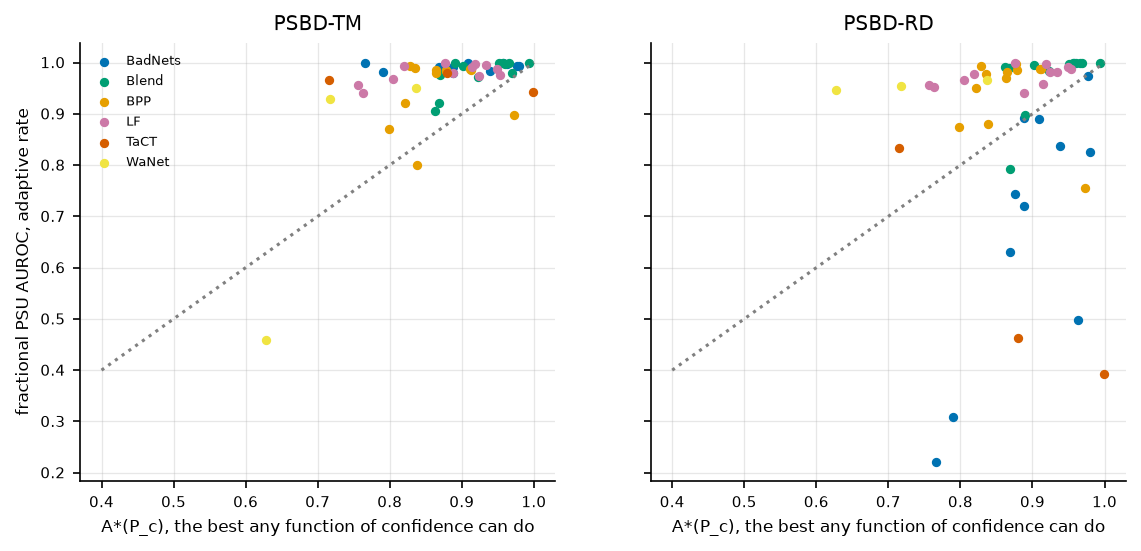

**C13, verdict false.** PSBD-TM's score is just the model's confidence in its answer. Key number: A* averages 0.881 on the 54-model panel against 0.688 for raw confidence. PSBD-TM is above it on 50 of 54 models and by at least 0.02 on 46. Its mean margin is +0.082. The theory note (`docs/why-psbd-works-theory.md`) read the same ceiling as 0.873 with PSBD-TM above it on 52 of 57 models, on the 57-model panel of 2026-09-24. Control: the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels. Evidence: `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]`.

**C14, verdict partial.** PSBD-RD's score is just the model's confidence in its answer. Key number: A* averages 0.881 on the 54-model panel against 0.688 for raw confidence. PSBD-RD is above it on 40 of 54 models and by at least 0.02 on 37. Its mean margin is +0.003. Control: the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels. Evidence: `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]`.

In [23]:
if cached_reads is not None:
    ceiling = pd.DataFrame(cached_reads["refutations"]["confidence_ceiling"])
    detectors = pd.DataFrame(cached_reads["refutations"]["per_model"])[
        ["folder", "psbd_tm", "psbd_rd"]
    ]
    ceiling = ceiling.merge(detectors, on="folder")
    ceiling = ceiling[ceiling["folder"].isin(PANEL)]
    p1_margin = read_json(WHY / "summary.json")["thresholds"]["p1_margin"]
    figure, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
    plotted = {}
    for axis, column, label in zip(axes, ("psbd_tm", "psbd_rd"), (TM, RD)):
        for attack, group in ceiling.groupby("attack"):
            axis.scatter(
                group["a_star"],
                group[column],
                s=12,
                color=ATTACK_COLORS.get(attack),
                label=attack_label(attack),
            )
        axis.plot([0.4, 1], [0.4, 1], color="grey", linestyle=":")
        axis.set_xlabel("A*(P_c), the best any function of confidence can do")
        axis.set_title(label)
        plotted[label] = ceiling[["folder", "attack", "a_star", column]].to_dict(
            "records"
        )
    axes[0].set_ylabel("fractional PSU AUROC, adaptive rate")
    axes[0].legend(fontsize=6)
    save_figure(figure, "confidence_ceiling", [READS_SOURCE], plotted)

    old_panel = doc_numbers(
        "docs/why-psbd-works-theory.md",
        r"That bound is ([0-9.]+) \(cross-fitted\).*?PSBD-TM exceeds it on (\d+) of (\d+) models",
    )
    old_text = (
        f". The theory note (`docs/why-psbd-works-theory.md`) read the same ceiling as {old_panel[0]} "
        f"with {TM} above it on {old_panel[1]} of {old_panel[2]} models, on the 57-model panel of 2026-09-24"
        if old_panel
        else ""
    )
    for cid, column, label in (("C13", "psbd_tm", TM), ("C14", "psbd_rd", RD)):
        margin = ceiling[column] - ceiling["a_star"]
        beats = int((margin >= p1_margin).sum())
        above = int((margin > 0).sum())
        verdict = (
            "false"
            if beats > len(ceiling) / 2 and margin.mean() >= p1_margin
            else "partial"
        )
        register(
            cid,
            "s5",
            f"{label}'s score is just the model's confidence in its answer",
            "reviewer reading P1, `experiments/psu_vs_confidence/`",
            verdict,
            f"A* averages {number(ceiling['a_star'].mean())} on the {len(ceiling)}-model panel against "
            f"{number(ceiling['raw_confidence'].mean())} for raw confidence. {label} is above it on {above} of {len(ceiling)} "
            f"models and by at least {p1_margin} on {beats}. Its mean margin is {signed(margin.mean())}{old_text if cid == 'C13' else ''}",
            "the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels",
            f"{READS_SOURCE}, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]`",
        )

**Out of distribution.** **Claim.** A trigger makes an image unusual, and PSBD flags unusual inputs. **Prediction if true.** The same triggered images are flagged on a benign model, and images of another dataset are flagged more often than clean ones. **Experiment.** The benign references scored on the same triggered splits, and foreign-dataset images under PSBD-TM's threshold on the `why_psbd_works` models. **Control.** The clean images of each model, flagged at the quantile by construction.

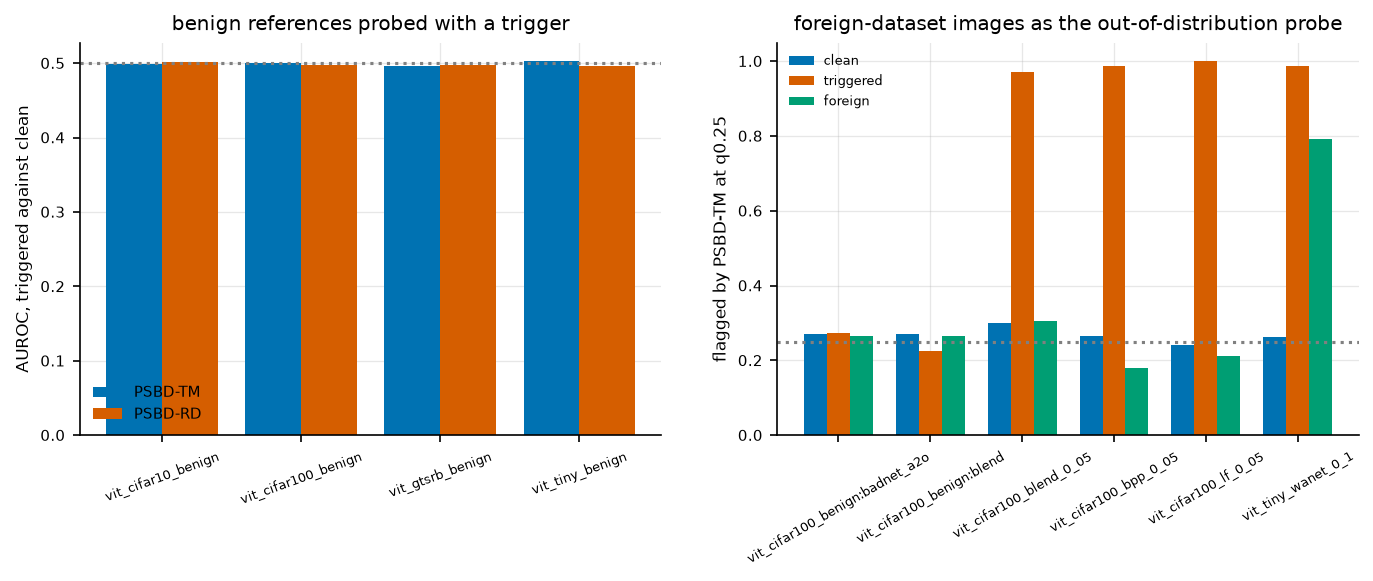

**C15, verdict false.** PSBD flags triggered inputs because they are unusual, out-of-distribution inputs. Key number: on the 4 benign references the same triggered images score PSBD-TM AUROC 0.500 and PSBD-RD 0.499, and the paper's confidence-null record reads 0.505. The foreign minus clean flagged share ranges from -0.086 to 0.531 on the 4 backdoored models measured. Control: benign models shown the same triggers, and clean images of another dataset. Evidence: `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.benign[]`, `paper/headline.json` `ConfidenceNullBenignPsu` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].operators.token_mask.flagged`.

In [24]:
why_summary = read_json(WHY / "summary.json")
WHY_SOURCE = "`results/_experiments/why_psbd_works/summary.json`"
if cached_reads is not None and why_summary is not None:
    benign = pd.DataFrame(cached_reads["refutations"]["benign"])
    flags = [
        {
            "model": model["name"],
            "group": model["group"],
            **{
                split: model["operators"]["token_mask"]["flagged"][split]
                for split in ("clean", "triggered", "foreign")
            },
        }
        for model in why_summary["per_model"]
    ]
    flags = pd.DataFrame(flags)
    figure, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    positions = np.arange(len(benign))
    axes[0].bar(
        positions - 0.2, benign["psbd_tm"], width=0.4, color=CLEAN_COLOR, label=TM
    )
    axes[0].bar(
        positions + 0.2, benign["psbd_rd"], width=0.4, color=TRIGGERED_COLOR, label=RD
    )
    axes[0].axhline(0.5, color="grey", linestyle=":")
    axes[0].set_xticks(positions, benign["folder"], rotation=20, fontsize=6)
    axes[0].set_ylabel("AUROC, triggered against clean")
    axes[0].set_title("benign references probed with a trigger")
    axes[0].legend()
    positions = np.arange(len(flags))
    for offset, split, color in (
        (-0.25, "clean", CLEAN_COLOR),
        (0.0, "triggered", TRIGGERED_COLOR),
        (0.25, "foreign", OKABE_ITO[2]),
    ):
        axes[1].bar(
            positions + offset, flags[split], width=0.25, color=color, label=split
        )
    axes[1].axhline(HEADLINE_QUANTILE, color="grey", linestyle=":")
    axes[1].set_xticks(positions, flags["model"], rotation=30, fontsize=6)
    axes[1].set_ylabel(f"flagged by {TM} at q{HEADLINE_QUANTILE}")
    axes[1].set_title("foreign-dataset images as the out-of-distribution probe")
    axes[1].legend(fontsize=6)
    save_figure(
        figure,
        "out_of_distribution",
        [READS_SOURCE, WHY_SOURCE],
        {
            "benign": benign[["folder", "psbd_tm", "psbd_rd"]].to_dict("records"),
            "flags": flags.to_dict("records"),
        },
    )
    backdoored = flags[~flags["group"].str.startswith("benign")]
    foreign_excess = backdoored["foreign"] - backdoored["clean"]
    register(
        "C15",
        "s5",
        "PSBD flags triggered inputs because they are unusual, out-of-distribution inputs",
        "Doan et al. and folk reading P5",
        "false" if abs(benign["psbd_tm"].mean() - 0.5) < 0.05 else "partial",
        f"on the {len(benign)} benign references the same triggered images score {TM} AUROC "
        f"{number(benign['psbd_tm'].mean())} and {RD} {number(benign['psbd_rd'].mean())}, and the paper's "
        f"confidence-null record reads {macro('ConfidenceNullBenignPsu')}. The foreign minus clean flagged share ranges from "
        f"{number(foreign_excess.min())} to {number(foreign_excess.max())} on the {len(backdoored)} backdoored models measured",
        "benign models shown the same triggers, and clean images of another dataset",
        f"{READS_SOURCE}, `refutations.benign[]`, `paper/headline.json` `ConfidenceNullBenignPsu` and "
        f"{WHY_SOURCE}, `per_model[].operators.token_mask.flagged`",
    )
else:
    register(
        "C15",
        "s5",
        "out of distribution",
        "folk reading P5",
        "pending",
        "pending",
        "pending",
        READS_SOURCE,
    )

**LayerNorm absorption and the operator gap.** **Claims.** A LayerNorm divides by each token's standard deviation, so it undoes part of an additive disturbance and none of a mask (C16). That absorption was once offered as the reason Gaussian noise trails token masking at the attention input (C17). The theory note replaces it with a read-structure account: a masked read is intact or gone while a noisy read is degraded everywhere. A patch trigger needs only 1 intact read (C18). **Experiment.** The absorption record measures the disturbance before and after the norm at several injected sizes, and the ladders give each model's AUROC at the matched rule for both operators. **Control.** Positions no LayerNorm follows, and the matched-shift rule, which equalizes clean disturbance across operators.

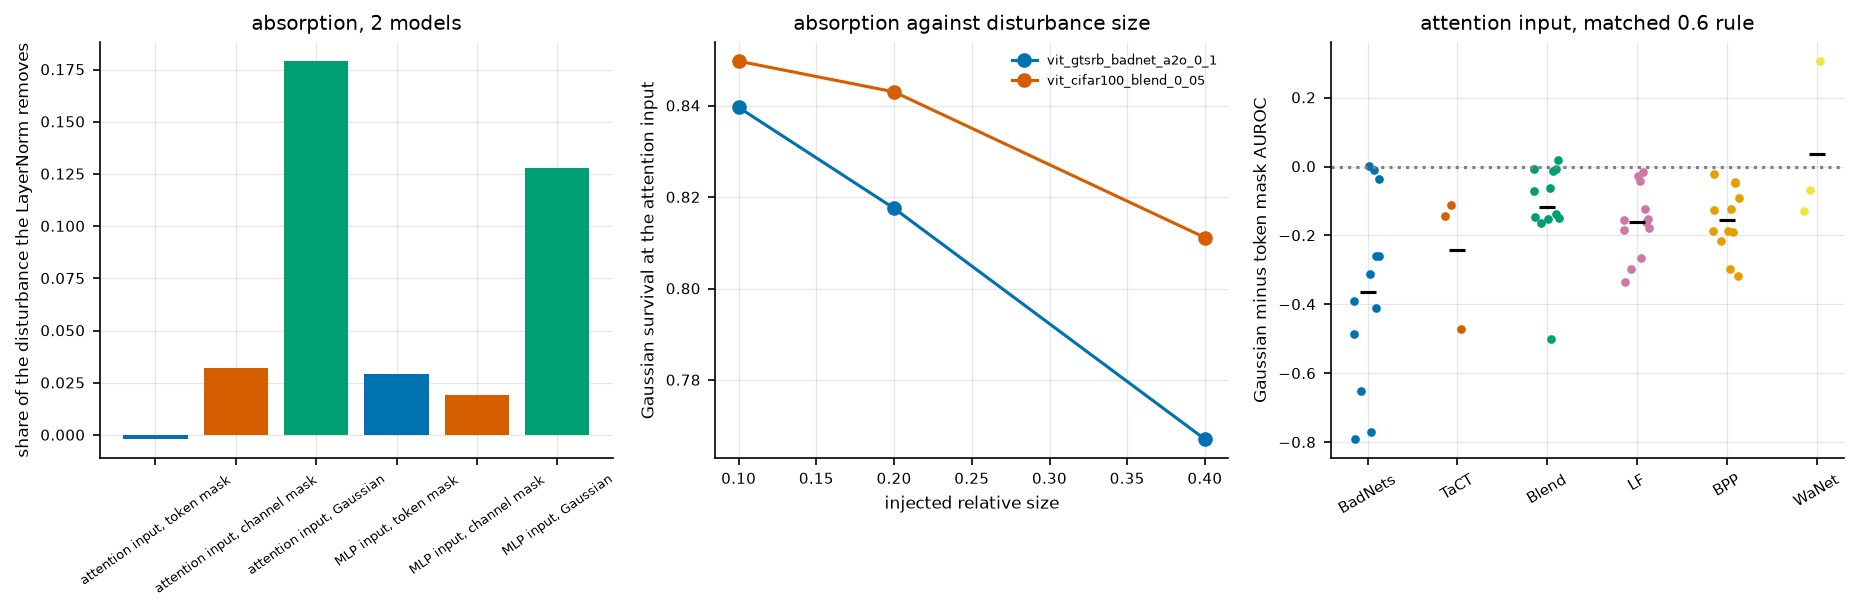

**C16, verdict true.** A LayerNorm removes part of an additive disturbance and passes a mask intact. Key number: at the attention input the norm removes 0.179 of Gaussian noise and -0.002 of a token mask, on 2 models. Control: positions no LayerNorm follows, survival 1.000. Evidence: `paper/headline.json`, `Absorption*` macros from `results/<folder>/layernorm_absorption.json`.

**C17, verdict false.** LayerNorm absorption explains why Gaussian noise trails token masking at the attention input. Key number: Gaussian survival is already 0.840 to 0.850 at the smallest injected size and falls by at most 0.073 across sizes 0.1, 0.2, 0.4, so most of the absorption is an attenuation that does not grow with the disturbance, which the matched rule compensates by raising the rate. The gap at the matched rule is still -0.188 [-0.243, -0.139]. Control: the matched-shift rule, which equalizes clean disturbance across operators. Evidence: `results/<folder>/layernorm_absorption.json` `rows[].survival` and `results/_experiments/theory_checks/ladders.json`.

**C18, verdict open.** Token masking leaves exact reads or none while noise degrades every read, which gives a negative gap largest on patch triggers. Key number: mean gap by attack, most negative first: BadNets -0.365, TaCT -0.242, LF -0.161, BPP -0.154, Blend -0.116, WaNet +0.036. Patch triggers lead the ordering the account predicts. WaNet reads +0.036. Control: none yet, the ordering is a consistency check and no experiment isolates the read structure. Evidence: `results/_experiments/theory_checks/ladders.json`, `before_attention_norm_gaussian` and `before_attention_norm_token_mask` ladders.

In [25]:
ladders = read_json(EXPERIMENTS / "theory_checks" / "ladders.json")
LADDER_SOURCE = "`results/_experiments/theory_checks/ladders.json`"
ABSORPTION_MACROS = {
    ("attention input", "token mask"): "AbsorptionAttentionInputTokenMaskRemoved",
    ("attention input", "channel mask"): "AbsorptionAttentionInputChannelMaskRemoved",
    ("attention input", "Gaussian"): "AbsorptionAttentionInputGaussianRemoved",
    ("MLP input", "token mask"): "AbsorptionMlpInputTokenMaskRemoved",
    ("MLP input", "channel mask"): "AbsorptionMlpInputChannelMaskRemoved",
    ("MLP input", "Gaussian"): "AbsorptionMlpInputGaussianRemoved",
}


def matched_auroc(ladder):
    # A ladder row is (rate, validation shift, triggered shift, fractional AUROC,
    # absolute AUROC), and the comparison reads the rate of the matched rule.
    shift = {row[0]: row[1] for row in ladder}
    rate = select_rate_at_matched_shift(shift, PLACEMENT_MATCH_TARGET)
    auroc = next(row[3] for row in ladder if row[0] == rate)
    return auroc


absorption_records = {
    folder: read_json(Path("results") / folder / "layernorm_absorption.json")
    for folder in ("vit_gtsrb_badnet_a2o_0_1", "vit_cifar100_blend_0_05")
}
if ladders is None or None in absorption_records.values():
    for cid in ("C16", "C17", "C18"):
        register(
            cid,
            "s5",
            "LayerNorm",
            "ours",
            "pending",
            "pending",
            "pending",
            LADDER_SOURCE,
        )
else:
    gaps = defaultdict(list)
    for folder in PANEL:
        ladder = ladders[folder]
        gap = matched_auroc(ladder["before_attention_norm_gaussian"]) - matched_auroc(
            ladder["before_attention_norm_token_mask"]
        )
        gaps[ladder["attack"]].append(gap)
    all_gaps = [gap for values in gaps.values() for gap in values]
    assert f"{np.mean(all_gaps):.3f}" == macro("GaussianMinusTokenMaskAttentionNorm"), (
        np.mean(all_gaps)
    )

    survival_by_size = defaultdict(list)
    for folder, record in absorption_records.items():
        for row in record["rows"]:
            if (
                row["position"] == "before_attention_norm"
                and row["operator"] == "gaussian"
            ):
                survival_by_size[(folder, row["target"])].append(row["survival"])
    figure, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    labels = [f"{position}, {operator}" for position, operator in ABSORPTION_MACROS]
    removed = [float(macro(name)) for name in ABSORPTION_MACROS.values()]
    axes[0].bar(
        np.arange(len(removed)),
        removed,
        color=[OKABE_ITO[i % 3] for i in range(len(removed))],
    )
    axes[0].set_xticks(np.arange(len(removed)), labels, fontsize=6, rotation=35)
    axes[0].set_ylabel("share of the disturbance the LayerNorm removes")
    axes[0].set_title(f"absorption, {macro('AbsorptionModels')} models")
    for index, folder in enumerate(absorption_records):
        sizes = sorted({size for f, size in survival_by_size if f == folder})
        axes[1].plot(
            sizes,
            [np.mean(survival_by_size[(folder, size)]) for size in sizes],
            marker="o",
            color=OKABE_ITO[index],
            label=folder,
        )
    axes[1].set_xlabel("injected relative size")
    axes[1].set_ylabel("Gaussian survival at the attention input")
    axes[1].set_title("absorption against disturbance size")
    axes[1].legend(fontsize=6)
    attacks = [attack for attack in ATTACK_ORDER if attack in gaps]
    for index, attack in enumerate(attacks):
        axes[2].scatter(
            index + jitter(len(gaps[attack])),
            gaps[attack],
            s=10,
            color=ATTACK_COLORS[attack],
        )
        axes[2].scatter(
            index, np.mean(gaps[attack]), s=60, marker="_", color=CONTROL_COLOR
        )
    axes[2].axhline(0, color="grey", linestyle=":")
    axes[2].set_xticks(
        np.arange(len(attacks)), [attack_label(a) for a in attacks], rotation=30
    )
    axes[2].set_ylabel("Gaussian minus token mask AUROC")
    axes[2].set_title(f"attention input, matched {PLACEMENT_MATCH_TARGET} rule")
    save_figure(
        figure,
        "layernorm_and_operator_gap",
        [
            LADDER_SOURCE,
            "`paper/headline.json`",
            "`results/<folder>/layernorm_absorption.json`",
        ],
        {
            "removed": dict(zip(labels, removed)),
            "survival": {f"{f}|{s}": v for (f, s), v in survival_by_size.items()},
            "gaps": dict(gaps),
        },
    )

    register(
        "C16",
        "s5",
        "A LayerNorm removes part of an additive disturbance and passes a mask intact",
        "ours, H47 and literature memo L25",
        "true"
        if float(macro("AbsorptionAttentionInputGaussianRemoved"))
        > float(macro("AbsorptionAttentionInputTokenMaskRemoved")) + 0.05
        else "partial",
        f"at the attention input the norm removes {macro('AbsorptionAttentionInputGaussianRemoved')} of Gaussian noise and "
        f"{macro('AbsorptionAttentionInputTokenMaskRemoved')} of a token mask, on {macro('AbsorptionModels')} models",
        f"positions no LayerNorm follows, survival {macro('AbsorptionControlSurvival')}",
        "`paper/headline.json`, `Absorption*` macros from `results/<folder>/layernorm_absorption.json`",
    )
    injected_sizes = sorted({size for _, size in survival_by_size})
    smallest_size_survival = [
        np.mean(survival_by_size[(folder, injected_sizes[0])])
        for folder in absorption_records
    ]
    survival_spread = max(
        np.ptp(
            [
                np.mean(survival_by_size[(folder, size)])
                for size in sorted({s for f, s in survival_by_size if f == folder})
            ]
        )
        for folder in absorption_records
    )
    register(
        "C17",
        "s5",
        "LayerNorm absorption explains why Gaussian noise trails token masking at the attention input",
        "ours, `experiments/residual_stream_mechanism/` before 2026-09-29",
        "false",
        f"Gaussian survival is already {number(min(smallest_size_survival))} to {number(max(smallest_size_survival))} at the smallest "
        f"injected size and falls by at most {number(survival_spread)} across sizes {', '.join(number(size, 1) for size in injected_sizes)}, "
        f"so most of the absorption is an attenuation that does not grow with the disturbance, which the matched rule compensates "
        f"by raising the rate. The gap at the matched rule is still "
        f"{macro('GaussianMinusTokenMaskAttentionNorm')} [{macro('GaussianMinusTokenMaskAttentionNormLow')}, "
        f"{macro('GaussianMinusTokenMaskAttentionNormHigh')}]",
        "the matched-shift rule, which equalizes clean disturbance across operators",
        f"`results/<folder>/layernorm_absorption.json` `rows[].survival` and {LADDER_SOURCE}",
    )
    order = sorted(attacks, key=lambda attack: np.mean(gaps[attack]))
    patch_first = set(order[:2]) == {"badnet_a2o", "tact"}
    register(
        "C18",
        "s5",
        "Token masking leaves exact reads or none while noise degrades every read, which gives a negative gap largest on patch triggers",
        "ours, `docs/why-psbd-works-theory.md`",
        "open",
        "mean gap by attack, most negative first: "
        + ", ".join(f"{attack_label(a)} {signed(np.mean(gaps[a]))}" for a in order)
        + f". Patch triggers {'lead' if patch_first else 'do not lead'} the ordering the account predicts. "
        f"WaNet reads {signed(np.mean(gaps['wanet']))}",
        "none yet, the ordering is a consistency check and no experiment isolates the read structure",
        f"{LADDER_SOURCE}, `before_attention_norm_gaussian` and `before_attention_norm_token_mask` ladders",
    )

**IBD-PSC's theorem.** **Claim.** Hou et al. prove that amplifying the normalization parameters makes the feature norm large enough that the backdoored model predicts the target for every input, so a poisoned input is the one whose prediction does not change. **Prediction if true.** At the top of the amplification ladder the shifted clean predictions land on the target. **Experiment.** `gain_scale` at the top factor of each model's ladder, the share of shifted clean predictions on the target and on the largest single class. **Control.** The benign references and the largest non-target class.

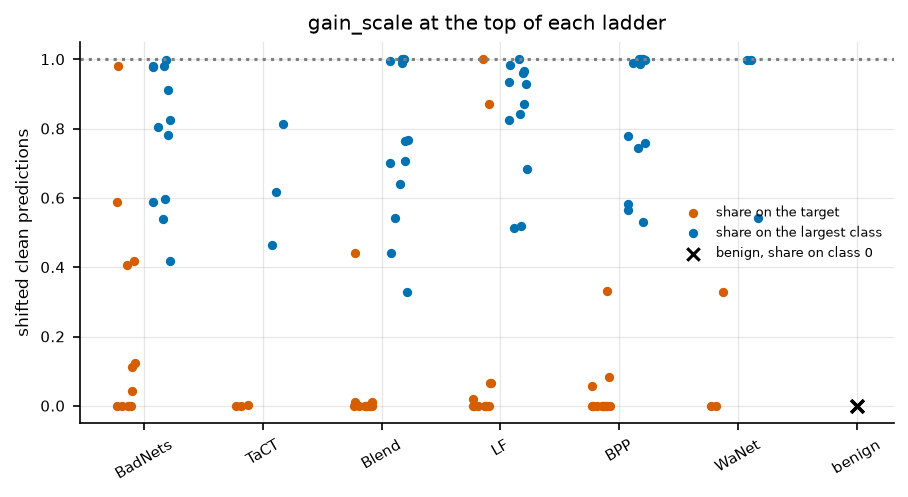

**C19, verdict false.** Amplifying the normalization parameters pushes every clean input onto the target, so a poisoned input is the one whose prediction stays (Theorem 3.1). Key number: at the top amplification factor (16) the target takes at least half of the shifted clean predictions on 4 of 54 models, with a median share of 0.000 (largest 1.000), while the largest single class takes 0.791 on average. The detector still works, PSBD-TM leads the calibrated port by only +0.027 [+0.004, +0.049]. Control: the share of the largest non-target class and the benign references. Evidence: `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.per_model[].gain_scale_top` and `paper/headline.json` `DetectorsAurocMargin`.

In [26]:
if cached_reads is not None:
    gain = pd.DataFrame(
        [
            {"folder": row["folder"], "attack": row["attack"], **row["gain_scale_top"]}
            for row in cached_reads["refutations"]["per_model"]
        ]
    )
    gain = gain[gain["folder"].isin(PANEL)]
    benign_gain = pd.DataFrame(
        [
            {"folder": row["folder"], **row["gain_scale_top"]}
            for row in cached_reads["refutations"]["benign"]
        ]
    )
    figure, axis = plt.subplots(figsize=(7, 3.3))
    attacks = [attack for attack in ATTACK_ORDER if attack in set(gain["attack"])]
    for index, attack in enumerate(attacks):
        rows = gain[gain["attack"] == attack]
        axis.scatter(
            index - 0.15 + jitter(len(rows), 0.08),
            rows["target_share"],
            s=12,
            color=TRIGGERED_COLOR,
            label="share on the target" if index == 0 else None,
        )
        axis.scatter(
            index + 0.15 + jitter(len(rows), 0.08),
            rows["largest_class_share"],
            s=12,
            color=CLEAN_COLOR,
            label="share on the largest class" if index == 0 else None,
        )
    axis.scatter(
        np.full(len(benign_gain), len(attacks)),
        benign_gain["target_share"],
        marker="x",
        color=CONTROL_COLOR,
        label="benign, share on class 0",
    )
    axis.axhline(1.0, color="grey", linestyle=":")
    axis.set_xticks(
        np.arange(len(attacks) + 1),
        [attack_label(a) for a in attacks] + ["benign"],
        rotation=30,
    )
    axis.set_ylabel("shifted clean predictions")
    axis.set_title("gain_scale at the top of each ladder")
    axis.legend(fontsize=6)
    save_figure(
        figure,
        "ibd_psc_theorem",
        [READS_SOURCE],
        {"panel": gain.to_dict("records"), "benign": benign_gain.to_dict("records")},
    )
    attracted = int((gain["target_share"] >= 0.5).sum())
    factors = sorted(set(gain["factor"]))
    register(
        "C19",
        "s5",
        "Amplifying the normalization parameters pushes every clean input onto the target, so a poisoned input is the one whose prediction stays (Theorem 3.1)",
        "IBD-PSC (Hou et al.)",
        verdict_from_share(attracted, len(gain)),
        f"at the top amplification factor ({', '.join(number(f, 0) for f in factors)}) the target takes at least half of the shifted "
        f"clean predictions on {attracted} of {len(gain)} models, with a median share of {number(gain['target_share'].median())} "
        f"(largest {number(gain['target_share'].max())}), while the largest single class takes {number(gain['largest_class_share'].mean())} "
        "on average. The detector still works, "
        f"{TM} leads the calibrated port by only {macro('DetectorsAurocMargin')} [{macro('DetectorsAurocMarginLow')}, {macro('DetectorsAurocMarginHigh')}]",
        "the share of the largest non-target class and the benign references",
        f"{READS_SOURCE}, `refutations.per_model[].gain_scale_top` and `paper/headline.json` `DetectorsAurocMargin`",
    )
else:
    register(
        "C19",
        "s5",
        "IBD-PSC theorem",
        "Hou et al.",
        "pending",
        "pending",
        "pending",
        READS_SOURCE,
    )

**What this does not show.** A* needs the triggered labels, so it is an oracle ceiling and not a detector. The foreign-image test covers the few `why_psbd_works` models so far, and on its WaNet model PSBD-TM flags foreign images far above clean ones, so the out-of-distribution account is refuted as the reason triggered inputs are flagged and not as a property of every model. No experiment removes the LayerNorm, and the read-structure account has no isolating test yet. The IBD-PSC verdict is about the theorem, not the detector, which works.

<a id="s6"></a>
## Neurons and directions

Li et al. say PSBD exploits "robust neuron bias paths", and the Fine-Pruning and ANP line treats a backdoor as a few units. The alternative is 1 linear direction in the residual stream that no coordinate carries. The ablation record removes either and reads the attack success rate, with random coordinates and random directions as controls, and `why_psbd_works` zeroes MLP hidden units in the late blocks. The first runs of the manifestation panel add the control the ablation lacked, the target class's own direction.

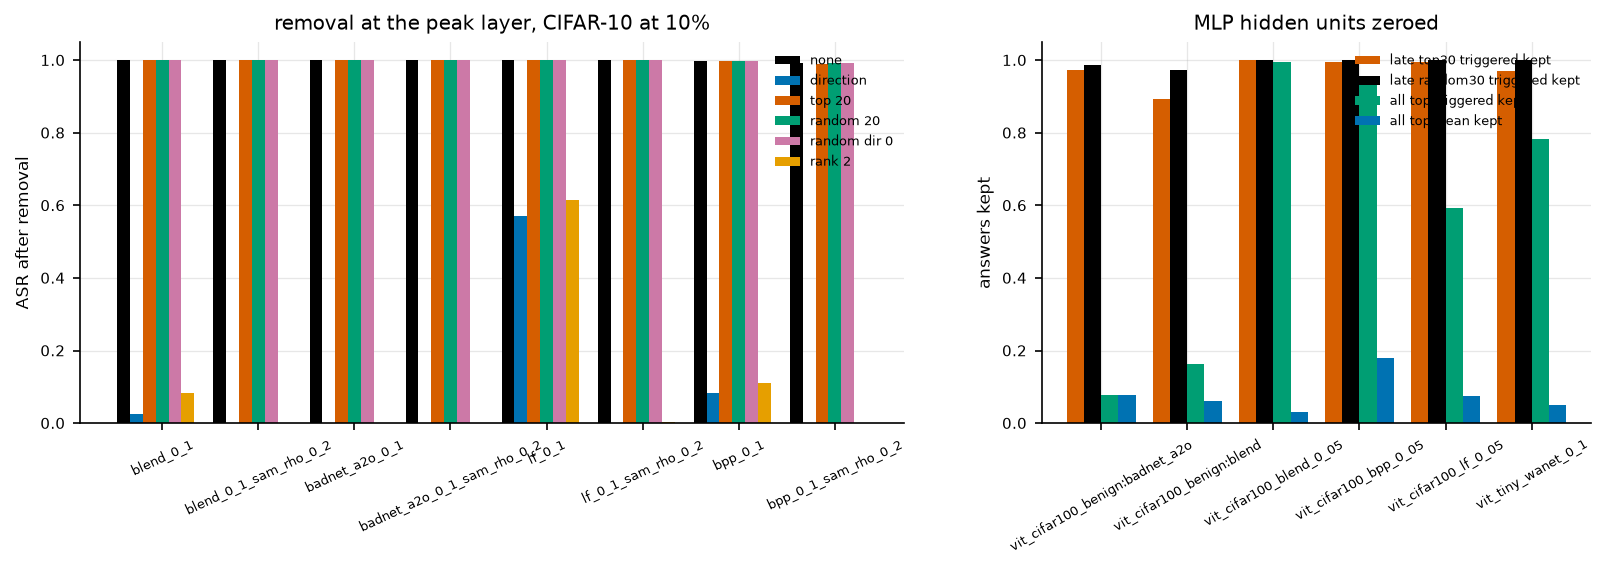

**C20, verdict false.** A few backdoor neurons carry the trigger, and PSBD works through their robust bias paths. Key number: zeroing the top 20 TAC coordinates leaves ASR at 0.998 or more on the 4 Adam checkpoints. Zeroing the 30 MLP units per late block the trigger raises most keeps 0.972 to 1.000 of triggered answers on 4 models. Control: as many random coordinates, random rank-1 directions and as many random MLP units. Evidence: `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`, `ablated.top_20` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].neurons`.

In [27]:
ablation = read_json(EXPERIMENTS / "backdoor_neurons" / "backdoor_neuron_ablation.json")
ABLATION_SOURCE = (
    "`results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`"
)
if ablation is None:
    register(
        "C20",
        "s6",
        "backdoor neurons",
        "Li et al.",
        "pending",
        "pending",
        "pending",
        ABLATION_SOURCE,
    )
else:
    variants = ("direction", "top_20", "random_20", "random_dir_0", "rank_2")
    figure, axes = plt.subplots(
        1, 2, figsize=(13, 3.3), gridspec_kw={"width_ratios": [3, 2]}
    )
    positions = np.arange(len(ablation))
    width = 0.8 / (len(variants) + 1)
    axes[0].bar(
        positions,
        [row["baseline"]["asr"] for row in ablation],
        width=width,
        color=CONTROL_COLOR,
        label="none",
    )
    for index, variant in enumerate(variants):
        axes[0].bar(
            positions + (index + 1) * width,
            [row["ablated"][variant]["asr"] for row in ablation],
            width=width,
            color=OKABE_ITO[index],
            label=variant.replace("_", " "),
        )
    axes[0].set_xticks(
        positions + 0.4,
        [row["folder_name"].replace("vit_cifar10_", "") for row in ablation],
        rotation=25,
        fontsize=6,
    )
    axes[0].set_ylabel("ASR after removal")
    axes[0].set_title("removal at the peak layer, CIFAR-10 at 10%")
    axes[0].legend(fontsize=6)
    neuron_rows = [
        {
            "model": model["name"],
            "group": model["group"],
            **{
                k: model["neurons"][k]
                for k in (
                    "late_top30_triggered_kept",
                    "late_random30_triggered_kept",
                    "all_top_triggered_kept",
                    "all_top_clean_kept",
                )
            },
        }
        for model in (why_summary["per_model"] if why_summary else [])
    ]
    neuron_rows = pd.DataFrame(neuron_rows)
    if len(neuron_rows):
        positions = np.arange(len(neuron_rows))
        for offset, column, color in (
            (-0.3, "late_top30_triggered_kept", TRIGGERED_COLOR),
            (-0.1, "late_random30_triggered_kept", CONTROL_COLOR),
            (0.1, "all_top_triggered_kept", OKABE_ITO[2]),
            (0.3, "all_top_clean_kept", CLEAN_COLOR),
        ):
            axes[1].bar(
                positions + offset,
                neuron_rows[column],
                width=0.2,
                color=color,
                label=column.replace("_", " "),
            )
        axes[1].set_xticks(positions, neuron_rows["model"], rotation=30, fontsize=6)
        axes[1].set_ylabel("answers kept")
        axes[1].set_title("MLP hidden units zeroed")
        axes[1].legend(fontsize=6)
    save_figure(
        figure,
        "backdoor_neurons",
        [ABLATION_SOURCE, WHY_SOURCE],
        {"ablation": ablation, "mlp_units": neuron_rows.to_dict("records")},
    )

    adam = [row for row in ablation if "sam" not in row["folder_name"]]
    top_min = min(row["ablated"]["top_20"]["asr"] for row in adam)
    backdoored_units = (
        neuron_rows[~neuron_rows["group"].str.startswith("benign")]
        if len(neuron_rows)
        else neuron_rows
    )
    units_text = (
        f". Zeroing the 30 MLP units per late block the trigger raises most keeps "
        f"{number(backdoored_units['late_top30_triggered_kept'].min())} to {number(backdoored_units['late_top30_triggered_kept'].max())} "
        f"of triggered answers on {len(backdoored_units)} models"
        if len(backdoored_units)
        else ""
    )
    register(
        "C20",
        "s6",
        "A few backdoor neurons carry the trigger, and PSBD works through their robust bias paths",
        "Li et al., the Fine-Pruning and ANP line",
        "false" if top_min >= KEEP_FLOOR else "partial",
        f"zeroing the top 20 TAC coordinates leaves ASR at {number(top_min)} or more on the {len(adam)} Adam checkpoints{units_text}",
        "as many random coordinates, random rank-1 directions and as many random MLP units",
        f"{ABLATION_SOURCE}, `ablated.top_20` and {WHY_SOURCE}, `per_model[].neurons`",
    )

**C21, verdict partial.** The backdoor is a single linear direction in the residual stream, distinct from the target class. Key number: removing the rank-1 direction takes ASR to 0.000 to 0.572 on the 4 Adam checkpoints. The first manifestation runs (7 backdoored models) add the missing control: removing the target class's own mean offset takes ASR to 0.000 to 0.985, removing the backdoor direction drops target-class recall to 0.140 to 0.920, and the part of the backdoor direction orthogonal to the target leaves ASR at 0.842 to 1.000. Control: random rank-1 directions, the target-class offset and the target-orthogonal part of the direction. Evidence: `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`, `ablated.direction` and `results/_experiments/backdoor_manifestation/runs/<run>.json`, `ablation.<last block>.variants`.

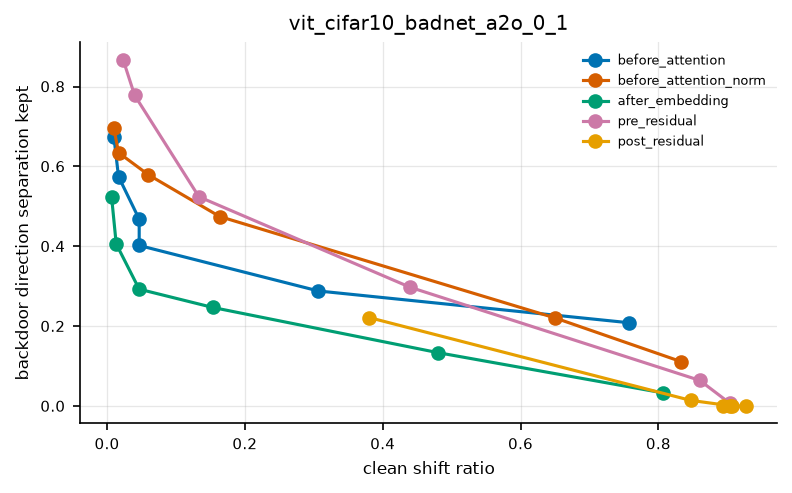

**C22, verdict partial.** PSBD-RD fails on BadNets because residual dropout erases the backdoor direction at every rate. Key number: separation kept under post_residual 0.222, 0.015, 0.000, 0.000, 0.000, 0.000 at rates 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, against 0.867, 0.778, 0.524, 0.297, 0.064, 0.008 under pre_residual, on 1 checkpoint. Control: the other placements on the same checkpoint and its unperturbed separation. Evidence: `results/vit_cifar10_badnet_a2o_0_1/dropout_direction_survival.json`, `placements.<name>[]`.

In [28]:
direction_asr = [row["ablated"]["direction"]["asr"] for row in adam] if ablation else []
manifestation_runs = {
    path.stem: read_json(path)
    for path in sorted((EXPERIMENTS / "backdoor_manifestation" / "runs").glob("*.json"))
}
manifestation_backdoored = {
    name: run for name, run in manifestation_runs.items() if not run["run"]["benign"]
}
MANIFESTATION_SOURCE = "`results/_experiments/backdoor_manifestation/runs/<run>.json`, `ablation.<last block>.variants`"
if ablation is not None:
    target_text = ""
    if manifestation_backdoored:
        last = {
            name: run["ablation"][str(run["num_blocks"])]["variants"]
            for name, run in manifestation_backdoored.items()
        }
        target_asr = [v["target_class_direction"]["asr"] for v in last.values()]
        recall = [v["direction"]["target_recall"] for v in last.values()]
        orthogonal = [v["direction_orthogonal_to_target"]["asr"] for v in last.values()]
        target_text = (
            f". The first manifestation runs ({len(last)} backdoored models) add the missing control: removing the "
            f"target class's own mean offset takes ASR to {number(min(target_asr))} to {number(max(target_asr))}, removing "
            f"the backdoor direction drops target-class recall to {number(min(recall))} to {number(max(recall))}, and the "
            f"part of the backdoor direction orthogonal to the target leaves ASR at {number(min(orthogonal))} to {number(max(orthogonal))}"
        )
    register(
        "C21",
        "s6",
        "The backdoor is a single linear direction in the residual stream, distinct from the target class",
        "Karayalçin et al., and ours (H16)",
        "partial",
        f"removing the rank-1 direction takes ASR to {number(min(direction_asr))} to {number(max(direction_asr))} on the "
        f"{len(adam)} Adam checkpoints{target_text}",
        "random rank-1 directions, the target-class offset and the target-orthogonal part of the direction",
        f"{ABLATION_SOURCE}, `ablated.direction` and {MANIFESTATION_SOURCE}",
    )

survival_record = read_json(
    "results/vit_cifar10_badnet_a2o_0_1/dropout_direction_survival.json"
)
SURVIVAL_SOURCE = "`results/vit_cifar10_badnet_a2o_0_1/dropout_direction_survival.json`, `placements.<name>[]`"
if survival_record is not None:
    figure, axis = plt.subplots(figsize=(6, 3.3))
    for index, (placement, rows) in enumerate(survival_record["placements"].items()):
        axis.plot(
            [r["clean_shift_ratio"] for r in rows],
            [r["separation_ratio"] for r in rows],
            marker="o",
            color=OKABE_ITO[index],
            label=placement,
        )
    axis.set_xlabel("clean shift ratio")
    axis.set_ylabel("backdoor direction separation kept")
    axis.set_title(survival_record["folder_name"])
    axis.legend(fontsize=6)
    save_figure(
        figure, "direction_survival", [SURVIVAL_SOURCE], survival_record["placements"]
    )
    post = survival_record["placements"]["post_residual"]
    pre = survival_record["placements"]["pre_residual"]
    register(
        "C22",
        "s6",
        f"{RD} fails on BadNets because residual dropout erases the backdoor direction at every rate",
        "ours, H3 and H20",
        "partial",
        f"separation kept under post_residual {', '.join(number(r['separation_ratio']) for r in post)} at rates "
        f"{', '.join(number(r['rate'], 2) for r in post)}, against {', '.join(number(r['separation_ratio']) for r in pre)} under pre_residual, on 1 checkpoint",
        "the other placements on the same checkpoint and its unperturbed separation",
        SURVIVAL_SOURCE,
    )

**What this does not show.** The ablation covers CIFAR-10 models at 10% poisoning and seed 0 only. Removing the backdoor direction also costs target-class recall, so until the manifestation panel reports, the direction cannot be told apart from the target class's evidence. The direction survival reading is 1 BadNets checkpoint, and PSBD-RD does detect global triggers, so an erased direction is not the whole story of PSBD-RD.

<a id="s7"></a>
## WaNet

WaNet is where the 2 placements disagree most, and it holds the panel's only model where PSBD-TM inverts. 3 accounts are tested. WaNet trains with a noise mode that labels randomly warped images with their true class, so a masked triggered input might read as a rejected warp and go home to its true class (E8, plan item X1). WaNet's trigger might be a coherence check that no single token can read (memo L26). And the inverted model might be a checkpoint accident rather than a recipe that defeats PSBD-TM (plan item X2).

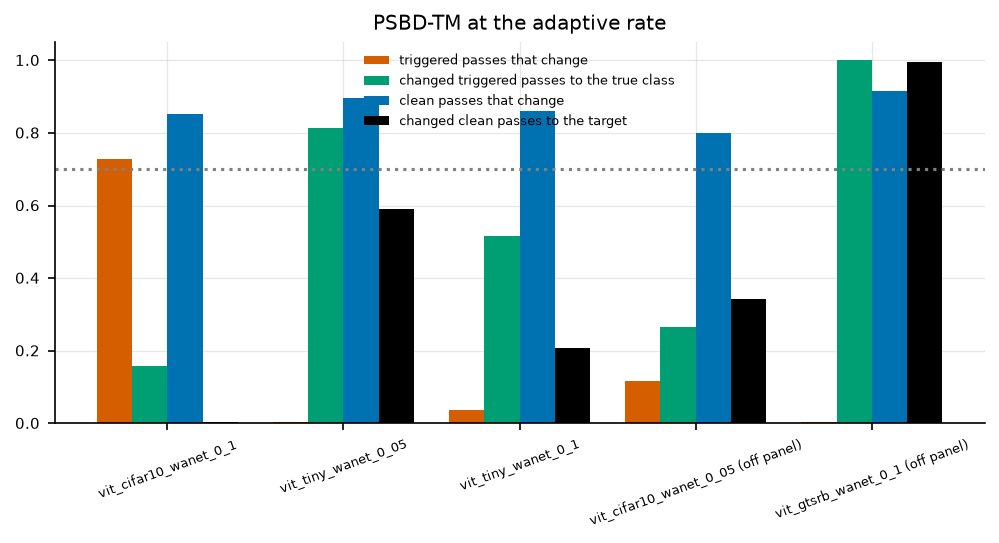

**C23, verdict false.** WaNet's noise mode sends a masked triggered input back to its true class. Key number: on the inverted cell `vit_cifar10_wanet_0_1` (PSBD-TM 0.459, PSBD-RD 0.947) 0.729 of triggered passes change and 0.158 of those reach the true class. On the other 4 WaNet models few triggered passes change (0.004 to 0.117). Control: the clean rows of the same models and the WaNet models that do not invert. Evidence: `experiments/literature_checks/wanet_destinations.py` on the stage-1 caches `results/<folder>/psbd/`.

In [29]:
X1_SOURCE = "`experiments/literature_checks/wanet_destinations.py` on the stage-1 caches `results/<folder>/psbd/`"
# E8's prediction as docs/simple-experiments-plan.md states it for X1: at least 0.7 of
# the changed triggered passes land on the true class.
E8_TRUE_CLASS_SHARE = 0.7
wanet_folders = [folder for folder in X1_FOLDERS if "_wanet_" in folder]
wanet_auroc = {
    row["folder"]: row
    for row in (cached_reads["refutations"]["per_model"] if cached_reads else [])
}
# X1 wrote no JSON record, so its reading is recomputed here with the script's own
# function. It reads the cached per-pass argmax only and runs no forward pass.
x1 = pd.DataFrame(
    [
        {"folder": folder, "panel": folder in PANEL, **destinations(folder)}
        for folder in wanet_folders
    ]
)
x1["psbd_tm"] = x1["folder"].map(lambda f: wanet_auroc.get(f, {}).get("psbd_tm"))
x1["psbd_rd"] = x1["folder"].map(lambda f: wanet_auroc.get(f, {}).get("psbd_rd"))
failing = x1[x1["panel"]].sort_values("psbd_tm").iloc[0]
figure, axis = plt.subplots(figsize=(8, 3.3))
positions = np.arange(len(x1))
for offset, column, color, label in (
    (-0.3, "triggered_changed", TRIGGERED_COLOR, "triggered passes that change"),
    (
        -0.1,
        "triggered_changed_to_true",
        OKABE_ITO[2],
        "changed triggered passes to the true class",
    ),
    (0.1, "clean_changed", CLEAN_COLOR, "clean passes that change"),
    (
        0.3,
        "clean_changed_to_target",
        CONTROL_COLOR,
        "changed clean passes to the target",
    ),
):
    axis.bar(positions + offset, x1[column], width=0.2, color=color, label=label)
axis.axhline(E8_TRUE_CLASS_SHARE, color="grey", linestyle=":")
axis.set_xticks(
    positions,
    [f"{f}{'' if p else ' (off panel)'}" for f, p in zip(x1["folder"], x1["panel"])],
    rotation=20,
    fontsize=6,
)
axis.set_title(f"{TM} at the adaptive rate")
axis.legend(fontsize=6)
save_figure(figure, "wanet_destinations", [X1_SOURCE], {"x1": x1.to_dict("records")})
others = x1[x1["folder"] != failing["folder"]]
register(
    "C23",
    "s7",
    "WaNet's noise mode sends a masked triggered input back to its true class",
    "WaNet's training recipe, plan account E8",
    "false" if failing["triggered_changed_to_true"] < E8_TRUE_CLASS_SHARE else "true",
    f"on the inverted cell `{failing['folder']}` ({TM} {number(failing['psbd_tm'])}, {RD} {number(failing['psbd_rd'])}) "
    f"{number(failing['triggered_changed'])} of triggered passes change and {number(failing['triggered_changed_to_true'])} "
    f"of those reach the true class. On the other {len(others)} WaNet models few triggered passes change "
    f"({number(others['triggered_changed'].min())} to {number(others['triggered_changed'].max())})",
    "the clean rows of the same models and the WaNet models that do not invert",
    X1_SOURCE,
)

The coherence probe fits a linear classifier on a single patch token, or on the class token, to tell the exact warp from a random warp of the same image, at blocks 4 to 8 and 12.

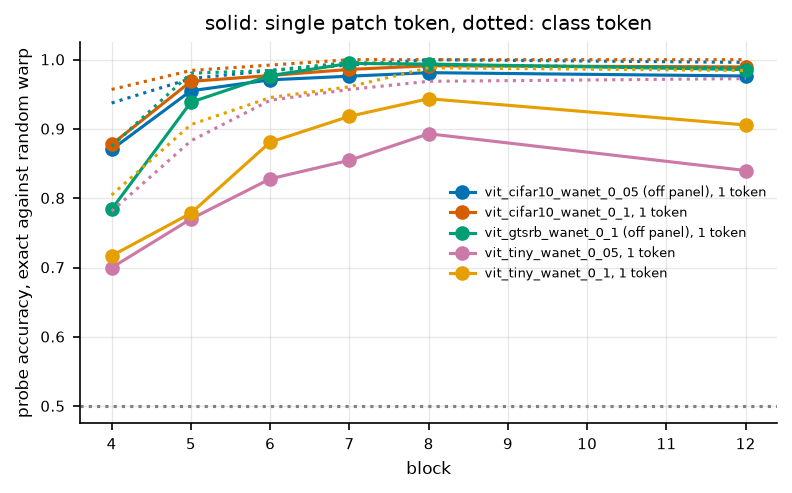

**C24, verdict false.** WaNet's trigger is a coherence check that no single token can read, so random masking cannot leave its evidence behind. Key number: a linear probe on a single patch token tells the exact warp from a random warp at 0.700 to 0.995 accuracy in blocks 4 to 8 on 5 models. Control: the same probe on the class token, and chance at 0.5. Evidence: `results/_experiments/why_psbd_works/wanet_probe__<folder>.json`, `blocks.<b>`.

In [30]:
probes = {
    path.stem.split("__", 1)[1]: read_json(path)
    for path in sorted((WHY).glob("wanet_probe__*.json"))
}
PROBE_SOURCE = (
    "`results/_experiments/why_psbd_works/wanet_probe__<folder>.json`, `blocks.<b>`"
)
if probes:
    figure, axis = plt.subplots(figsize=(6, 3.3))
    for index, (folder, record) in enumerate(sorted(probes.items())):
        blocks = sorted(record["blocks"], key=int)
        axis.plot(
            [int(b) for b in blocks],
            [record["blocks"][b]["token_probe_accuracy"] for b in blocks],
            marker="o",
            color=OKABE_ITO[index],
            label=f"{folder}{'' if folder in PANEL else ' (off panel)'}, 1 token",
        )
        axis.plot(
            [int(b) for b in blocks],
            [record["blocks"][b]["cls_probe_accuracy"] for b in blocks],
            linestyle=":",
            color=OKABE_ITO[index],
        )
    axis.axhline(0.5, color="grey", linestyle=":")
    axis.set_xlabel("block")
    axis.set_ylabel("probe accuracy, exact against random warp")
    axis.set_title("solid: single patch token, dotted: class token")
    axis.legend(fontsize=6)
    save_figure(figure, "wanet_coherence_probe", [PROBE_SOURCE], probes)
    token_accuracy = [
        record["blocks"][b]["token_probe_accuracy"]
        for record in probes.values()
        for b in record["blocks"]
        if int(b) <= 8
    ]
    register(
        "C24",
        "s7",
        "WaNet's trigger is a coherence check that no single token can read, so random masking cannot leave its evidence behind",
        "literature memo L26",
        # The prediction is a single-token probe near chance. Above 0.6 on every
        # block and model is far from chance, below it everywhere is near chance.
        "false"
        if min(token_accuracy) > 0.6
        else "true"
        if max(token_accuracy) <= 0.6
        else "partial",
        f"a linear probe on a single patch token tells the exact warp from a random warp at "
        f"{number(min(token_accuracy))} to {number(max(token_accuracy))} accuracy in blocks 4 to 8 on {len(probes)} models",
        "the same probe on the class token, and chance at 0.5",
        PROBE_SOURCE,
    )
else:
    register(
        "C24",
        "s7",
        "WaNet coherence check",
        "literature memo L26",
        "pending",
        "pending",
        "pending",
        PROBE_SOURCE,
    )

The replicates of the inverted cell carry the same recipe and data with seeds 1 and 2. Their sweeps are queued, and the verdict stays open until both are swept.

In [31]:
def adaptive_fractional_auroc(metrics, placement):
    block = metrics["placements"].get(placement)
    if block is None:
        return None
    rate = select_rate_adaptively(
        {row["rate"]: row["shift_ratio"]["validation"] for row in block["rates"]}
    )
    row = next((r for r in block["rates"] if r["rate"] == rate), None)
    auroc = (
        row["detection_psu_ratio"][f"q{HEADLINE_QUANTILE:.2f}"]["auroc"]
        if row
        else None
    )
    return auroc


replicates = {}
for seed in (1, 2):
    folder = f"{failing['folder']}_seed_{seed}"
    metrics = load_psbd_metrics("results", folder)
    replicates[folder] = (
        {
            placement: adaptive_fractional_auroc(metrics, placement)
            for placement in PLACEMENT_LABELS
        }
        if metrics
        else None
    )
X2_SOURCE = f"`results/{failing['folder']}_seed_{{1,2}}/psbd_metrics.json`"
landed = {folder: reading for folder, reading in replicates.items() if reading}
register(
    "C25",
    "s7",
    f"The inverted WaNet cell `{failing['folder']}` is a checkpoint accident and not a recipe that defeats {TM}",
    "ours, plan X2",
    "open",
    "; ".join(
        f"`{folder}` {TM} {number(reading[RECOMMENDED_PLACEMENT])}, {RD} {number(reading[PUBLISHED_PLACEMENT])}"
        for folder, reading in landed.items()
    )
    if landed
    else "pending, no replicate has been swept",
    f"the seed-0 cell, {TM} {number(failing['psbd_tm'])}",
    X2_SOURCE,
)

**C25, verdict open.** The inverted WaNet cell `vit_cifar10_wanet_0_1` is a checkpoint accident and not a recipe that defeats PSBD-TM. Key number: pending, no replicate has been swept. Control: the seed-0 cell, PSBD-TM 0.459. Evidence: `results/vit_cifar10_wanet_0_1_seed_{1,2}/psbd_metrics.json`.

**What this does not show.** X1 also reads WaNet models outside the panel, which miss the 2-point clean-accuracy bar and are marked off panel in the figure. The probe shows the warp is legible per token, which leaves open why random masking reaches WaNet's evidence (section 10's depth bands point to the early and middle blocks). Where the inverted cell's triggered shifts do land is plan item X1b.

<a id="s8"></a>
## Global-trigger redundancy

**Claim.** A global trigger is present in every token, so it stays legible from any 30% of them and survives token masking. **Prediction if true.** The excess retention of the attack success rate at 30% visible tokens is high and well above clean accuracy retention. **Experiment.** A fixed random pattern of visible patch tokens in every block, in section D of `why_token_masking_works` (3 patterns shared across models) and in `why_psbd_works` (20 patterns per model). **Control.** Clean accuracy retention at the same fraction, and the excess form, which removes a masked model's collapse onto the target.

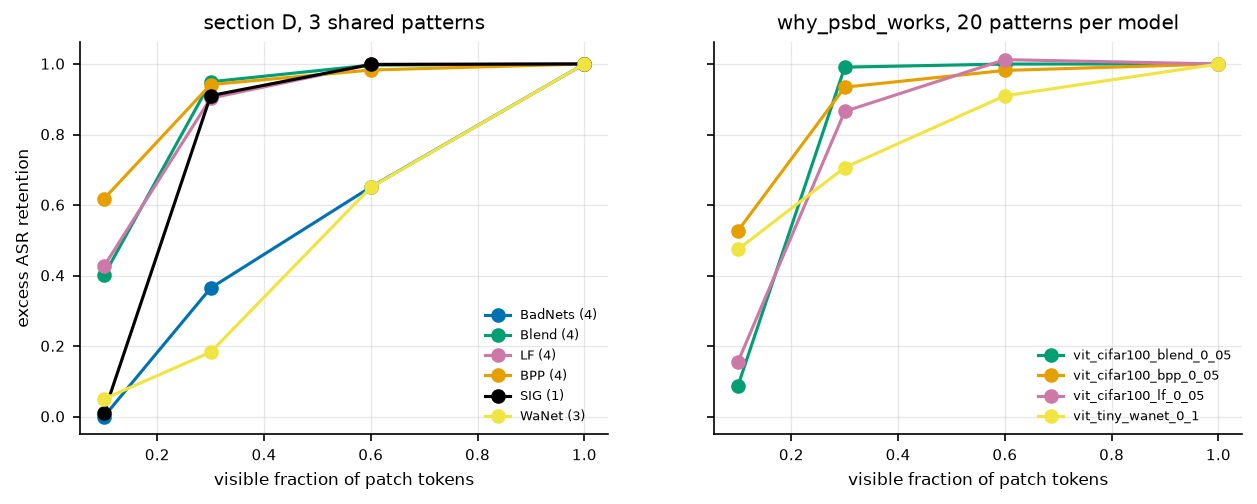

**C26, verdict open.** Global triggers stay legible from any 30% of the tokens, which is why token masking leaves them. Key number: Blend, LF and BPP keep 0.903 to 0.950 of their excess ASR at 30% visible in section D, but WaNet reads 0.183 there and `vit_tiny_wanet_0_1` 0.706 in `why_psbd_works`. Section D's WaNet models are `vit_cifar10_wanet_0_05`, `vit_gtsrb_wanet_0_1`, `vit_tiny_wanet_0_05`, of which 1 is in the panel. Control: clean accuracy retention at the same visible fraction, and the excess form that removes collapse onto the target. Evidence: `results/_experiments/why_token_masking_works/summary.json`, `visible_subsets` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].redundancy`.

In [32]:
if routing is not None and why_summary is not None:
    subsets = routing["visible_subsets"]
    section_d_wanet = sorted(path.stem for path in ROUTING.glob("*wanet*.json"))
    fractions = ("1.0", "0.6", "0.3", "0.1")
    figure, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
    plotted = {"section_d": {}, "why_psbd_works": {}}
    for attack in ("badnet_a2o", "blend", "lf", "bpp", "sig", "wanet"):
        if attack not in subsets:
            continue
        values = [subsets[attack][f]["excess_retention"] for f in fractions]
        axes[0].plot(
            [float(f) for f in fractions],
            values,
            marker="o",
            color=ATTACK_COLORS[attack],
            label=f"{attack_label(attack)} ({subsets[attack]['1.0']['models']})",
        )
        plotted["section_d"][attack] = dict(zip(fractions, values))
    axes[0].set_title("section D, 3 shared patterns")
    axes[0].set_xlabel("visible fraction of patch tokens")
    axes[0].set_ylabel("excess ASR retention")
    axes[0].legend(fontsize=6)
    for model in why_summary["per_model"]:
        if model["group"].startswith("benign") or model["redundancy"] is None:
            continue
        redundancy = model["redundancy"]
        present = [
            f
            for f in fractions
            if f in redundancy and "excess_retention" in redundancy[f]
        ]
        axes[1].plot(
            [float(f) for f in present],
            [redundancy[f]["excess_retention"] for f in present],
            marker="o",
            color=ATTACK_COLORS.get(model["attack"], CONTROL_COLOR),
            label=model["name"],
        )
        plotted["why_psbd_works"][model["name"]] = {
            f: redundancy[f]["excess_retention"] for f in present
        }
    axes[1].set_title("why_psbd_works, 20 patterns per model")
    axes[1].set_xlabel("visible fraction of patch tokens")
    axes[1].legend(fontsize=6)
    save_figure(
        figure, "global_trigger_redundancy", [ROUTING_SOURCE, WHY_SOURCE], plotted
    )

    general_wanet = [m for m in why_summary["per_model"] if m["attack"] == "wanet"]
    general_wanet_text = ", ".join(
        f"`{m['name']}` {number(m['redundancy']['0.3']['excess_retention'])}"
        for m in general_wanet
    )
    globals_d = [
        subsets[a]["0.3"]["excess_retention"]
        for a in ("blend", "lf", "bpp")
        if a in subsets
    ]
    register(
        "C26",
        "s8",
        "Global triggers stay legible from any 30% of the tokens, which is why token masking leaves them",
        "Karayalçin et al. (L23), Naseer et al. (L19)",
        "open",
        f"Blend, LF and BPP keep {number(min(globals_d))} to {number(max(globals_d))} of their excess ASR at 30% visible in section D, "
        f"but WaNet reads {number(subsets['wanet']['0.3']['excess_retention'])} there and {general_wanet_text} in `why_psbd_works`. "
        f"Section D's WaNet models are {', '.join(f'`{f}`' for f in section_d_wanet)}, of which "
        f"{sum(f in PANEL for f in section_d_wanet)} {'is' if sum(f in PANEL for f in section_d_wanet) == 1 else 'are'} in the panel",
        "clean accuracy retention at the same visible fraction, and the excess form that removes collapse onto the target",
        f"{ROUTING_SOURCE}, `visible_subsets` and {WHY_SOURCE}, `per_model[].redundancy`",
    )

**What this does not show.** The 2 records disagree on WaNet, and they differ in 2 ways at once: the models (section D used WaNet models that are not all in the panel) and the number and seeding of patterns. Until 1 of the 2 is held fixed, the disagreement cannot be assigned to either, so the claim stays open.

<a id="s9"></a>
## Where the backdoor lives

`experiments/backdoor_manifestation/` measures, per attack category and architecture, where the trigger changes the input, where the network reads it, at which depth the triggered representation leaves the clean one and whether the backdoor is a set of neurons or a direction, with the controls the earlier experiments lacked. Its panel is still running, and the figure shows the removal controls of the runs that have landed.

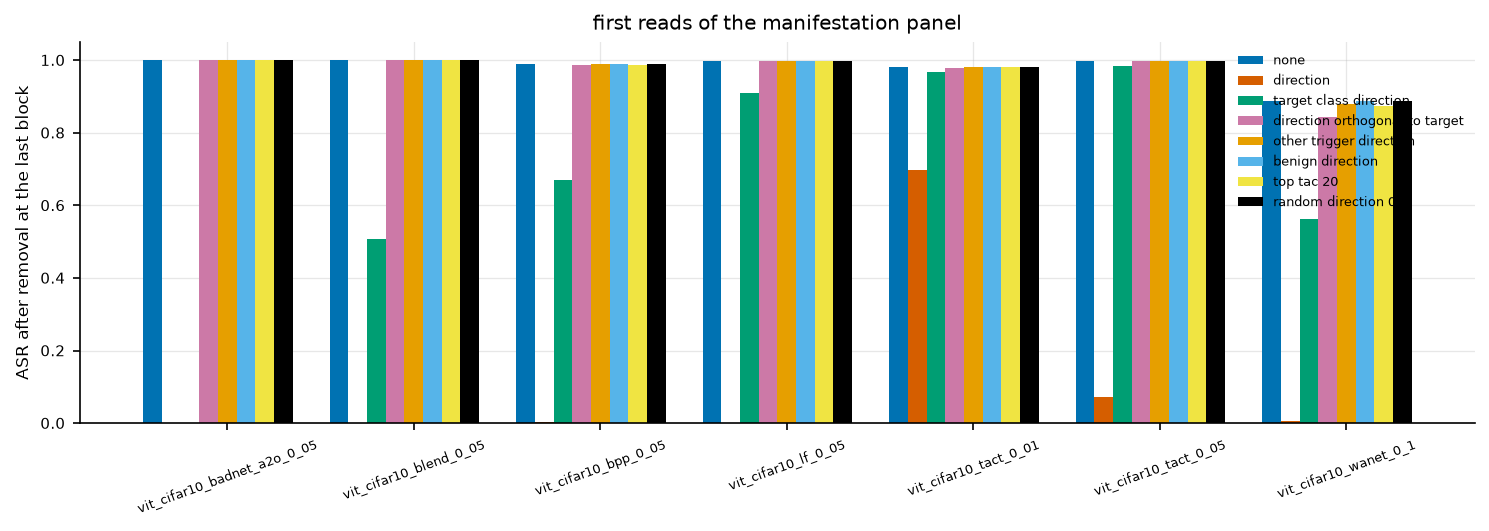

**C27, verdict pending.** Where each attack lives inside ViT-B/16 and Swin-S: depth of onset, readout, neurons or direction, per category. Key number: 7 backdoored and 10 benign-control runs have landed, summary not written yet. Control: benign models probed with the same trigger, isotropic, energy-matched and target-class directions. Evidence: `results/_experiments/backdoor_manifestation/runs/` and `summary.json`.

In [33]:
MANIFESTATION = EXPERIMENTS / "backdoor_manifestation"
manifestation_summary = read_json(MANIFESTATION / "summary.json")
if manifestation_backdoored:
    variants = (
        "none",
        "direction",
        "target_class_direction",
        "direction_orthogonal_to_target",
        "other_trigger_direction",
        "benign_direction",
        "top_tac_20",
        "random_direction_0",
    )
    names = sorted(manifestation_backdoored)
    figure, axis = plt.subplots(figsize=(12, 3.3))
    width = 0.8 / len(variants)
    plotted = {}
    for index, variant in enumerate(variants):
        values = [
            manifestation_backdoored[name]["ablation"][
                str(manifestation_backdoored[name]["num_blocks"])
            ]["variants"][variant]["asr"]
            for name in names
        ]
        axis.bar(
            np.arange(len(names)) + index * width,
            values,
            width=width,
            color=OKABE_ITO[index % len(OKABE_ITO)],
            label=variant.replace("_", " "),
        )
        plotted[variant] = dict(zip(names, values))
    axis.set_xticks(np.arange(len(names)) + 0.4, names, rotation=20, fontsize=6)
    axis.set_ylabel("ASR after removal at the last block")
    axis.set_title("first reads of the manifestation panel")
    axis.legend(fontsize=6)
    save_figure(figure, "manifestation_first_reads", [MANIFESTATION_SOURCE], plotted)
register(
    "C27",
    "s9",
    "Where each attack lives inside ViT-B/16 and Swin-S: depth of onset, readout, neurons or direction, per category",
    "ours, `experiments/backdoor_manifestation/`",
    "pending",
    f"{len(manifestation_backdoored)} backdoored and {len(manifestation_runs) - len(manifestation_backdoored)} benign-control "
    f"runs have landed, summary {'present' if manifestation_summary else 'not written yet'}",
    "benign models probed with the same trigger, isotropic, energy-matched and target-class directions",
    "`results/_experiments/backdoor_manifestation/runs/` and `summary.json`",
)

**What this does not show.** Nothing yet at the level of a verdict. The runs have no summary, and a reading of a few CIFAR-10 models is not a result about the attack categories.

<a id="s10"></a>
## Pass statistics, depth bands and fusion

`experiments/cache_readouts/` answers 3 questions from the cached per-pass tensors, with a protocol fixed before the confirmation: explore on a development set, write a pre-registration with a hash, confirm once on the held-out CIFAR-100 and Tiny ImageNet models, then read the full panel for completeness. Its verdicts are those of `judge.py` in `verdicts_all.json`.

In [34]:
READOUTS = EXPERIMENTS / "cache_readouts"
readout_verdicts = read_json(READOUTS / "verdicts_all.json")
READOUT_SOURCE = "`results/_experiments/cache_readouts/verdicts_all.json`"
pass_statistics = {
    name: read_json(READOUTS / f"pass_statistics_{name}.json")
    for name in ("dev", "holdout", "panel")
}
depth_bands = read_json(READOUTS / "depth_bands_panel.json")
fusion = {
    name: read_json(READOUTS / f"fusion_rules_{name}.json")
    for name in ("holdout", "panel")
}

**Pass statistics.** **Claim.** A statistic other than the mean over PSBD's passes separates better: the best pass (picked on the development set) or the worst pass (proposed in plan item N17, on the premise that a triggered patch input survives every pass intact). **Experiment.** 6 statistics over the same passes, paired against the mean. **Control.** The mean fractional PSU, which the readout reproduces bit for bit from `psbd_metrics.json`.

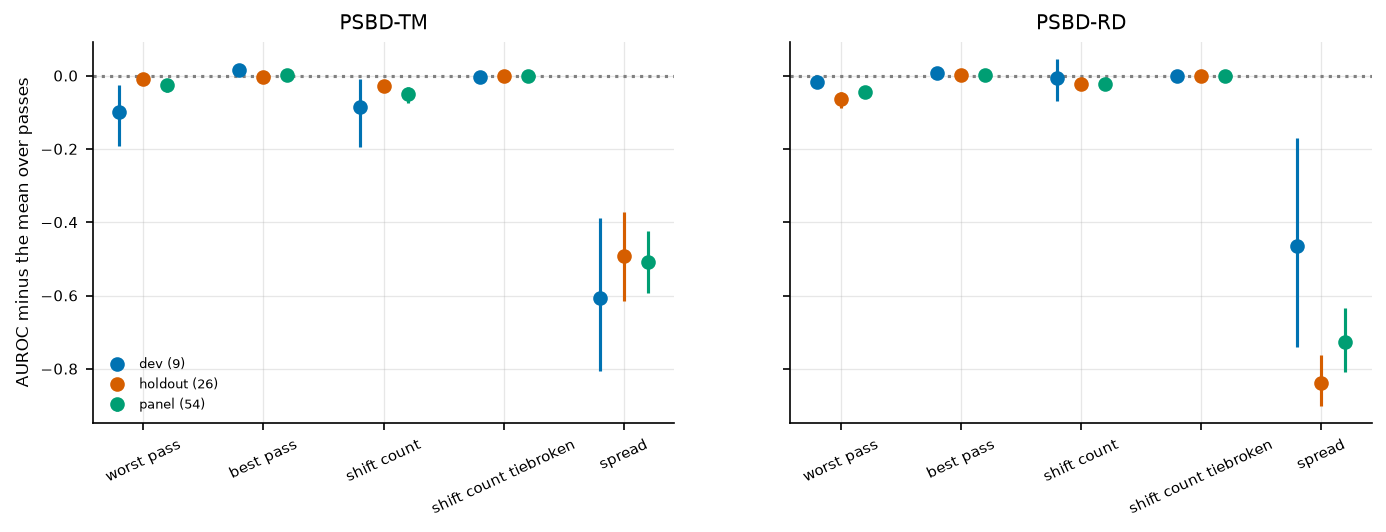

**C28, verdict false.** The best pass or the worst pass over PSBD's k passes separates better than their mean. Key number: on the 26 held-out models the pre-registered best pass reads -0.002 [-0.004, -0.001] AUROC against the mean (failed) and the worst pass -0.008 [-0.015, -0.002]. Control: the mean fractional PSU on the same passes, which reproduces `psbd_metrics.json` bit for bit. Evidence: `results/_experiments/cache_readouts/verdicts_all.json`, `sets.holdout.preregistered[X19-*]`.

In [35]:
if readout_verdicts is not None and None not in pass_statistics.values():
    statistics = (
        "worst_pass",
        "best_pass",
        "shift_count",
        "shift_count_tiebroken",
        "spread",
    )
    figure, axes = plt.subplots(1, 2, figsize=(11, 3.3), sharey=True)
    plotted = {}
    for axis, placement, label in zip(axes, ("psbd_tm", "psbd_rd"), (TM, RD)):
        for index, name in enumerate(("dev", "holdout", "panel")):
            summary = pass_statistics[name]["summary"][placement]["all"]
            differences = [summary[s]["auroc"]["mean_difference"] for s in statistics]
            low = [
                summary[s]["auroc"]["mean_difference"] - summary[s]["auroc"]["ci95"][0]
                for s in statistics
            ]
            high = [
                summary[s]["auroc"]["ci95"][1] - summary[s]["auroc"]["mean_difference"]
                for s in statistics
            ]
            axis.errorbar(
                np.arange(len(statistics)) + (index - 1) * 0.2,
                differences,
                yerr=[low, high],
                fmt="o",
                color=OKABE_ITO[index],
                label=f"{name} ({summary['n']})",
            )
            plotted[f"{label}|{name}"] = dict(zip(statistics, differences))
        axis.axhline(0, color="grey", linestyle=":")
        axis.set_xticks(
            np.arange(len(statistics)),
            [s.replace("_", " ") for s in statistics],
            rotation=25,
        )
        axis.set_title(label)
    axes[0].set_ylabel("AUROC minus the mean over passes")
    axes[0].legend(fontsize=6)
    save_figure(
        figure,
        "pass_statistics",
        ["`results/_experiments/cache_readouts/pass_statistics_<set>.json`"],
        plotted,
    )
    held_out = {
        item["id"]: item
        for item in readout_verdicts["sets"]["holdout"]["preregistered"]
    }
    best, worst = held_out["X19-best-auroc"], held_out["X19-worst-auroc"]
    register(
        "C28",
        "s10",
        "The best pass or the worst pass over PSBD's k passes separates better than their mean",
        "ours (best pass, pre-registered) and plan N17 (worst pass)",
        "false"
        if best["verdict"] == "failed"
        and best["mean_difference"] < 0
        and worst["mean_difference"] < 0
        else "partial",
        f"on the {best['n']} held-out models the pre-registered best pass reads {signed(best['mean_difference'])} "
        f"[{signed(best['ci95'][0])}, {signed(best['ci95'][1])}] AUROC against the mean ({best['verdict']}) and the worst pass "
        f"{signed(worst['mean_difference'])} [{signed(worst['ci95'][0])}, {signed(worst['ci95'][1])}]",
        "the mean fractional PSU on the same passes, which reproduces `psbd_metrics.json` bit for bit",
        f"{READOUT_SOURCE}, `sets.holdout.preregistered[X19-*]`",
    )

**Depth bands.** **Claims.** Token masking in blocks 1 to 8 leaves triggered patch inputs alone (E1a), token masking in blocks 9 to 12 hits them (E1b), no token-mask band moves a global trigger (E2) and early residual dropout moves WaNet more than BadNets (E10). **Experiment.** Each band at its top cached rate, and at the rate nearest the matched shift as a sensitivity reading. **Control.** The paired clean images under the same band. The heat map shows triggered minus clean share of passes moved, so blue is a band that leaves the trigger alone.

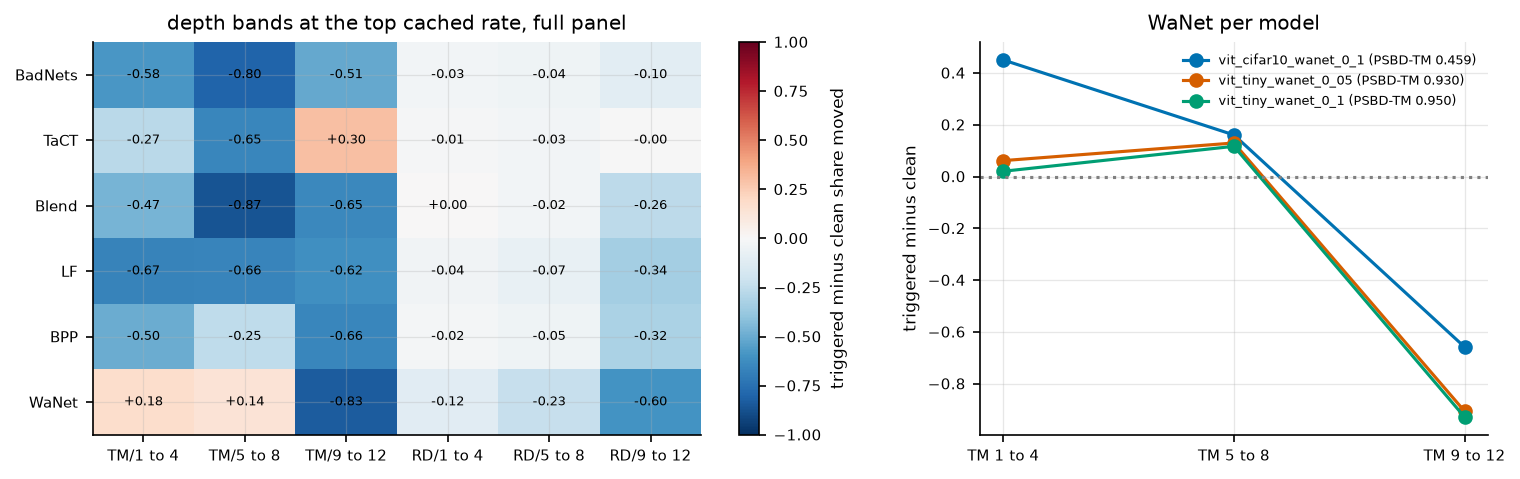

**C29, verdict true.** Token masking in blocks 1 to 8 leaves triggered BadNets predictions alone and breaks clean ones (E1a). Key number: holds on 24 of 24 BadNets checks of the panel, and fails only on `vit_cifar10_tact_0_01`. Control: the paired clean images under the same band and rate. Evidence: `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1a`.

**C30, verdict partial.** Token masking in blocks 9 to 12 hits triggered patch inputs too (E1b). Key number: mixed, 7 of 15 checks hold on the panel at the top rate. Control: the paired clean images under the same band and rate. Evidence: `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1b`.

**C31, verdict partial.** No token-mask band moves a global trigger (E2). Key number: mixed, 76 of 108 checks hold on the panel at the top rate. Control: the paired clean images under the same band and rate. Evidence: `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E2`.

**C32, verdict open.** Residual dropout in blocks 1 to 4 moves triggered WaNet more than triggered BadNets, a trigger computed from relations between tokens (E10). Key number: failed at the top rate and held at the matched reading, so the 2 readings disagree. Control: the BadNets mean under the same band. Evidence: `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.<reading>.E10`.

**C33, verdict false.** WaNet's reversed depth pattern (triggered moving more than clean in blocks 1 to 8) explains the inverted WaNet cell. Key number: triggered minus clean in blocks 5 to 8: `vit_cifar10_wanet_0_1` +0.161 (PSBD-TM 0.459), `vit_tiny_wanet_0_05` +0.130 (PSBD-TM 0.930), `vit_tiny_wanet_0_1` +0.117 (PSBD-TM 0.950). 2 WaNet models share the pattern and are still separated. Control: the WaNet models PSBD-TM separates. Evidence: `results/_experiments/cache_readouts/depth_bands_panel.json`, `models[].bands.top_rate` and `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.per_model[].psbd_tm`.

In [36]:
if readout_verdicts is not None and depth_bands is not None:
    top = depth_bands["summary"]["top_rate"]["by_attack"]
    bands = (
        "token_mask/1_4",
        "token_mask/5_8",
        "token_mask/9_12",
        "residual_dropout/1_4",
        "residual_dropout/5_8",
        "residual_dropout/9_12",
    )
    attacks = [a for a in ATTACK_ORDER if a in top]
    grid = np.array(
        [[top[a][b]["triggered_minus_clean"] for b in bands] for a in attacks]
    )  # (attacks, bands)
    figure, axes = plt.subplots(
        1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [3, 2]}
    )
    image = axes[0].imshow(grid, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    axes[0].set_xticks(
        np.arange(len(bands)),
        [
            b.replace("token_mask", "TM")
            .replace("residual_dropout", "RD")
            .replace("_", " to ")
            for b in bands
        ],
        fontsize=7,
    )
    axes[0].set_yticks(np.arange(len(attacks)), [attack_label(a) for a in attacks])
    for row in range(grid.shape[0]):
        for column in range(grid.shape[1]):
            axes[0].text(
                column,
                row,
                f"{grid[row, column]:+.2f}",
                ha="center",
                va="center",
                fontsize=6,
            )
    figure.colorbar(image, ax=axes[0], label="triggered minus clean share moved")
    axes[0].set_title("depth bands at the top cached rate, full panel")
    wanet_models = [m for m in depth_bands["models"] if m["attack"] == "wanet"]
    for index, model in enumerate(wanet_models):
        values = [
            model["bands"]["top_rate"][b]["triggered_minus_clean"] for b in bands[:3]
        ]
        axes[1].plot(
            np.arange(3),
            values,
            marker="o",
            color=OKABE_ITO[index],
            label=f"{model['folder']} ({TM} {number(wanet_auroc.get(model['folder'], {}).get('psbd_tm'))})",
        )
    axes[1].axhline(0, color="grey", linestyle=":")
    axes[1].set_xticks(np.arange(3), ["TM 1 to 4", "TM 5 to 8", "TM 9 to 12"])
    axes[1].set_ylabel("triggered minus clean")
    axes[1].set_title("WaNet per model")
    axes[1].legend(fontsize=6)
    save_figure(
        figure,
        "depth_bands",
        ["`results/_experiments/cache_readouts/depth_bands_panel.json`"],
        {
            "grid": dict(zip(attacks, grid.tolist())),
            "bands": bands,
            "wanet": {m["folder"]: m["bands"]["top_rate"] for m in wanet_models},
        },
    )

    panel_checks = depth_bands["verdicts"]["top_rate"]
    e1a_badnets = [c for c in panel_checks["E1a"]["checks"] if "badnet" in c["folder"]]
    e1a_held = sum(c["holds"] for c in e1a_badnets)
    e1a_failed_on = sorted(
        {c["folder"] for c in panel_checks["E1a"]["checks"] if not c["holds"]}
    )
    register(
        "C29",
        "s10",
        "Token masking in blocks 1 to 8 leaves triggered BadNets predictions alone and breaks clean ones (E1a)",
        "plan E1a, the routing account",
        "true" if e1a_held == len(e1a_badnets) else "partial",
        f"holds on {e1a_held} of {len(e1a_badnets)} BadNets checks of the panel, and fails only on {', '.join(f'`{f}`' for f in e1a_failed_on)}",
        "the paired clean images under the same band and rate",
        "`results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1a`",
    )
    for cid, key, claim in (
        (
            "C30",
            "E1b",
            "Token masking in blocks 9 to 12 hits triggered patch inputs too (E1b)",
        ),
        ("C31", "E2", "No token-mask band moves a global trigger (E2)"),
    ):
        reading = panel_checks[key]
        register(
            cid,
            "s10",
            claim,
            f"plan {key}",
            "true"
            if reading["verdict"] == "held"
            else "false"
            if reading["n_held"] == 0
            else "partial",
            f"{reading['verdict']}, {reading['n_held']} of {reading['n_checks']} checks hold on the panel at the top rate",
            "the paired clean images under the same band and rate",
            f"`results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.{key}`",
        )
    e10 = {
        reading: depth_bands["verdicts"][reading]["E10"]["verdict"]
        for reading in ("top_rate", "matched")
    }
    register(
        "C32",
        "s10",
        "Residual dropout in blocks 1 to 4 moves triggered WaNet more than triggered BadNets, a trigger computed from relations between tokens (E10)",
        "plan E10",
        "open"
        if len(set(e10.values())) > 1
        else "true"
        if e10["top_rate"] == "held"
        else "false",
        f"{e10['top_rate']} at the top rate and {e10['matched']} at the matched reading, so the 2 readings disagree",
        "the BadNets mean under the same band",
        "`results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.<reading>.E10`",
    )
    wanet_middle = {
        m["folder"]: m["bands"]["top_rate"]["token_mask/5_8"]["triggered_minus_clean"]
        for m in wanet_models
    }
    separated = [
        f
        for f, value in wanet_middle.items()
        if value > 0 and (wanet_auroc.get(f, {}).get("psbd_tm") or 0) >= 0.9
    ]
    register(
        "C33",
        "s10",
        "WaNet's reversed depth pattern (triggered moving more than clean in blocks 1 to 8) explains the inverted WaNet cell",
        "ours, cache readouts X4",
        "false" if separated else "open",
        "triggered minus clean in blocks 5 to 8: "
        + ", ".join(
            f"`{f}` {signed(v)} ({TM} {number(wanet_auroc.get(f, {}).get('psbd_tm'))})"
            for f, v in wanet_middle.items()
        )
        + f". {len(separated)} WaNet models share the pattern and are still separated",
        "the WaNet models PSBD-TM separates",
        "`results/_experiments/cache_readouts/depth_bands_panel.json`, `models[].bands.top_rate` and "
        f"{READS_SOURCE}, `refutations.per_model[].psbd_tm`",
    )

**Fusion with late-band dropout.** **The operation.** The late band is `pre_residual_blocks_9_12`: standard element-wise inverted dropout (`nn.Dropout`) on the attention branch output and on the MLP branch output, before each is added to the residual stream, in ViT blocks 9 to 12 only. Its rate is picked on clean validation by the adaptive rule. Its fractional PSU is fused with PSBD-TM's through a minimum of clean-validation percentiles, with 0.9 of the false-positive budget to PSBD-TM and 0.1 to the band. **Claim.** This fusion detects more at low false-positive rates without costing the patch attacks. **Experiment.** The pre-registered rule on the held-out models, each fused score thresholded at its own clean-validation quantile. **Control.** PSBD-TM alone on the same models and passes. The left panel draws TPR against the realized FPR at the budgets the record stores, on a log axis, which is the front of the ROC curve where a deployed detector operates. The record holds no per-sample scores, so the curve is sampled at those budgets only. **Scope of the confirmation.** The held-out read confirms the rule and not the choice of band. The late band was picked after its WaNet readings on every ViT dataset had been seen, and it was first read on panel models that include the held-out CIFAR-100 and Tiny ImageNet half (`experiments/theory_checks/mix_union.py` reads every clearing cell). The band's selection has not been confirmed independently, and the Swin-S confirmation is pending (plan slot 23), so the verdict is partial.

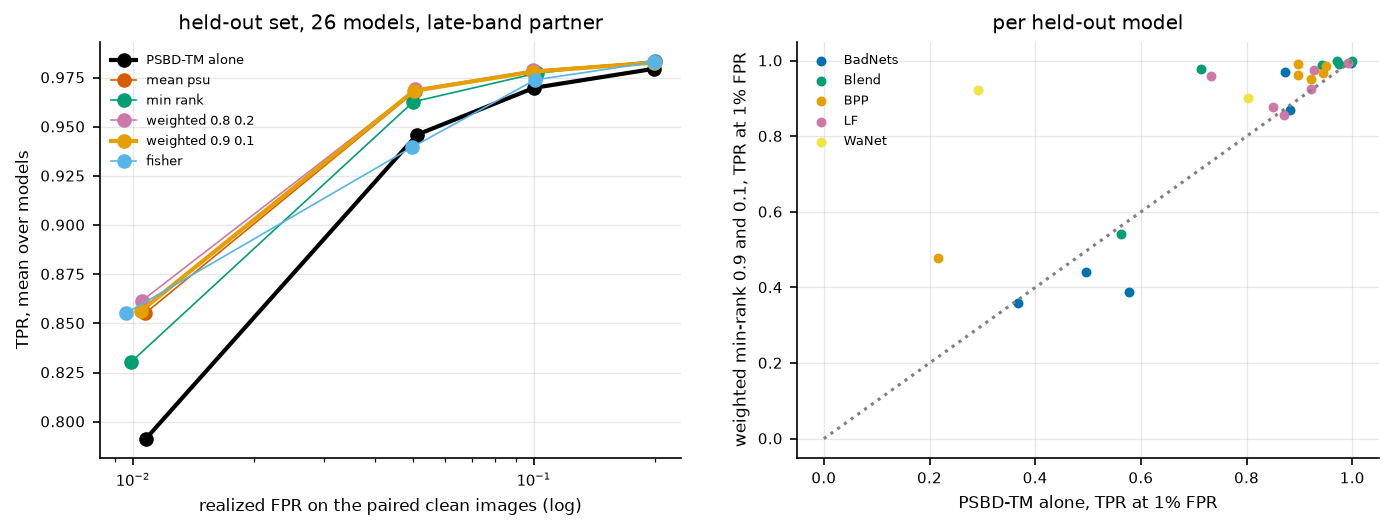

**C34, verdict partial.** Fusing PSBD-TM with late-band residual dropout through the weighted min-rank rule (budget 0.9 and 0.1) detects more at low FPR. Key number: confirmed for the rule, not for the band's selection. On the 26 held-out models TPR at 1% FPR is 0.791 for PSBD-TM alone at a realized FPR of 0.011 and 0.857 fused at 0.010, a paired gain of +0.065 [+0.017, +0.126]. Every fusion rule lands at 0.83 to 0.86. AUROC barely moves from near 0.98 (+0.005). On the panel's WaNet models the fused AUROC is 0.936 against 0.779. Control: PSBD-TM alone on the same models and passes, each score thresholded at its own clean-validation quantile. Evidence: `results/_experiments/cache_readouts/fusion_rules_holdout.json`, `summary.adaptive.late_band.all`, `results/_experiments/cache_readouts/verdicts_all.json` `sets.holdout.preregistered[X3-*]`.

**The late-band fill is withdrawn.** 15 panel models never reach the adaptive target 0.8 with late-band residual dropout. Each already holds a ladder of 11 cached rates up to 0.99, and their largest clean-validation shift is at most 0.780, so a fill run would give them no adaptive rate (`fusion_rules_panel.json`, `summary.adaptive.late_band.missing[]`).

In [37]:
FUSION_SOURCE = "`results/_experiments/cache_readouts/fusion_rules_holdout.json`, `summary.adaptive.late_band.all`"
FUSION_RULES = (
    "tm_alone",
    "mean_psu",
    "min_rank",
    "weighted_0.8_0.2",
    "weighted_0.9_0.1",
    "fisher",
)
PICKED_RULE = "weighted_0.9_0.1"
if readout_verdicts is not None and None not in fusion.values():
    held_out_fusion = fusion["holdout"]["summary"]["adaptive"]["late_band"]["all"]
    budgets = [f"q{q:.2f}" for q in fusion["holdout"]["quantiles"]]
    figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    plotted = {}
    for index, rule in enumerate(FUSION_RULES):
        fpr = [held_out_fusion[rule][f"{b}:realized_fpr"]["mean"] for b in budgets]
        tpr = [held_out_fusion[rule][f"{b}:tpr"]["mean"] for b in budgets]
        emphasized = rule in ("tm_alone", PICKED_RULE)
        axes[0].plot(
            fpr,
            tpr,
            marker="o",
            linewidth=2 if emphasized else 0.8,
            color=CONTROL_COLOR if rule == "tm_alone" else OKABE_ITO[index],
            label=f"{TM} alone" if rule == "tm_alone" else rule.replace("_", " "),
        )
        plotted[rule] = {"realized_fpr": fpr, "tpr": tpr}
    axes[0].set_xscale("log")
    axes[0].set_xlabel("realized FPR on the paired clean images (log)")
    axes[0].set_ylabel("TPR, mean over models")
    axes[0].set_title(f"held-out set, {held_out_fusion['n']} models, late-band partner")
    axes[0].legend(fontsize=6)

    per_model = []
    for model in fusion["holdout"]["models"]:
        rules = model["partners"]["adaptive"]["late_band"]["rules"]
        per_model.append(
            {
                "folder": model["folder"],
                "attack": model["attack"],
                "tm_alone": rules["tm_alone"]["at_fpr"]["q0.01"]["tpr"],
                "fused": rules[PICKED_RULE]["at_fpr"]["q0.01"]["tpr"],
            }
        )
    per_model = pd.DataFrame(per_model)
    for attack, group in per_model.groupby("attack"):
        axes[1].scatter(
            group["tm_alone"],
            group["fused"],
            s=14,
            color=ATTACK_COLORS.get(attack),
            label=attack_label(attack),
        )
    axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":")
    axes[1].set_xlabel(f"{TM} alone, TPR at 1% FPR")
    axes[1].set_ylabel("weighted min-rank 0.9 and 0.1, TPR at 1% FPR")
    axes[1].set_title("per held-out model")
    axes[1].legend(fontsize=6)
    plotted["per_model_tpr_at_1pct"] = per_model.to_dict("records")
    save_figure(figure, "fusion_low_fpr", [FUSION_SOURCE], plotted)

    held_out = {
        item["id"]: item
        for item in readout_verdicts["sets"]["holdout"]["preregistered"]
    }
    auroc_gain, tpr1_gain = held_out["X3-auroc"], held_out["X3-tpr1"]
    alone, picked = held_out_fusion["tm_alone"], held_out_fusion[PICKED_RULE]
    fused_tpr = [
        held_out_fusion[rule]["q0.01:tpr"]["mean"]
        for rule in FUSION_RULES
        if rule != "tm_alone"
    ]
    late_band = fusion["panel"]["summary"]["adaptive"]["late_band"]
    missing = late_band["missing"]
    wanet_fusion = late_band["by_attack"]["wanet"][PICKED_RULE]["auroc"]
    register(
        "C34",
        "s10",
        f"Fusing {TM} with late-band residual dropout through the weighted min-rank rule (budget {' and '.join(PICKED_RULE.split('_')[1:])}) detects more at low FPR",
        "ours, pre-registered in `experiments/cache_readouts/`",
        # The held-out read confirms the rule. The band itself was chosen after reading
        # WaNet on every dataset, the held-out half included, so the claim as a whole
        # stays partial until an independent set (the Swin-S slot of the plan) confirms it.
        "partial"
        if tpr1_gain["verdict"] == "held" and tpr1_gain["ci95"][0] > 0
        else "false",
        f"confirmed for the rule, not for the band's selection. On the {held_out_fusion['n']} held-out models TPR at 1% FPR is {number(alone['q0.01:tpr']['mean'])} for {TM} alone at a realized FPR of "
        f"{number(alone['q0.01:realized_fpr']['mean'])} and {number(picked['q0.01:tpr']['mean'])} fused at "
        f"{number(picked['q0.01:realized_fpr']['mean'])}, a paired gain of {signed(tpr1_gain['mean_difference'])} "
        f"[{signed(tpr1_gain['ci95'][0])}, {signed(tpr1_gain['ci95'][1])}]. Every fusion rule lands at "
        f"{number(min(fused_tpr), 2)} to {number(max(fused_tpr), 2)}. AUROC barely moves from near "
        f"{number(alone['auroc']['mean'], 2)} ({signed(auroc_gain['mean_difference'])}). On the panel's WaNet models the fused AUROC is "
        f"{number(wanet_fusion['mean'])} against {number(wanet_fusion['reference_mean'])}",
        f"{TM} alone on the same models and passes, each score thresholded at its own clean-validation quantile",
        f"{FUSION_SOURCE}, {READOUT_SOURCE} `sets.holdout.preregistered[X3-*]`",
    )
    largest = max(m["max_validation_shift"] for m in missing)
    ladder_lengths = {len(m["rates_cached"]) for m in missing}
    show(
        f"**The late-band fill is withdrawn.** {len(missing)} panel models never reach the adaptive target "
        f"{ADAPTIVE_SHIFT_TARGET} with late-band residual dropout. Each already holds a ladder of "
        f"{', '.join(str(n) for n in sorted(ladder_lengths))} cached rates up to "
        f"{number(max(max(m['rates_cached']) for m in missing), 2)}, and their largest clean-validation shift is at most "
        f"{number(largest)}, so a fill run would give them no adaptive rate "
        "(`fusion_rules_panel.json`, `summary.adaptive.late_band.missing[]`)."
    )

**What this does not show.** The held-out set holds no TaCT model and no PSBD-TM failure, so the fusion's cost on TaCT and its WaNet gain are read on the panel only, where the pick was not confirmed. The panel models that never reach the adaptive target with late-band dropout drop out of the adaptive fusion reading. The depth bands at the top rate hide almost every token, which the readout itself names as a confound of E1b.

<a id="s11"></a>
## General principles

`experiments/why_psbd_works/` asks the general question: what property of a triggered input keeps its answer through a perturbation that destroys a clean answer, for any operator and per attack category. Each account has a stated prediction, a rule written into `summary.json` and the benign models probed with a patch and a global trigger as the control. The grid shows each measured group's status with the key number the rule reads. A hypothesis gets a verdict only once every attack category with a successful model (patch, blend, warp and quantization) has been measured. Until then it is open with its provisional reads listed.

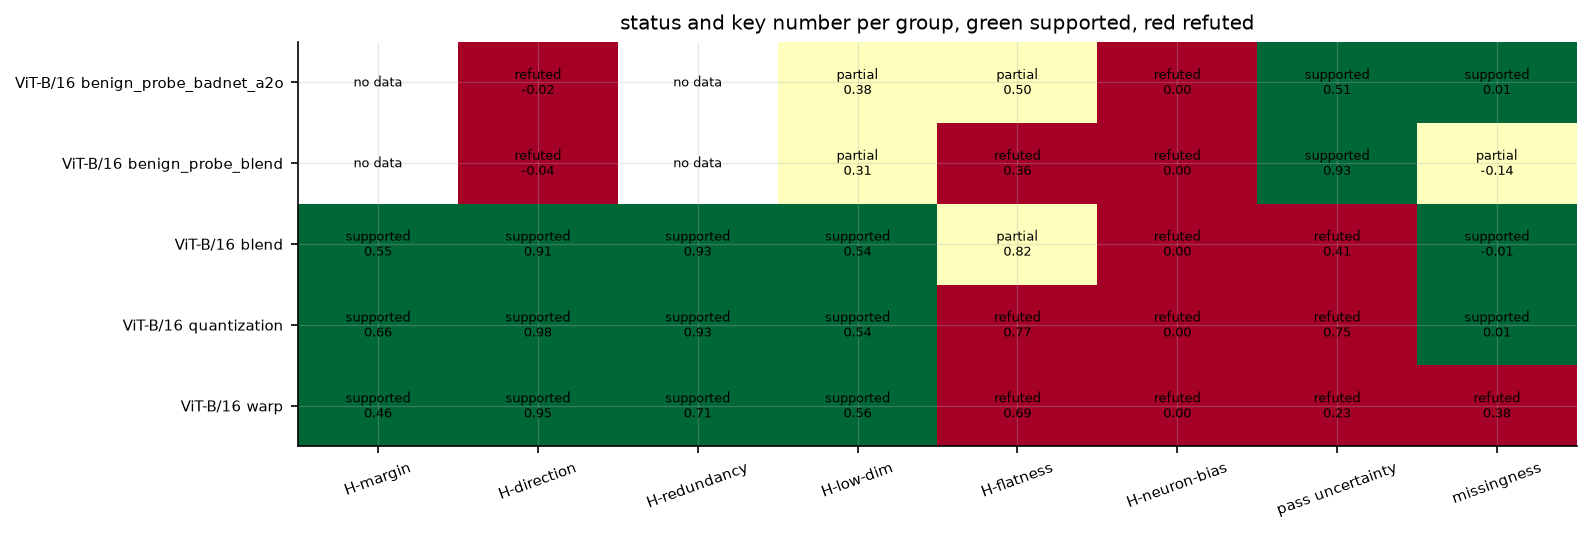

**C35, verdict open.** H-margin: The triggered decision keeps its logit margin under perturbation while the clean margin collapses. Key number: blend supported (0.547), quantization supported (0.662), warp supported (0.456). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o no data, benign_probe_blend no data. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.margin`.

**C36, verdict open.** H-direction: The triggered feature is dominated by a backdoor direction the perturbation dents less than clean class evidence. Key number: blend supported (0.911), quantization supported (0.976), warp supported (0.947). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o refuted, benign_probe_blend refuted. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.direction`.

**C37, verdict open.** H-redundancy: Trigger evidence is repeated across tokens. Key number: blend supported (0.928), quantization supported (0.934), warp supported (0.706). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o no data, benign_probe_blend no data. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.redundancy`.

**C38, verdict open.** H-low-dim: The triggered decision depends on few dimensions or a small part of the input. Key number: blend supported (0.538), quantization supported (0.544), warp supported (0.563). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o partial, benign_probe_blend partial. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.low_dim`.

**C39, verdict open.** H-flatness: Triggered inputs sit in a flatter region and the statistic estimates curvature. Key number: blend partial (0.820), quantization refuted (0.770), warp refuted (0.686). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o partial, benign_probe_blend refuted. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.flatness`.

**C40, verdict open.** H-neuron-bias: Shifted clean predictions fall onto the target, so removing the target's gain costs AUROC. Key number: blend refuted (0.000), quantization refuted (0.000), warp refuted (0.000). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o refuted, benign_probe_blend refuted. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.neuron_bias`.

**C41, verdict open.** pass uncertainty: The statistic is MC-dropout uncertainty over the passes. Key number: blend refuted (0.409), quantization refuted (0.750), warp refuted (0.234). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o supported, benign_probe_blend supported. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.pass_uncertainty`.

**C42, verdict open.** missingness: A zeroed token is native missingness, so substituting another token does as well. Key number: blend supported (-0.009), quantization supported (0.010), warp refuted (0.376). Not yet measured: patch. Control: benign models probed with a patch and a global trigger: benign_probe_badnet_a2o supported, benign_probe_blend partial. Evidence: `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.missingness`.

**C43, verdict partial.** The target class is easy, so any image predicted as the target scores low. Key number: clean target-class images flagged by PSBD-TM: BadNets 0.726 (partial), Blend 0.401 (partial), BPP 0.413 (partial), LF 0.737 (partial), TaCT 0.032 (refuted), WaNet 0.554 (partial), against 0.201 on the benign references and a base rate of 0.25. Control: benign references and the base rate of the quantile threshold. Evidence: `results/_experiments/why_psbd_works/summary.json`, `panel_verdicts.target_easy`.

In [38]:
GENERAL_HYPOTHESES = {
    "margin": (
        "H-margin",
        "The triggered decision keeps its logit margin under perturbation while the clean margin collapses",
        "memo L1, P1",
    ),
    "direction": (
        "H-direction",
        "The triggered feature is dominated by a backdoor direction the perturbation dents less than clean class evidence",
        "Karayalçin et al., memo L8",
    ),
    "redundancy": (
        "H-redundancy",
        "Trigger evidence is repeated across tokens",
        "memo L19, L23",
    ),
    "low_dim": (
        "H-low-dim",
        "The triggered decision depends on few dimensions or a small part of the input",
        "Cognitive Distillation, memo L6, L9",
    ),
    "flatness": (
        "H-flatness",
        "Triggered inputs sit in a flatter region and the statistic estimates curvature",
        "memo L2, P4",
    ),
    "neuron_bias": (
        "H-neuron-bias",
        "Shifted clean predictions fall onto the target, so removing the target's gain costs AUROC",
        "Li et al., memo L10, P6",
    ),
    "pass_uncertainty": (
        "pass uncertainty",
        "The statistic is MC-dropout uncertainty over the passes",
        "Li et al.'s framing, memo P2",
    ),
    "missingness": (
        "missingness",
        "A zeroed token is native missingness, so substituting another token does as well",
        "Jain et al., memo L22",
    ),
}
# The 4 categories with a successful model on the 4 paper datasets. Frequency
# (SIG) is quarantined by the audit of 2026-09-29, so it is not required.
REQUIRED_CATEGORIES = ("patch", "blend", "warp", "quantization")
STATUS_VALUES = {"supported": 1.0, "partial": 0.5, "refuted": 0.0}
if why_summary is None:
    for index, (key, (name, claim, who)) in enumerate(GENERAL_HYPOTHESES.items()):
        register(
            f"C{35 + index}",
            "s11",
            claim,
            who,
            "pending",
            "pending",
            "benign probes",
            WHY_SOURCE,
        )
else:
    verdicts = why_summary["verdicts"]
    cells = []
    for architecture, groups in verdicts.items():
        for group, entries in groups.items():
            for key in GENERAL_HYPOTHESES:
                entry = entries.get(key, {})
                cells.append(
                    {
                        "architecture": architecture,
                        "group": group,
                        "hypothesis": key,
                        "status": entry.get("status"),
                        "value": entry.get("value"),
                    }
                )
    cells = pd.DataFrame(cells)
    rows = sorted(
        cells[["architecture", "group"]].drop_duplicates().itertuples(index=False)
    )
    grid = np.full((len(rows), len(GENERAL_HYPOTHESES)), np.nan)  # (groups, hypotheses)
    figure, axis = plt.subplots(figsize=(11, 0.4 * len(rows) + 1.5))
    for i, (architecture, group) in enumerate(rows):
        for j, key in enumerate(GENERAL_HYPOTHESES):
            cell = cells[
                (cells["architecture"] == architecture)
                & (cells["group"] == group)
                & (cells["hypothesis"] == key)
            ].iloc[0]
            grid[i, j] = STATUS_VALUES.get(cell["status"], np.nan)
            text = cell["status"] or "no data"
            if pd.notna(cell["value"]):
                text += f"\n{cell['value']:.2f}"
            axis.text(j, i, text, ha="center", va="center", fontsize=6)
    axis.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    axis.set_xticks(
        np.arange(len(GENERAL_HYPOTHESES)),
        [v[0] for v in GENERAL_HYPOTHESES.values()],
        rotation=20,
    )
    axis.set_yticks(
        np.arange(len(rows)), [f"{ARCHITECTURE_LABELS[a]} {g}" for a, g in rows]
    )
    axis.set_title("status and key number per group, green supported, red refuted")
    save_figure(
        figure, "general_principles", [WHY_SOURCE], {"cells": cells.to_dict("records")}
    )

    measured = sorted(
        {
            group
            for groups in verdicts.values()
            for group in groups
            if not group.startswith("benign")
        }
    )
    missing_categories = [
        c for c in REQUIRED_CATEGORIES if not any(g.startswith(c) for g in measured)
    ]
    for index, (key, (name, claim, who)) in enumerate(GENERAL_HYPOTHESES.items()):
        statuses = cells[
            (cells["hypothesis"] == key) & ~cells["group"].str.startswith("benign")
        ]
        text = ", ".join(
            f"{row.group} {row.status} ({number(row.value)})"
            for row in statuses.itertuples()
        )
        if missing_categories:
            verdict = "open"
        else:
            status_set = set(statuses["status"])
            verdict = (
                "true"
                if status_set == {"supported"}
                else "false"
                if status_set == {"refuted"}
                else "partial"
            )
        benign = cells[
            (cells["hypothesis"] == key) & cells["group"].str.startswith("benign")
        ]
        register(
            f"C{35 + index}",
            "s11",
            f"{name}: {claim}",
            who,
            verdict,
            text
            + (
                f". Not yet measured: {', '.join(missing_categories)}"
                if missing_categories
                else ""
            ),
            "benign models probed with a patch and a global trigger: "
            + ", ".join(f"{row.group} {row.status}" for row in benign.itertuples()),
            f"{WHY_SOURCE}, `verdicts.<architecture>.<group>.{key}`",
        )
    target_easy = why_summary["panel_verdicts"]["target_easy"]
    statuses = {attack: entry["status"] for attack, entry in target_easy.items()}
    register(
        f"C{35 + len(GENERAL_HYPOTHESES)}",
        "s11",
        "The target class is easy, so any image predicted as the target scores low",
        "reviewer reading P10",
        "true"
        if set(statuses.values()) == {"supported"}
        else "false"
        if set(statuses.values()) == {"refuted"}
        else "partial",
        "clean target-class images flagged by PSBD-TM: "
        + ", ".join(
            f"{attack_label(a)} {number(e['value'])} ({e['status']})"
            for a, e in target_easy.items()
        )
        + f", against {number(next(iter(target_easy.values()))['benign'])} on the benign references and a base rate of {HEADLINE_QUANTILE}",
        "benign references and the base rate of the quantile threshold",
        f"{WHY_SOURCE}, `panel_verdicts.target_easy`",
    )

**What this does not show.** The experiment has measured a handful of its planned models, and the rendered rows name how many per group and which categories are still missing. A supported status on 1 model per category is a direction, not a result.

## Claims table, final

The same table as at the top, written once every section has run. The rows are also saved as `notebooks/figures/why-psbd-works/claims.json`.

In [39]:
SECTION_TITLES = {
    "s1": "Li et al.'s account",
    "s2": "breaking-point curves",
    "s3": "patch-trigger routing",
    "s4": "clean fragility",
    "s5": "alternative explanations",
    "s6": "neurons and directions",
    "s7": "WaNet",
    "s8": "global-trigger redundancy",
    "s9": "where the backdoor lives",
    "s10": "pass statistics, depth bands and fusion",
    "s11": "general principles",
}


def claims_markdown(claims):
    lines = [
        "| id | claim | made by | verdict | key number | control | evidence (file, field) |",
        "|---|---|---|---|---|---|---|",
    ]
    for row in claims:
        cells = [
            f"[{row['id']}](#{row['section']})",
            row["claim"],
            row["who"],
            f"**{row['verdict']}**",
            row["key"],
            row["control"],
            row["source"],
        ]
        lines.append("| " + " | ".join(cell.replace("|", "/") for cell in cells) + " |")
    table = "\n".join(lines)
    return table


counts = pd.Series([row["verdict"] for row in CLAIMS]).value_counts()
summary_line = (
    f"{len(CLAIMS)} claims: "
    + ", ".join(f"{counts.get(v, 0)} {v}" for v in VERDICTS)
    + ". Sections: "
    + ", ".join(f"[{title}](#{sid})" for sid, title in SECTION_TITLES.items())
    + "."
)
table = summary_line + "\n\n" + claims_markdown(CLAIMS)
update_display(Markdown(table), display_id="claims-table")
Path(FIGURE_DIR / "claims.json").write_text(json.dumps(CLAIMS, indent=2))
show(table)

43 claims: 6 true, 12 false, 11 partial, 13 open, 1 pending. Sections: [Li et al.'s account](#s1), [breaking-point curves](#s2), [patch-trigger routing](#s3), [clean fragility](#s4), [alternative explanations](#s5), [neurons and directions](#s6), [WaNet](#s7), [global-trigger redundancy](#s8), [where the backdoor lives](#s9), [pass statistics, depth bands and fusion](#s10), [general principles](#s11).

| id | claim | made by | verdict | key number | control | evidence (file, field) |
|---|---|---|---|---|---|---|
| [C1](#s1) | Clean predictions shift and captured triggered ones do not (claim 1), under PSBD-TM | Li et al., tested with our placement | **true** | holds on 101 of 117 poisoned transformer models (ViT-B/16 43 of 54 (median triggered shift 0.016), Swin-S 58 of 63 (median triggered shift 0.002)) | on the benign references the clean and triggered curves coincide on 7 of 7 | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_1` and `claim_1_benign` |
| [C2](#s1) | Clean predictions shift and captured triggered ones do not (claim 1), under PSBD-RD | Li et al., tested with our placement | **partial** | holds on 63 of 119 poisoned transformer models (ViT-B/16 26 of 54 (median triggered shift 0.117), Swin-S 37 of 65 (median triggered shift 0.011)) | on the benign references the clean and triggered curves coincide on 7 of 7 | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_1` and `claim_1_benign` |
| [C3](#s1) | When a clean prediction shifts, it shifts to the attacker's target (claim 2) | Li et al. | **false** | at least 0.8 of shifts on the target in 51 of 236 poisoned transformer readings (ViT-B/16 PSBD-TM 4 of 54 (median share 0.022), ViT-B/16 PSBD-RD 0 of 54 (median share 0.089), Swin-S PSBD-TM 29 of 63 (median share 0.677), Swin-S PSBD-RD 18 of 65 (median share 0.282)) | benign references, where 1 class takes at least half of the shifts in 5 of 14 readings | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_2` and `cached_rows[].validation_target_share` |
| [C4](#s1) | Dropout makes a clean image's last-layer features match its triggered twin's, the neuron bias (claim 3) | Li et al. | **false** | holds on 0 of 57 transformer feature readings, and at p = 0.91 with a shared mask the pair's median cosine is 1.000 while 2 unrelated clean images reach 0.999 | a clean image and an unrelated clean image under the same mask, and the benign models | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_3` and `feature_rows[]` |
| [C5](#s1) | MC-Dropout uncertainty catches BadNets and misses WaNet and Adaptive-Blend, which is why PSBD reads the confidence drop (claim 4) | Li et al. | **partial** | holds on 2 of 4 transformer placements: ViT-B/16 PSBD-RD holds (std fails on 1.00 of 3 WaNet and Adaptive-Blend models, suffices on 0.83 of 12 BadNets models), ViT-B/16 PSBD-TM partial (std fails on 1.00 of 3 WaNet and Adaptive-Blend models, suffices on 0.17 of 12 BadNets models), Swin-S PSBD-RD partial (std fails on 0.60 of 15 WaNet and Adaptive-Blend models, suffices on 0.92 of 12 BadNets models), Swin-S PSBD-TM holds (std fails on 0.73 of 15 WaNet and Adaptive-Blend models, suffices on 1.00 of 12 BadNets models) | the same passes scored 2 ways, the standard deviation given its best rate as an oracle | `results/_experiments/prediction_shift_phenomenon/summary.json`, `overall[].claim_4` |
| [C6](#s2) | PSBD at every placement is a 2-sample test on the per-image breaking point p*, and operators differ only in how far they separate it | ours, `experiments/why_psbd_works/critical_rate.py` | **open** | first read: Spearman 0.883 between AUROC and A* = P(p*_triggered > p*_clean) over 558 (model, placement) pairs, 100 pairs off by more than 0.1 | benign references, A* within 0.017 of 0.5 over 44 readings | `results/_experiments/why_psbd_works/critical_rate.json`, `predictions` |
| [C7](#s3) | A patch trigger's evidence rides in its own tokens: masking them in every block removes the backdoor, masking as many random tokens does nothing | ours, `experiments/why_token_masking_works/` hypothesis 1 | **true** | triggered BadNets kept 0.002 with the trigger tokens masked in all 12 blocks against 1.000 with random tokens, clean kept 0.986 | as many random non-trigger tokens masked in all 12 blocks, 3 draws | `results/_experiments/why_token_masking_works/summary.json`, `deterministic_masking.badnet_a2o` |
| [C8](#s3) | A token masked at the attention input keeps its entry in the residual stream, and the class token reads the trigger late | ours, `experiments/why_token_masking_works/` hypothesis 1 | **true** | BadNets kept 1.000 with blocks 1 to 4 masked, 0.788 with 5 to 8 and 0.200 with 9 to 12. Trigger-conditional TaCT keeps 0.339 with only the last block masked | the same blocks masked on random tokens, and clean survival in every row | `results/_experiments/why_token_masking_works/summary.json`, `deterministic_masking.<group>.blocks_*` |
| [C9](#s3) | A triggered prediction breaks only when every trigger token is masked in every late block, an event of probability p^(4m) | ours, `experiments/why_token_masking_works/` section B and the literature memo | **false** | the full-mask event explains 0.075 of broken 4-token BadNets predictions, survival is graded in J (s_0 0.987, s_1 0.965, s_2 0.917, s_3 0.748, s_4 0.216) | clean survival under the same masks, flat near 0.107 | `results/_experiments/why_token_masking_works/summary.json`, `stochastic_token_mask_by_trigger_tokens.badnet_a2o_4_tokens.triggered.late_all` |
| [C10](#s3) | PSBD-RD breaks triggered patch predictions through the trigger positions alone | ours, `experiments/why_token_masking_works/` hypothesis 2 | **partial** | in the mean, trigger-only dropout keeps 0.387 against 0.398 for all tokens, but per model the 2 differ by 0.223 on average and trigger-only breaks at least as much on 8 of 12 models. Dropout everywhere but the trigger still keeps only 0.664 | as many random positions, which keep 1.000 | `results/_experiments/why_token_masking_works/summary.json`, `residual_dropout.badnet_a2o` and `per_model[]` |
| [C11](#s4) | Clean fragility is a per-image critical rate (a logistic spread across images), not a fixed number of tokens every image needs | ours, `docs/why-psbd-works-theory.md` | **true** | median critical rate 0.288 to 0.411 by dataset, logistic RMSE 0.005 to 0.015 against 0.057 to 0.111 for the AND law, flip correlation within an image 0.688 | the homogeneous AND law fitted to the same curves | `results/_experiments/why_psbd_works/cached_reads.json`, `clean_fragility.curves` and `median_intra_image_correlation` |
| [C12](#s4) | The clean images that never flip are the false positives | ours, `docs/why-psbd-works-theory.md` | **partial** | 0.087 of held-out clean images never flip and they make up 0.339 of the false positives | the share they would take if flipping did not matter, their own share 0.087 | `results/_experiments/why_psbd_works/cached_reads.json`, `clean_fragility.mean_never_flip_share` and `mean_false_positive_never_flip_share` |
| [C13](#s5) | PSBD-TM's score is just the model's confidence in its answer | reviewer reading P1, `experiments/psu_vs_confidence/` | **false** | A* averages 0.881 on the 54-model panel against 0.688 for raw confidence. PSBD-TM is above it on 50 of 54 models and by at least 0.02 on 46. Its mean margin is +0.082. The theory note (`docs/why-psbd-works-theory.md`) read the same ceiling as 0.873 with PSBD-TM above it on 52 of 57 models, on the 57-model panel of 2026-09-24 | the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]` |
| [C14](#s5) | PSBD-RD's score is just the model's confidence in its answer | reviewer reading P1, `experiments/psu_vs_confidence/` | **partial** | A* averages 0.881 on the 54-model panel against 0.688 for raw confidence. PSBD-RD is above it on 40 of 54 models and by at least 0.02 on 37. Its mean margin is +0.003 | the cross-fitted likelihood ratio of unperturbed confidence, an oracle that reads the triggered labels | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.confidence_ceiling[].a_star` and `refutations.per_model[]` |
| [C15](#s5) | PSBD flags triggered inputs because they are unusual, out-of-distribution inputs | Doan et al. and folk reading P5 | **false** | on the 4 benign references the same triggered images score PSBD-TM AUROC 0.500 and PSBD-RD 0.499, and the paper's confidence-null record reads 0.505. The foreign minus clean flagged share ranges from -0.086 to 0.531 on the 4 backdoored models measured | benign models shown the same triggers, and clean images of another dataset | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.benign[]`, `paper/headline.json` `ConfidenceNullBenignPsu` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].operators.token_mask.flagged` |
| [C16](#s5) | A LayerNorm removes part of an additive disturbance and passes a mask intact | ours, H47 and literature memo L25 | **true** | at the attention input the norm removes 0.179 of Gaussian noise and -0.002 of a token mask, on 2 models | positions no LayerNorm follows, survival 1.000 | `paper/headline.json`, `Absorption*` macros from `results/<folder>/layernorm_absorption.json` |
| [C17](#s5) | LayerNorm absorption explains why Gaussian noise trails token masking at the attention input | ours, `experiments/residual_stream_mechanism/` before 2026-09-29 | **false** | Gaussian survival is already 0.840 to 0.850 at the smallest injected size and falls by at most 0.073 across sizes 0.1, 0.2, 0.4, so most of the absorption is an attenuation that does not grow with the disturbance, which the matched rule compensates by raising the rate. The gap at the matched rule is still -0.188 [-0.243, -0.139] | the matched-shift rule, which equalizes clean disturbance across operators | `results/<folder>/layernorm_absorption.json` `rows[].survival` and `results/_experiments/theory_checks/ladders.json` |
| [C18](#s5) | Token masking leaves exact reads or none while noise degrades every read, which gives a negative gap largest on patch triggers | ours, `docs/why-psbd-works-theory.md` | **open** | mean gap by attack, most negative first: BadNets -0.365, TaCT -0.242, LF -0.161, BPP -0.154, Blend -0.116, WaNet +0.036. Patch triggers lead the ordering the account predicts. WaNet reads +0.036 | none yet, the ordering is a consistency check and no experiment isolates the read structure | `results/_experiments/theory_checks/ladders.json`, `before_attention_norm_gaussian` and `before_attention_norm_token_mask` ladders |
| [C19](#s5) | Amplifying the normalization parameters pushes every clean input onto the target, so a poisoned input is the one whose prediction stays (Theorem 3.1) | IBD-PSC (Hou et al.) | **false** | at the top amplification factor (16) the target takes at least half of the shifted clean predictions on 4 of 54 models, with a median share of 0.000 (largest 1.000), while the largest single class takes 0.791 on average. The detector still works, PSBD-TM leads the calibrated port by only +0.027 [+0.004, +0.049] | the share of the largest non-target class and the benign references | `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.per_model[].gain_scale_top` and `paper/headline.json` `DetectorsAurocMargin` |
| [C20](#s6) | A few backdoor neurons carry the trigger, and PSBD works through their robust bias paths | Li et al., the Fine-Pruning and ANP line | **false** | zeroing the top 20 TAC coordinates leaves ASR at 0.998 or more on the 4 Adam checkpoints. Zeroing the 30 MLP units per late block the trigger raises most keeps 0.972 to 1.000 of triggered answers on 4 models | as many random coordinates, random rank-1 directions and as many random MLP units | `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`, `ablated.top_20` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].neurons` |
| [C21](#s6) | The backdoor is a single linear direction in the residual stream, distinct from the target class | Karayalçin et al., and ours (H16) | **partial** | removing the rank-1 direction takes ASR to 0.000 to 0.572 on the 4 Adam checkpoints. The first manifestation runs (7 backdoored models) add the missing control: removing the target class's own mean offset takes ASR to 0.000 to 0.985, removing the backdoor direction drops target-class recall to 0.140 to 0.920, and the part of the backdoor direction orthogonal to the target leaves ASR at 0.842 to 1.000 | random rank-1 directions, the target-class offset and the target-orthogonal part of the direction | `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`, `ablated.direction` and `results/_experiments/backdoor_manifestation/runs/<run>.json`, `ablation.<last block>.variants` |
| [C22](#s6) | PSBD-RD fails on BadNets because residual dropout erases the backdoor direction at every rate | ours, H3 and H20 | **partial** | separation kept under post_residual 0.222, 0.015, 0.000, 0.000, 0.000, 0.000 at rates 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, against 0.867, 0.778, 0.524, 0.297, 0.064, 0.008 under pre_residual, on 1 checkpoint | the other placements on the same checkpoint and its unperturbed separation | `results/vit_cifar10_badnet_a2o_0_1/dropout_direction_survival.json`, `placements.<name>[]` |
| [C23](#s7) | WaNet's noise mode sends a masked triggered input back to its true class | WaNet's training recipe, plan account E8 | **false** | on the inverted cell `vit_cifar10_wanet_0_1` (PSBD-TM 0.459, PSBD-RD 0.947) 0.729 of triggered passes change and 0.158 of those reach the true class. On the other 4 WaNet models few triggered passes change (0.004 to 0.117) | the clean rows of the same models and the WaNet models that do not invert | `experiments/literature_checks/wanet_destinations.py` on the stage-1 caches `results/<folder>/psbd/` |
| [C24](#s7) | WaNet's trigger is a coherence check that no single token can read, so random masking cannot leave its evidence behind | literature memo L26 | **false** | a linear probe on a single patch token tells the exact warp from a random warp at 0.700 to 0.995 accuracy in blocks 4 to 8 on 5 models | the same probe on the class token, and chance at 0.5 | `results/_experiments/why_psbd_works/wanet_probe__<folder>.json`, `blocks.<b>` |
| [C25](#s7) | The inverted WaNet cell `vit_cifar10_wanet_0_1` is a checkpoint accident and not a recipe that defeats PSBD-TM | ours, plan X2 | **open** | pending, no replicate has been swept | the seed-0 cell, PSBD-TM 0.459 | `results/vit_cifar10_wanet_0_1_seed_{1,2}/psbd_metrics.json` |
| [C26](#s8) | Global triggers stay legible from any 30% of the tokens, which is why token masking leaves them | Karayalçin et al. (L23), Naseer et al. (L19) | **open** | Blend, LF and BPP keep 0.903 to 0.950 of their excess ASR at 30% visible in section D, but WaNet reads 0.183 there and `vit_tiny_wanet_0_1` 0.706 in `why_psbd_works`. Section D's WaNet models are `vit_cifar10_wanet_0_05`, `vit_gtsrb_wanet_0_1`, `vit_tiny_wanet_0_05`, of which 1 is in the panel | clean accuracy retention at the same visible fraction, and the excess form that removes collapse onto the target | `results/_experiments/why_token_masking_works/summary.json`, `visible_subsets` and `results/_experiments/why_psbd_works/summary.json`, `per_model[].redundancy` |
| [C27](#s9) | Where each attack lives inside ViT-B/16 and Swin-S: depth of onset, readout, neurons or direction, per category | ours, `experiments/backdoor_manifestation/` | **pending** | 7 backdoored and 10 benign-control runs have landed, summary not written yet | benign models probed with the same trigger, isotropic, energy-matched and target-class directions | `results/_experiments/backdoor_manifestation/runs/` and `summary.json` |
| [C28](#s10) | The best pass or the worst pass over PSBD's k passes separates better than their mean | ours (best pass, pre-registered) and plan N17 (worst pass) | **false** | on the 26 held-out models the pre-registered best pass reads -0.002 [-0.004, -0.001] AUROC against the mean (failed) and the worst pass -0.008 [-0.015, -0.002] | the mean fractional PSU on the same passes, which reproduces `psbd_metrics.json` bit for bit | `results/_experiments/cache_readouts/verdicts_all.json`, `sets.holdout.preregistered[X19-*]` |
| [C29](#s10) | Token masking in blocks 1 to 8 leaves triggered BadNets predictions alone and breaks clean ones (E1a) | plan E1a, the routing account | **true** | holds on 24 of 24 BadNets checks of the panel, and fails only on `vit_cifar10_tact_0_01` | the paired clean images under the same band and rate | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1a` |
| [C30](#s10) | Token masking in blocks 9 to 12 hits triggered patch inputs too (E1b) | plan E1b | **partial** | mixed, 7 of 15 checks hold on the panel at the top rate | the paired clean images under the same band and rate | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E1b` |
| [C31](#s10) | No token-mask band moves a global trigger (E2) | plan E2 | **partial** | mixed, 76 of 108 checks hold on the panel at the top rate | the paired clean images under the same band and rate | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.top_rate.E2` |
| [C32](#s10) | Residual dropout in blocks 1 to 4 moves triggered WaNet more than triggered BadNets, a trigger computed from relations between tokens (E10) | plan E10 | **open** | failed at the top rate and held at the matched reading, so the 2 readings disagree | the BadNets mean under the same band | `results/_experiments/cache_readouts/depth_bands_panel.json`, `verdicts.<reading>.E10` |
| [C33](#s10) | WaNet's reversed depth pattern (triggered moving more than clean in blocks 1 to 8) explains the inverted WaNet cell | ours, cache readouts X4 | **false** | triggered minus clean in blocks 5 to 8: `vit_cifar10_wanet_0_1` +0.161 (PSBD-TM 0.459), `vit_tiny_wanet_0_05` +0.130 (PSBD-TM 0.930), `vit_tiny_wanet_0_1` +0.117 (PSBD-TM 0.950). 2 WaNet models share the pattern and are still separated | the WaNet models PSBD-TM separates | `results/_experiments/cache_readouts/depth_bands_panel.json`, `models[].bands.top_rate` and `results/_experiments/why_psbd_works/cached_reads.json`, `refutations.per_model[].psbd_tm` |
| [C34](#s10) | Fusing PSBD-TM with late-band residual dropout through the weighted min-rank rule (budget 0.9 and 0.1) detects more at low FPR | ours, pre-registered in `experiments/cache_readouts/` | **partial** | confirmed for the rule, not for the band's selection. On the 26 held-out models TPR at 1% FPR is 0.791 for PSBD-TM alone at a realized FPR of 0.011 and 0.857 fused at 0.010, a paired gain of +0.065 [+0.017, +0.126]. Every fusion rule lands at 0.83 to 0.86. AUROC barely moves from near 0.98 (+0.005). On the panel's WaNet models the fused AUROC is 0.936 against 0.779 | PSBD-TM alone on the same models and passes, each score thresholded at its own clean-validation quantile | `results/_experiments/cache_readouts/fusion_rules_holdout.json`, `summary.adaptive.late_band.all`, `results/_experiments/cache_readouts/verdicts_all.json` `sets.holdout.preregistered[X3-*]` |
| [C35](#s11) | H-margin: The triggered decision keeps its logit margin under perturbation while the clean margin collapses | memo L1, P1 | **open** | blend supported (0.547), quantization supported (0.662), warp supported (0.456). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o no data, benign_probe_blend no data | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.margin` |
| [C36](#s11) | H-direction: The triggered feature is dominated by a backdoor direction the perturbation dents less than clean class evidence | Karayalçin et al., memo L8 | **open** | blend supported (0.911), quantization supported (0.976), warp supported (0.947). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o refuted, benign_probe_blend refuted | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.direction` |
| [C37](#s11) | H-redundancy: Trigger evidence is repeated across tokens | memo L19, L23 | **open** | blend supported (0.928), quantization supported (0.934), warp supported (0.706). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o no data, benign_probe_blend no data | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.redundancy` |
| [C38](#s11) | H-low-dim: The triggered decision depends on few dimensions or a small part of the input | Cognitive Distillation, memo L6, L9 | **open** | blend supported (0.538), quantization supported (0.544), warp supported (0.563). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o partial, benign_probe_blend partial | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.low_dim` |
| [C39](#s11) | H-flatness: Triggered inputs sit in a flatter region and the statistic estimates curvature | memo L2, P4 | **open** | blend partial (0.820), quantization refuted (0.770), warp refuted (0.686). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o partial, benign_probe_blend refuted | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.flatness` |
| [C40](#s11) | H-neuron-bias: Shifted clean predictions fall onto the target, so removing the target's gain costs AUROC | Li et al., memo L10, P6 | **open** | blend refuted (0.000), quantization refuted (0.000), warp refuted (0.000). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o refuted, benign_probe_blend refuted | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.neuron_bias` |
| [C41](#s11) | pass uncertainty: The statistic is MC-dropout uncertainty over the passes | Li et al.'s framing, memo P2 | **open** | blend refuted (0.409), quantization refuted (0.750), warp refuted (0.234). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o supported, benign_probe_blend supported | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.pass_uncertainty` |
| [C42](#s11) | missingness: A zeroed token is native missingness, so substituting another token does as well | Jain et al., memo L22 | **open** | blend supported (-0.009), quantization supported (0.010), warp refuted (0.376). Not yet measured: patch | benign models probed with a patch and a global trigger: benign_probe_badnet_a2o supported, benign_probe_blend partial | `results/_experiments/why_psbd_works/summary.json`, `verdicts.<architecture>.<group>.missingness` |
| [C43](#s11) | The target class is easy, so any image predicted as the target scores low | reviewer reading P10 | **partial** | clean target-class images flagged by PSBD-TM: BadNets 0.726 (partial), Blend 0.401 (partial), BPP 0.413 (partial), LF 0.737 (partial), TaCT 0.032 (refuted), WaNet 0.554 (partial), against 0.201 on the benign references and a base rate of 0.25 | benign references and the base rate of the quantile threshold | `results/_experiments/why_psbd_works/summary.json`, `panel_verdicts.target_easy` |